In [1]:
import pandas as pd
import glob 
import seaborn as sns
import matplotlib.pyplot as plt
import protfasta
import numpy as np

In [2]:
old_SFARI_TF_dbd_coords = pd.read_csv("../soto_analysis/outputs/TFs_table_proteins.txt",sep = "\t")
old_SFARI_TF_dbd_coords.head()

,Unnamed: 0,1,2,uniprotID,ENSG,ENST,DBD_coords,AD_coords,RD_coords,Bif_coords,length
0,0,NaN,NaN,O14770,ENSG00000134138,ENST00000561208,276-338,340-477,NaN,NaN,1
1,1,NaN,NaN,O60479,ENSG00000064195,ENST00000434704,129-188,"199-263,2-91",NaN,NaN,1
2,2,NaN,NaN,O75840,ENSG00000118263,ENST00000309446,NA-NA,2-101,NaN,NaN,1
3,3,NaN,NaN,O94983,ENSG00000108509,ENST00000348066,30-155,"285-468,472-581",NaN,NaN,1
4,4,NaN,NaN,O95096,ENSG00000125820,ENST00000377142,128-187,220-273,NaN,NaN,1


In [3]:
len(old_SFARI_TF_dbd_coords[old_SFARI_TF_dbd_coords["DBD_coords"] != "NA-NA"])

25

In [4]:
new_SFARI_TF_dbd_coords = pd.read_csv("../soto_analysis/outputs/all_TFs_table_proteins.txt", sep = "\t")
new_SFARI_TF_dbd_coords = new_SFARI_TF_dbd_coords[new_SFARI_TF_dbd_coords["uniprotID"].isin(old_SFARI_TF_dbd_coords["uniprotID"])]
new_SFARI_TF_dbd_coords.head()

,Unnamed: 0,1,2,uniprotID,ENSG,ENST,DBD_coords,AD_coords,RD_coords,Bif_coords,length
80,80,NaN,NaN,O60479,NaN,ENST00000434704,130-186,"199-263,2-91",NaN,NaN,1
98,98,NaN,NaN,O95096,NaN,ENST00000377142,129-185,220-273,NaN,NaN,1
166,166,NaN,NaN,P20393,NaN,ENST00000246672,130-200,8-285,NaN,NaN,1
174,174,NaN,NaN,P25490,NaN,ENST00000262238,"296-320,325-347,353-377,383-407","1-69,371-397",NaN,NaN,1
190,190,NaN,NaN,P32242,NaN,ENST00000282549,39-95,172-354,NaN,NaN,1


In [5]:
len(new_SFARI_TF_dbd_coords[new_SFARI_TF_dbd_coords["DBD_coords"] != "NA-NA"])

45

---

How many SFARI Gene vs SFARI TFs

In [6]:
pd.read_csv("../data/SFARI_gene_names.csv")

,Unnamed: 0,gene-symbol
0,0,ABAT
1,1,ABCA10
2,2,ABCA13
3,3,ABCA7
4,4,ABL2
...,...,...
1113,1113,ZNF774
1114,1114,ZNF804A
1115,1115,ZNF827
1116,1116,ZSWIM6


In [7]:
pd.read_csv("../data/SFARI_gene-symbols.txt", sep = "\t")

,ABAT
0,ABCA10
1,ABCA13
2,ABCA7
3,ABL2
4,ACE
...,...
1118,ZNF774
1119,ZNF804A
1120,ZNF827
1121,ZSWIM6


In [8]:
pd.read_csv("../output/lambert_TFs_10-21-24_with_DBD_coords.csv")

,Unnamed: 0,id,ProteinSeq,DBD_coords_merged
0,0,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,MEPEGRGSLFEDSDLLHAGNPKENDVTAVLLTPGSQELMIRDMAEA...,"[[221, 243], [249, 271], [277, 299], [305, 327..."
1,1,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,"[[114, 182], [262, 347]]"
2,2,sp|A0PJY2|FEZF1_HUMAN Fez family zinc finger p...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,"[[260, 282], [288, 310], [316, 338], [344, 366..."
3,3,sp|A1A519|F170A_HUMAN Protein FAM170A OS=Homo ...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,"[[1, 330]]"
4,4,sp|A1YPR0|ZBT7C_HUMAN Zinc finger and BTB doma...,MANDIDELIGIPFPNHSSEVLCSLNEQRHDGLLCDVLLVVQEQEYR...,"[[364, 386], [392, 414], [420, 442], [448, 469]]"
...,...,...,...,...
1608,1608,sp|Q9Y6Q9|NCOA3_HUMAN Nuclear receptor coactiv...,MSGLGENLDPLASDSRKRKLPCDTPGQGLTCSGEKRRREQESKYIE...,"[[31, 83]]"
1609,1609,sp|Q9Y6R6|Z780B_HUMAN Zinc finger protein 780B...,MVHGSVTFRDVAIDFSQEEWECLQPDQRTLYRDVMLENYSHLISLG...,"[[165, 187], [193, 215], [221, 243], [249, 271..."
1610,1610,sp|Q9Y6X0|SETBP_HUMAN SET-binding protein OS=H...,MESRETLSSSRQRGGESDFLPVSSAKPPAAPGCAGEPLLSTPGPGK...,"[[583, 596], [1015, 1027], [1450, 1462]]"
1611,1611,sp|Q9Y6X8|ZHX2_HUMAN Zinc fingers and homeobox...,MASKRKSTTPCMVRTSQVVEQDVPEEVDRAKEKGIGTPQPDVAKDS...,"[[78, 101], [110, 133], [271, 317], [442, 496]..."


Histograms of alignment counts

In [9]:
def plot_alignment_hist(path):
    alignment_lens = []
    for path in glob.glob(path):
        alignment_lens.append(len(protfasta.read_fasta(path, invalid_sequence_action='ignore')))
    
    sns.set_context('talk')
    plt.figure(dpi = 300, figsize = (4,4))
    sns.histplot(alignment_lens)
    sns.despine()

Text(0.5, 0, 'Alignment Members')

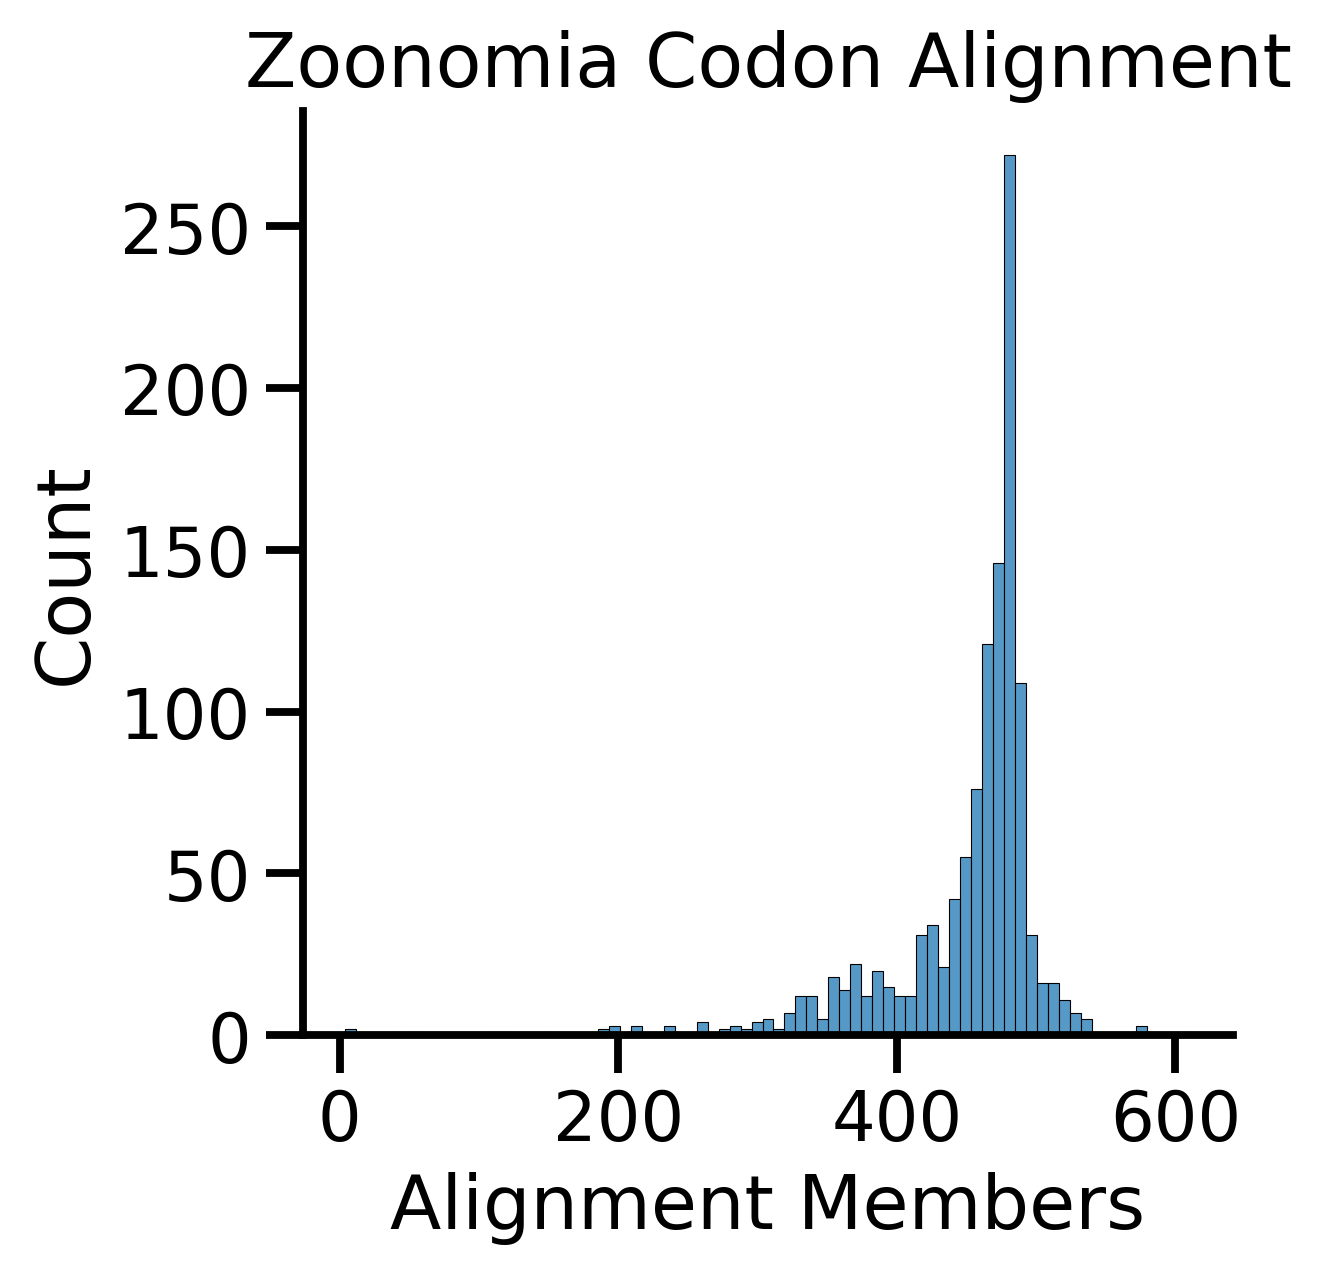

In [10]:
plot_alignment_hist("../data/zoonomia_toga_mca_all_TFs/prot_fastas/*")
plt.title("Zoonomia Codon Alignment")
plt.xlabel("Alignment Members")

Histograms

In [11]:
def return_big_df(folder_path):
    dfs = []
    for path in glob.glob(folder_path):
        dfs.append(pd.read_csv(path, sep = "\t", header = None, index_col = 0).reset_index())
    return pd.concat(dfs)

In [12]:
all_TFs = pd.read_csv("../soto_analysis/outputs/all_TFs_table_proteins.txt", sep = "\t")
activator_TFs = all_TFs.dropna(subset = "AD_coords")
activator_TFs

,Unnamed: 0,1,2,uniprotID,ENSG,ENST,DBD_coords,AD_coords,RD_coords,Bif_coords,length
13,13,NaN,NaN,A6NJG6,NaN,ENST00000334384,79-135,142-315,NaN,NaN,1
27,27,NaN,NaN,A8MTJ6,NaN,ENST00000428390,145-234,369-420,NaN,NaN,1
33,33,NaN,NaN,A8MYZ6,NaN,ENST00000641094,89-178,382-491,NaN,NaN,1
45,45,NaN,NaN,O00570,NaN,ENST00000330949,51-119,125-391,NaN,NaN,1
48,48,NaN,NaN,O14627,NaN,ENST00000373514,174-230,32-131,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
1571,1571,NaN,NaN,Q9Y458,NaN,ENST00000373294,94-283,402-481,NaN,NaN,1
1582,1582,NaN,NaN,Q9Y5R6,NaN,ENST00000382276,72-118,172-251,NaN,NaN,1
1585,1585,NaN,NaN,Q9Y692,NaN,ENST00000294409,89-165,422-573,NaN,NaN,1
1587,1587,NaN,NaN,Q9Y6Q9,NaN,ENST00000371998,31-83,621-1424,NaN,NaN,1


In [13]:
zoonomia_all_TFs = return_big_df("../soto_analysis/outputs/mutations/cds_zoonomia_all_TF_cds/*")
zoonomia_all_TFs

,0,1,2,3,4,5,6,7,8
0,2,27149134,27149135,ENST00000296096,1,2,27149134,27149135,4.624
1,2,27149135,27149136,ENST00000296096,1,2,27149135,27149136,6.891
2,2,27149136,27149137,ENST00000296096,1,2,27149136,27149137,1.666
3,2,27149137,27149138,ENST00000296096,1,2,27149137,27149138,5.833
4,2,27149138,27149139,ENST00000296096,1,2,27149138,27149139,-0.157
...,...,...,...,...,...,...,...,...,...
3842,16,49822680,49822681,ENST00000561648,-1,16,49822680,49822681,-5.099
3843,16,49822681,49822682,ENST00000561648,-1,16,49822681,49822682,0.452
3844,16,49822682,49822683,ENST00000561648,-1,16,49822682,49822683,-0.104
3845,16,49822683,49822684,ENST00000561648,-1,16,49822683,49822684,-0.824


In [14]:
len(set(zoonomia_all_TFs[3]))

1558

In [15]:
zoonomia_all_TFs[~zoonomia_all_TFs[3].isin(activator_TFs["ENST"])]

,0,1,2,3,4,5,6,7,8
0,2,27149134,27149135,ENST00000296096,1,2,27149134,27149135,4.624
1,2,27149135,27149136,ENST00000296096,1,2,27149135,27149136,6.891
2,2,27149136,27149137,ENST00000296096,1,2,27149136,27149137,1.666
3,2,27149137,27149138,ENST00000296096,1,2,27149137,27149138,5.833
4,2,27149138,27149139,ENST00000296096,1,2,27149138,27149139,-0.157
...,...,...,...,...,...,...,...,...,...
3842,16,49822680,49822681,ENST00000561648,-1,16,49822680,49822681,-5.099
3843,16,49822681,49822682,ENST00000561648,-1,16,49822681,49822682,0.452
3844,16,49822682,49822683,ENST00000561648,-1,16,49822682,49822683,-0.104
3845,16,49822683,49822684,ENST00000561648,-1,16,49822683,49822684,-0.824


Text(0.5, 0, 'Average Zoonomia PhyloP per TF')

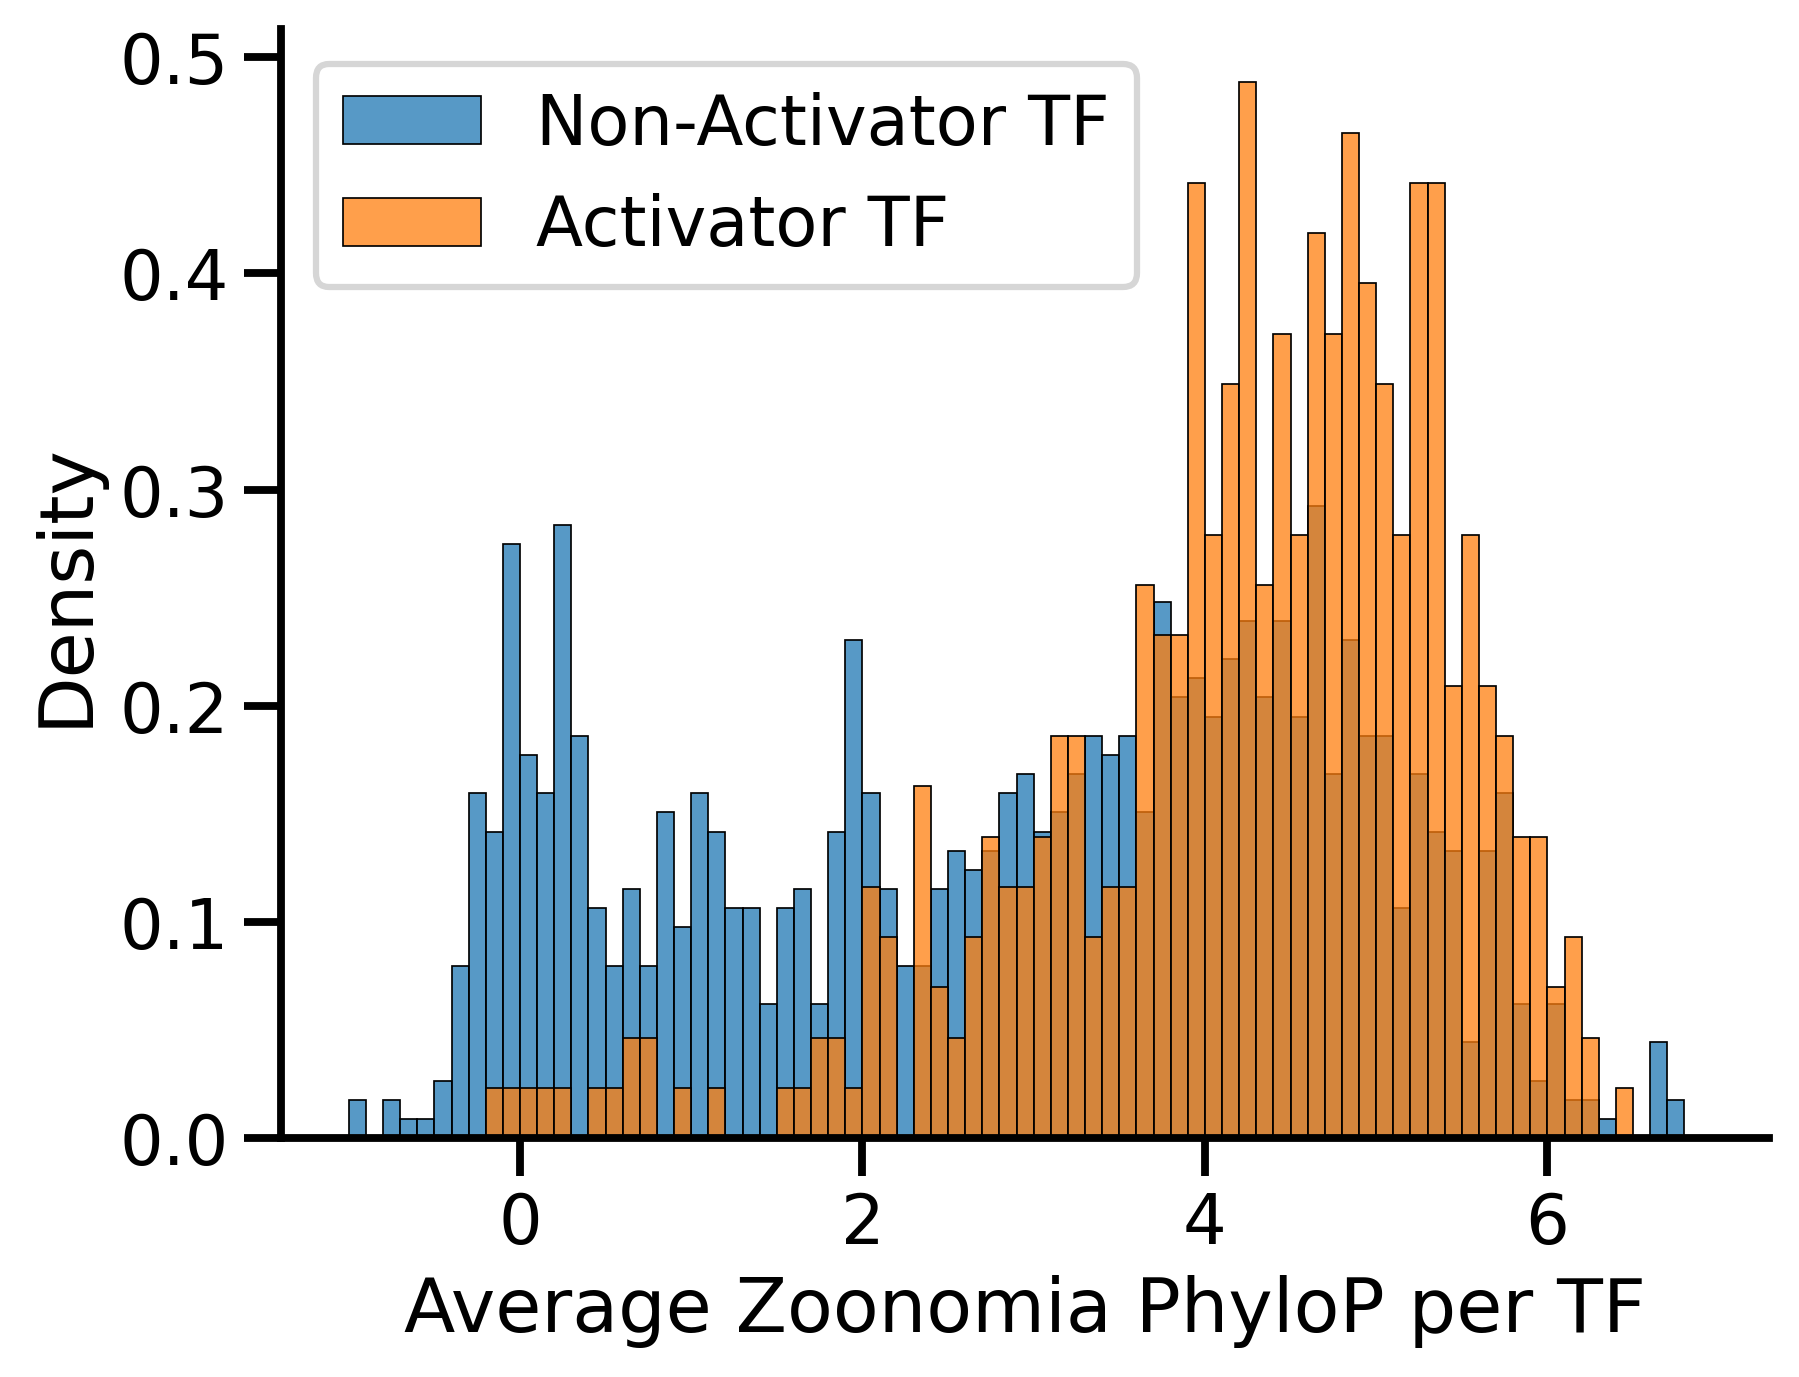

In [16]:
sns.set_context('talk')
plt.figure(dpi = 300)

df = zoonomia_all_TFs[~zoonomia_all_TFs[3].isin(activator_TFs["ENST"])]
sns.histplot(df[[3, 8]].groupby(3).mean()[8], stat = 'density', label = "Non-Activator TF", bins = np.arange(-1, 7, 0.1))

df = zoonomia_all_TFs[zoonomia_all_TFs[3].isin(activator_TFs["ENST"])]
sns.histplot(df[[3, 8]].groupby(3).mean()[8], stat = 'density', label = "Activator TF", bins = np.arange(-1, 7, 0.1))
sns.despine()
plt.legend()
plt.xlabel("Average Zoonomia PhyloP per TF")

Text(0.5, 0, 'Zoonomia PhyloP')

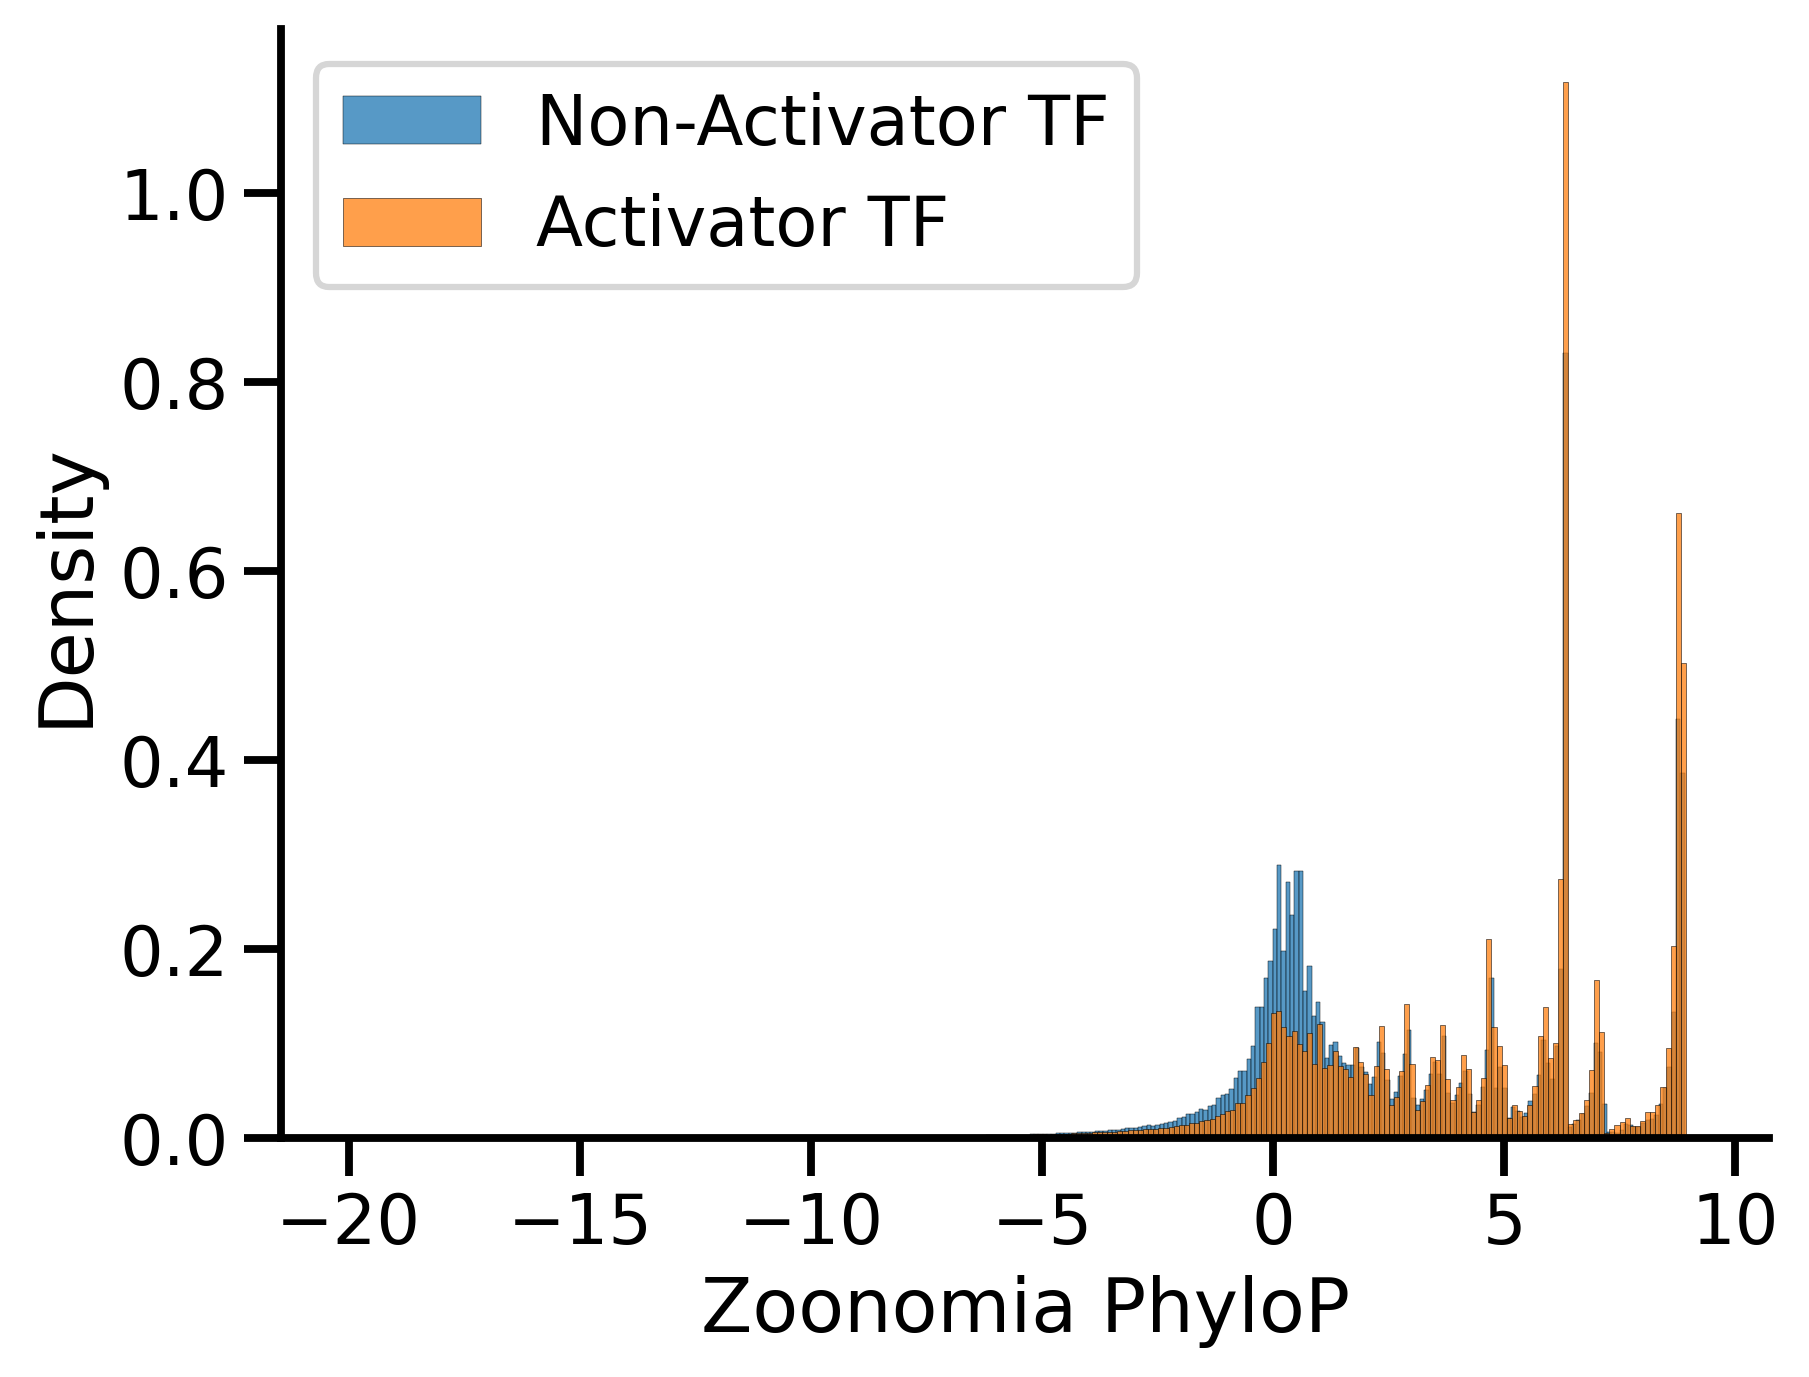

In [17]:
sns.set_context('talk')
plt.figure(dpi = 300)
df = zoonomia_all_TFs[~zoonomia_all_TFs[3].isin(activator_TFs["ENST"])]
sns.histplot(zoonomia_all_TFs[~zoonomia_all_TFs[3].isin(activator_TFs["ENST"])][8], stat = 'density', label = "Non-Activator TF")
sns.histplot(zoonomia_all_TFs[zoonomia_all_TFs[3].isin(activator_TFs["ENST"])][8], stat = 'density', label = "Activator TF")
sns.despine()
plt.legend()
plt.xlabel("Zoonomia PhyloP")

In [18]:
verteb_all_TFs = return_big_df("../soto_analysis/outputs/mutations/cds_100_verteb_all_TF_cds/*")
verteb_all_TFs

,0,1,2,3,4,5,6,7,8
0,2,27149134,27149135,ENST00000296096,1,2,27149134,27149135,2.594350
1,2,27149135,27149136,ENST00000296096,1,2,27149135,27149136,1.305030
2,2,27149136,27149137,ENST00000296096,1,2,27149136,27149137,-0.060134
3,2,27149137,27149138,ENST00000296096,1,2,27149137,27149138,2.594350
4,2,27149138,27149139,ENST00000296096,1,2,27149138,27149139,-0.211819
...,...,...,...,...,...,...,...,...,...
3842,16,49822680,49822681,ENST00000561648,-1,16,49822680,49822681,-1.623430
3843,16,49822681,49822682,ENST00000561648,-1,16,49822681,49822682,-0.067441
3844,16,49822682,49822683,ENST00000561648,-1,16,49822682,49822683,-0.660197
3845,16,49822683,49822684,ENST00000561648,-1,16,49822683,49822684,-1.030670


In [19]:
len(set(verteb_all_TFs[3]))

1558

Text(0.5, 0, 'Average 100 Vertebrates PhyloP per TF')

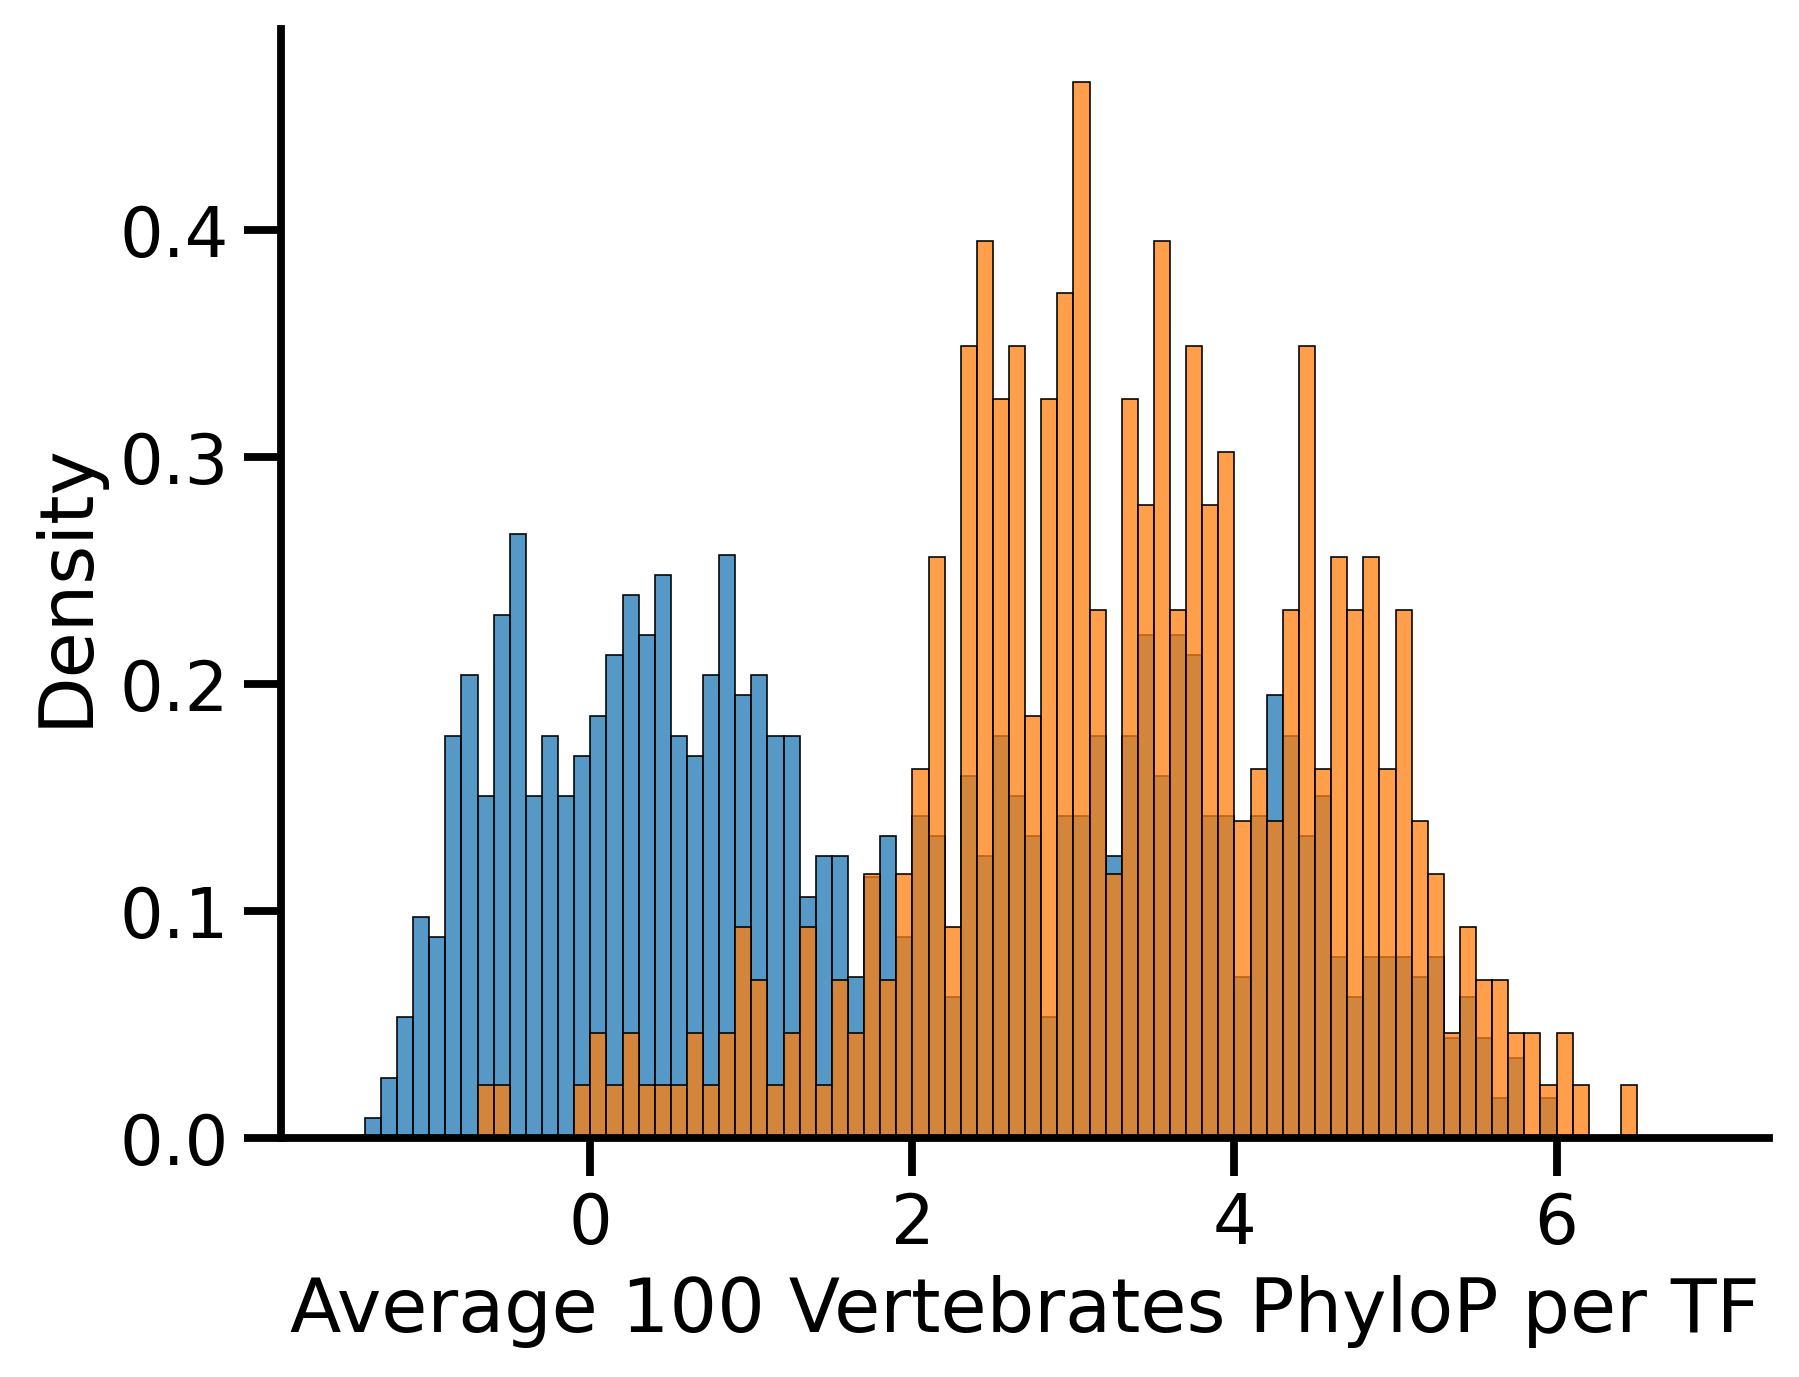

In [20]:
sns.set_context('talk')
plt.figure(dpi = 300)

df = verteb_all_TFs[~verteb_all_TFs[3].isin(activator_TFs["ENST"])]
sns.histplot(df[[3, 8]].groupby(3).mean()[8], stat = 'density', label = "Non-Activator TF", bins = np.arange(-1.5, 7, 0.1))

df = verteb_all_TFs[verteb_all_TFs[3].isin(activator_TFs["ENST"])]
sns.histplot(df[[3, 8]].groupby(3).mean()[8], stat = 'density', label = "Activator TF", bins = np.arange(-1.5, 7, 0.1))

sns.despine()
#plt.legend()
plt.xlabel("Average 100 Vertebrates PhyloP per TF")

In [31]:
# From http://localhost:8888/notebooks/Desktop/Staller_Lab/SFARI/soto_analysis/notebooks/All%20hit%20gene%20names.ipynb

# hits = ['ARX',
#  'CAMTA2',
#  'CASZ1',
#  'ERG',
#  'IKZF1',
#  'MEIS2',
#  'NCOA1',
#  'NKX2-2',
#  'NR1D1',
#  'NR4A2',
#  'OTX1',
#  'PAX5',
#  'PAX6',
#  'PITX1',
#  'RORA',
#  'TCF7L2',
#  'YY1']

hits = ["ARX", "CAMTA2", "CASZ1", "ERG", "HIVEP3", "KDM5B", "KLF7", "KLF16", "MEIS2", "MTF1", "MYT1L", "NCOA1", "NKX2-2", "NR1D1", "NR4A2", "OTX1", "PAX5", "PAX6", "PITX1", "RORA", "TCF7L2", "TFE3", "YY1"]

lambert_TFs = pd.read_csv("../output/lambert_TFs_LOEUF_group_info.csv")
lambert_TFs

lambert_TFs["hits"] = lambert_TFs["From"].isin(hits)
lambert_TFs
zoonomia_activator_TFs = zoonomia_all_TFs[zoonomia_all_TFs[3].isin(lambert_TFs[lambert_TFs["activator"]]["transcript"])]
zoonomia_SFARI_activator_TFs = zoonomia_all_TFs[zoonomia_all_TFs[3].isin(lambert_TFs[lambert_TFs["sfari"] & lambert_TFs["activator"]]["transcript"])]
zoonomia_SFARI_TF_hits = zoonomia_all_TFs[zoonomia_all_TFs[3].isin(lambert_TFs[lambert_TFs["hits"]]["transcript"])]

In [32]:
lambert_TFs

,Unnamed: 0,gene_id,gene,From,Entry,Gene Names (primary),LOEUF,transcript,repressor,activator,sfari,hits
0,0,ENSG00000137203,TFAP2A,TFAP2A,P05549,TFAP2A,0.334,ENST00000379613,False,True,False,False
1,1,ENSG00000008196,TFAP2B,TFAP2B,Q92481,TFAP2B,0.353,ENST00000393655,True,True,False,False
2,2,ENSG00000087510,TFAP2C,TFAP2C,Q92754,TFAP2C,0.417,ENST00000201031,True,True,False,False
3,3,ENSG00000008197,TFAP2D,TFAP2D,Q7Z6R9,TFAP2D,0.389,ENST00000008391,False,True,False,False
4,4,ENSG00000116819,TFAP2E,TFAP2E,Q6VUC0,TFAP2E,1.418,ENST00000373235,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1658,1658,ENSG00000177683,THAP5,THAP5,Q7Z6K1,THAP5,1.089,ENST00000415914,True,False,False,False
1659,1659,ENSG00000174796,THAP6,THAP6,Q8TBB0,THAP6,1.028,ENST00000311638,True,False,False,False
1660,1660,ENSG00000184436,THAP7,THAP7,Q9BT49,THAP7,1.147,ENST00000215742,True,False,False,False
1661,1661,ENSG00000161277,THAP8,THAP8,Q8NA92,THAP8,1.615,ENST00000292894,True,False,False,False


In [33]:
verteb_activator_TFs = verteb_all_TFs[verteb_all_TFs[3].isin(lambert_TFs[lambert_TFs["activator"]]["transcript"])]
verteb_SFARI_activator_TFs = verteb_all_TFs[verteb_all_TFs[3].isin(lambert_TFs[lambert_TFs["sfari"] & lambert_TFs["activator"]]["transcript"])]
verteb_SFARI_TF_hits = verteb_all_TFs[verteb_all_TFs[3].isin(lambert_TFs[lambert_TFs["hits"]]["transcript"])]

In [34]:
verteb_activator_TFs["key"] = "chr" + verteb_activator_TFs[0].astype(str) + "_" + verteb_activator_TFs[1].astype(str)
verteb_activator_TFs

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_99639/2804062289.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  verteb_activator_TFs["key"] = "chr" + verteb_activator_TFs[0].astype(str) + "_" + verteb_activator_TFs[1].astype(str)


,0,1,2,3,4,5,6,7,8,key
0,6,53128206,53128207,ENST00000259803,-1,6,53128206,53128207,1.030160,chr6_53128206
1,6,53128207,53128208,ENST00000259803,-1,6,53128207,53128208,3.733460,chr6_53128207
2,6,53128208,53128209,ENST00000259803,-1,6,53128208,53128209,0.309276,chr6_53128208
3,6,53128209,53128210,ENST00000259803,-1,6,53128209,53128210,2.021370,chr6_53128209
4,6,53128210,53128211,ENST00000259803,-1,6,53128210,53128211,0.309276,chr6_53128210
...,...,...,...,...,...,...,...,...,...,...
2060,19,15379726,15379727,ENST00000269701,-1,19,15379726,15379727,2.350910,chr19_15379726
2061,19,15379727,15379728,ENST00000269701,-1,19,15379727,15379728,2.350910,chr19_15379727
2062,19,15379728,15379729,ENST00000269701,-1,19,15379728,15379729,3.741970,chr19_15379728
2063,19,15379729,15379730,ENST00000269701,-1,19,15379729,15379730,2.930520,chr19_15379729


In [36]:
verteb_domains = return_big_df("../soto_analysis/outputs/mutations/domains_100_verteb_all_TF_cds/*")
verteb_domains

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,2,27150134,27150135,DBD,NaN,.,1,ENST00000296096,2,27150134,27150135,ENST00000296096,1,2,27150134,27150135,3.32643
1,2,27150135,27150136,DBD,NaN,.,1,ENST00000296096,2,27150135,27150136,ENST00000296096,1,2,27150135,27150136,6.05776
2,2,27150136,27150137,DBD,NaN,.,1,ENST00000296096,2,27150136,27150137,ENST00000296096,1,2,27150136,27150137,-1.22577
3,2,27150137,27150138,DBD,NaN,.,1,ENST00000296096,2,27150137,27150138,ENST00000296096,1,2,27150137,27150138,3.78165
4,2,27150138,27150139,DBD,NaN,.,1,ENST00000296096,2,27150138,27150139,ENST00000296096,1,2,27150138,27150139,4.08513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3715,16,49636020,49636021,IDR,NaN,.,-1,ENST00000561648,16,49636020,49636021,ENST00000561648,-1,16,49636020,49636021,8.01568
3716,16,49636021,49636022,IDR,NaN,.,-1,ENST00000561648,16,49636021,49636022,ENST00000561648,-1,16,49636021,49636022,10.00300
3717,16,49636022,49636023,IDR,NaN,.,-1,ENST00000561648,16,49636022,49636023,ENST00000561648,-1,16,49636022,49636023,7.88319
3718,16,49636023,49636024,IDR,NaN,.,-1,ENST00000561648,16,49636023,49636024,ENST00000561648,-1,16,49636023,49636024,7.48572


In [37]:
verteb_domains["key"] = "chr" + verteb_domains[0].astype(str) + "_" + verteb_domains[1].astype(str)
verteb_domains = verteb_domains[verteb_domains[3] != "RD"]
verteb_domains

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,key
0,2,27150134,27150135,DBD,NaN,.,1,ENST00000296096,2,27150134,27150135,ENST00000296096,1,2,27150134,27150135,3.32643,chr2_27150134
1,2,27150135,27150136,DBD,NaN,.,1,ENST00000296096,2,27150135,27150136,ENST00000296096,1,2,27150135,27150136,6.05776,chr2_27150135
2,2,27150136,27150137,DBD,NaN,.,1,ENST00000296096,2,27150136,27150137,ENST00000296096,1,2,27150136,27150137,-1.22577,chr2_27150136
3,2,27150137,27150138,DBD,NaN,.,1,ENST00000296096,2,27150137,27150138,ENST00000296096,1,2,27150137,27150138,3.78165,chr2_27150137
4,2,27150138,27150139,DBD,NaN,.,1,ENST00000296096,2,27150138,27150139,ENST00000296096,1,2,27150138,27150139,4.08513,chr2_27150138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3715,16,49636020,49636021,IDR,NaN,.,-1,ENST00000561648,16,49636020,49636021,ENST00000561648,-1,16,49636020,49636021,8.01568,chr16_49636020
3716,16,49636021,49636022,IDR,NaN,.,-1,ENST00000561648,16,49636021,49636022,ENST00000561648,-1,16,49636021,49636022,10.00300,chr16_49636021
3717,16,49636022,49636023,IDR,NaN,.,-1,ENST00000561648,16,49636022,49636023,ENST00000561648,-1,16,49636022,49636023,7.88319,chr16_49636022
3718,16,49636023,49636024,IDR,NaN,.,-1,ENST00000561648,16,49636023,49636024,ENST00000561648,-1,16,49636023,49636024,7.48572,chr16_49636023


In [38]:
verteb_activator_TFs_non_dom = verteb_activator_TFs[~verteb_activator_TFs["key"].isin(verteb_domains["key"])]
verteb_activator_TFs_non_dom

,0,1,2,3,4,5,6,7,8,key
227,2,70900849,70900850,ENST00000234392,1,2,70900849,70900850,3.954260,chr2_70900849
228,2,70900850,70900851,ENST00000234392,1,2,70900850,70900851,2.526170,chr2_70900850
229,2,70900851,70900852,ENST00000234392,1,2,70900851,70900852,3.954260,chr2_70900851
230,2,70900852,70900853,ENST00000234392,1,2,70900852,70900853,3.954260,chr2_70900852
231,2,70900853,70900854,ENST00000234392,1,2,70900853,70900854,3.240210,chr2_70900853
...,...,...,...,...,...,...,...,...,...,...
934,14,64260746,64260747,ENST00000341099,-1,14,64260746,64260747,0.063181,chr14_64260746
935,14,64260747,64260748,ENST00000341099,-1,14,64260747,64260748,6.531720,chr14_64260747
936,14,64268795,64268796,ENST00000341099,-1,14,64268795,64268796,0.162835,chr14_64268795
937,14,64268796,64268797,ENST00000341099,-1,14,64268796,64268797,4.810590,chr14_64268796


In [39]:
# plt.figure(dpi = 300)

# bins = np.arange(-1, 7, 0.1)


# # df = zoonomia_domains[zoonomia_domains[3] == "AD"]
# # sns.histplot(df[[7, 16]].groupby(7).mean()[16], label = "AD", color = "C1", bins = bins, stat = 'density')
# # #plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "C1", linestyle = "--")

# df = zoonomia_domains[zoonomia_domains[3] == "DBD"]
# sns.histplot(df[[7, 16]].groupby(7).mean()[16], label = "DBD", bins = bins, stat = 'density', color = "purple")
# #plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "purple", linestyle = "--")



# #plt.legend()
# plt.xlabel("Average Zoononmia PhyloP per TF")
# sns.despine()

Text(0.5, 0, 'Average 100 Vertebrates PhyloP per TF')

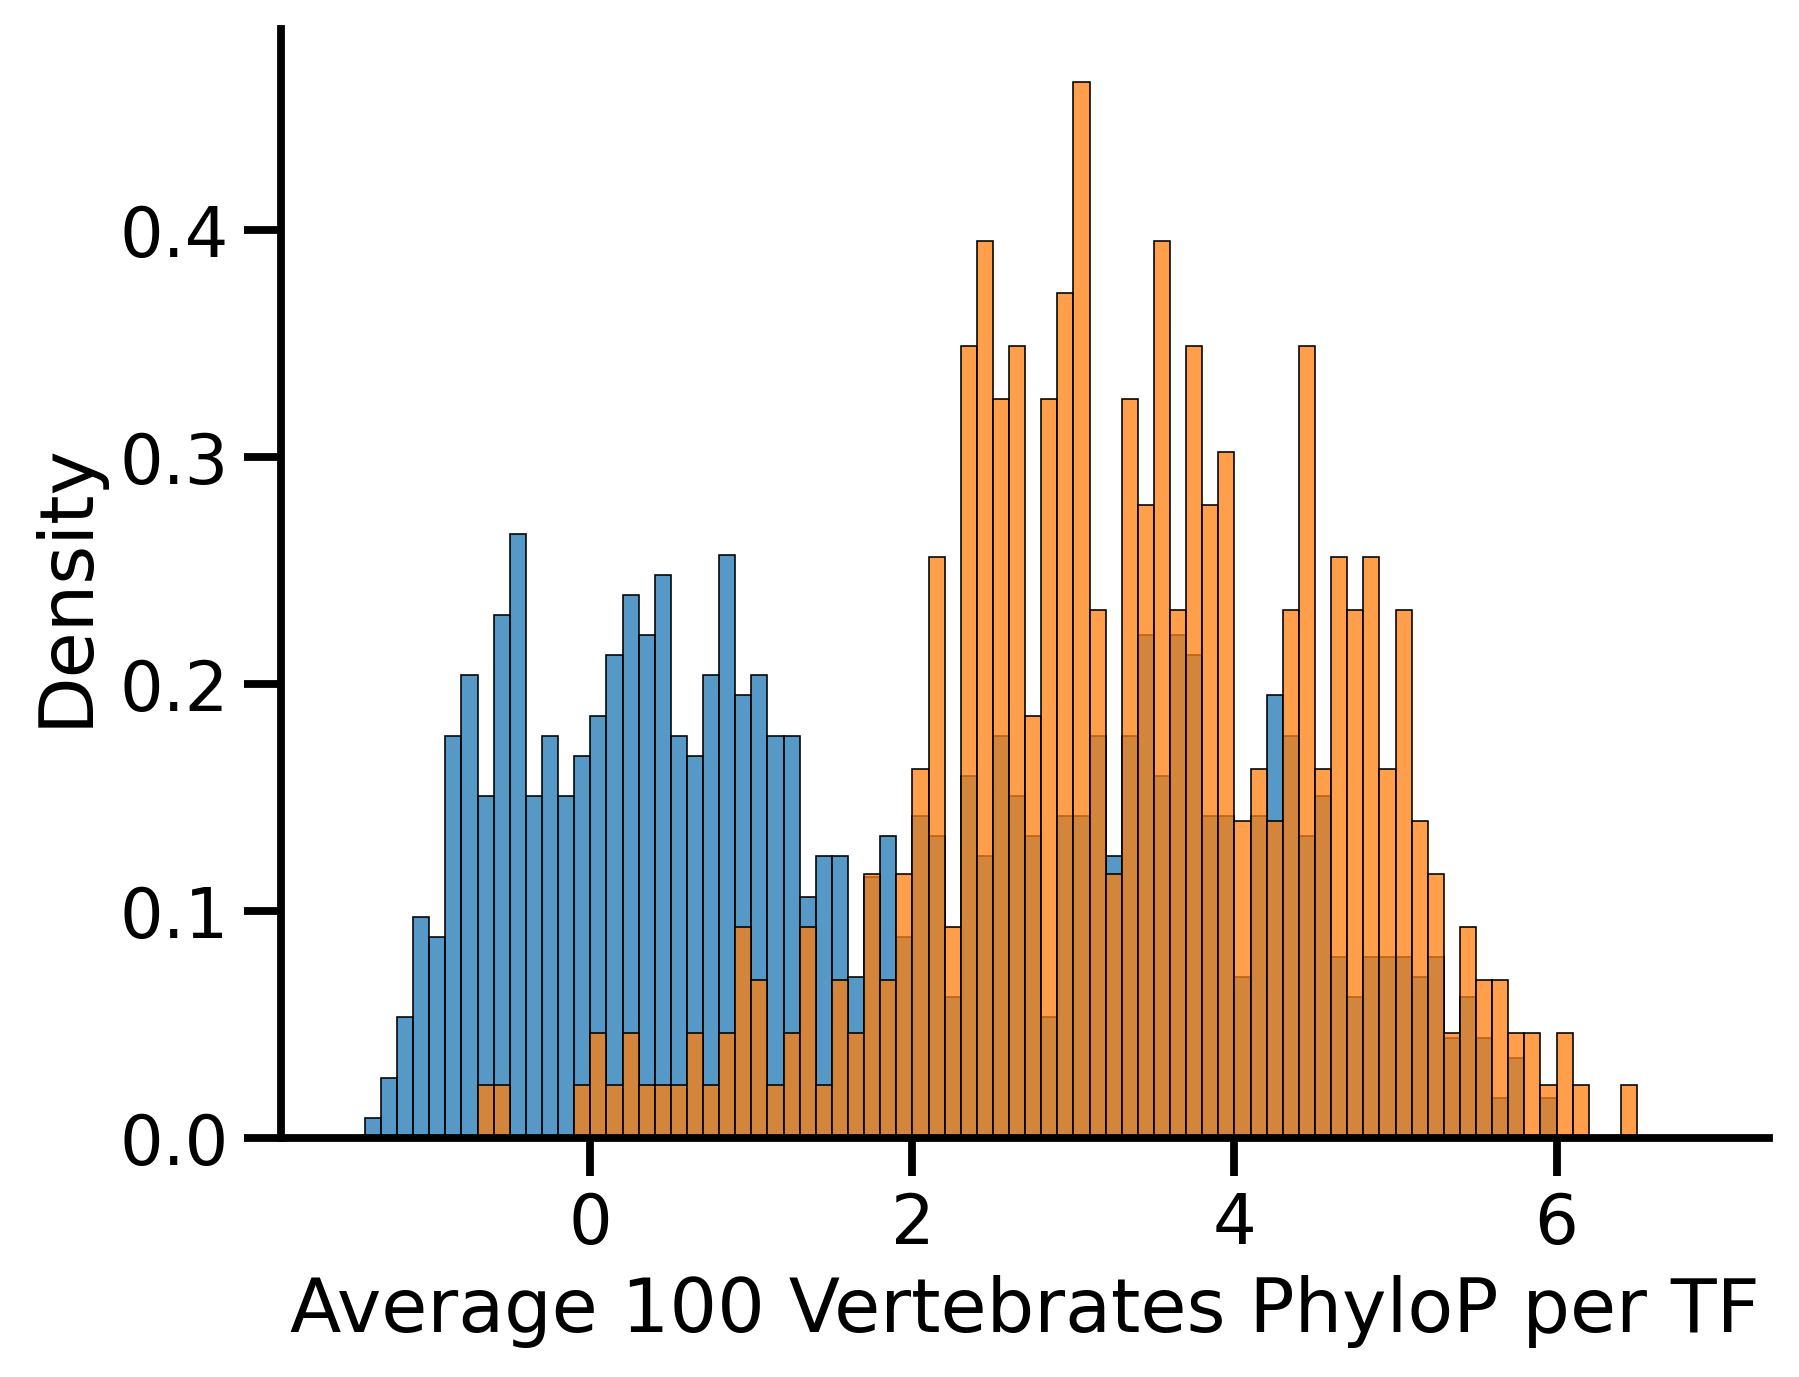

In [40]:
sns.set_context('talk')
plt.figure(dpi = 300)

df = verteb_all_TFs[~verteb_all_TFs[3].isin(activator_TFs["ENST"])]
sns.histplot(df[[3, 8]].groupby(3).mean()[8], stat = 'density', label = "Non-Activator TF", bins = np.arange(-1.5, 7, 0.1))

df = verteb_all_TFs[verteb_all_TFs[3].isin(activator_TFs["ENST"])]
sns.histplot(df[[3, 8]].groupby(3).mean()[8], stat = 'density', label = "Activator TF", bins = np.arange(-1.5, 7, 0.1))

sns.despine()
#plt.legend()
plt.xlabel("Average 100 Vertebrates PhyloP per TF")

Text(0.5, 0, '100 Vertebrates PhyloP')

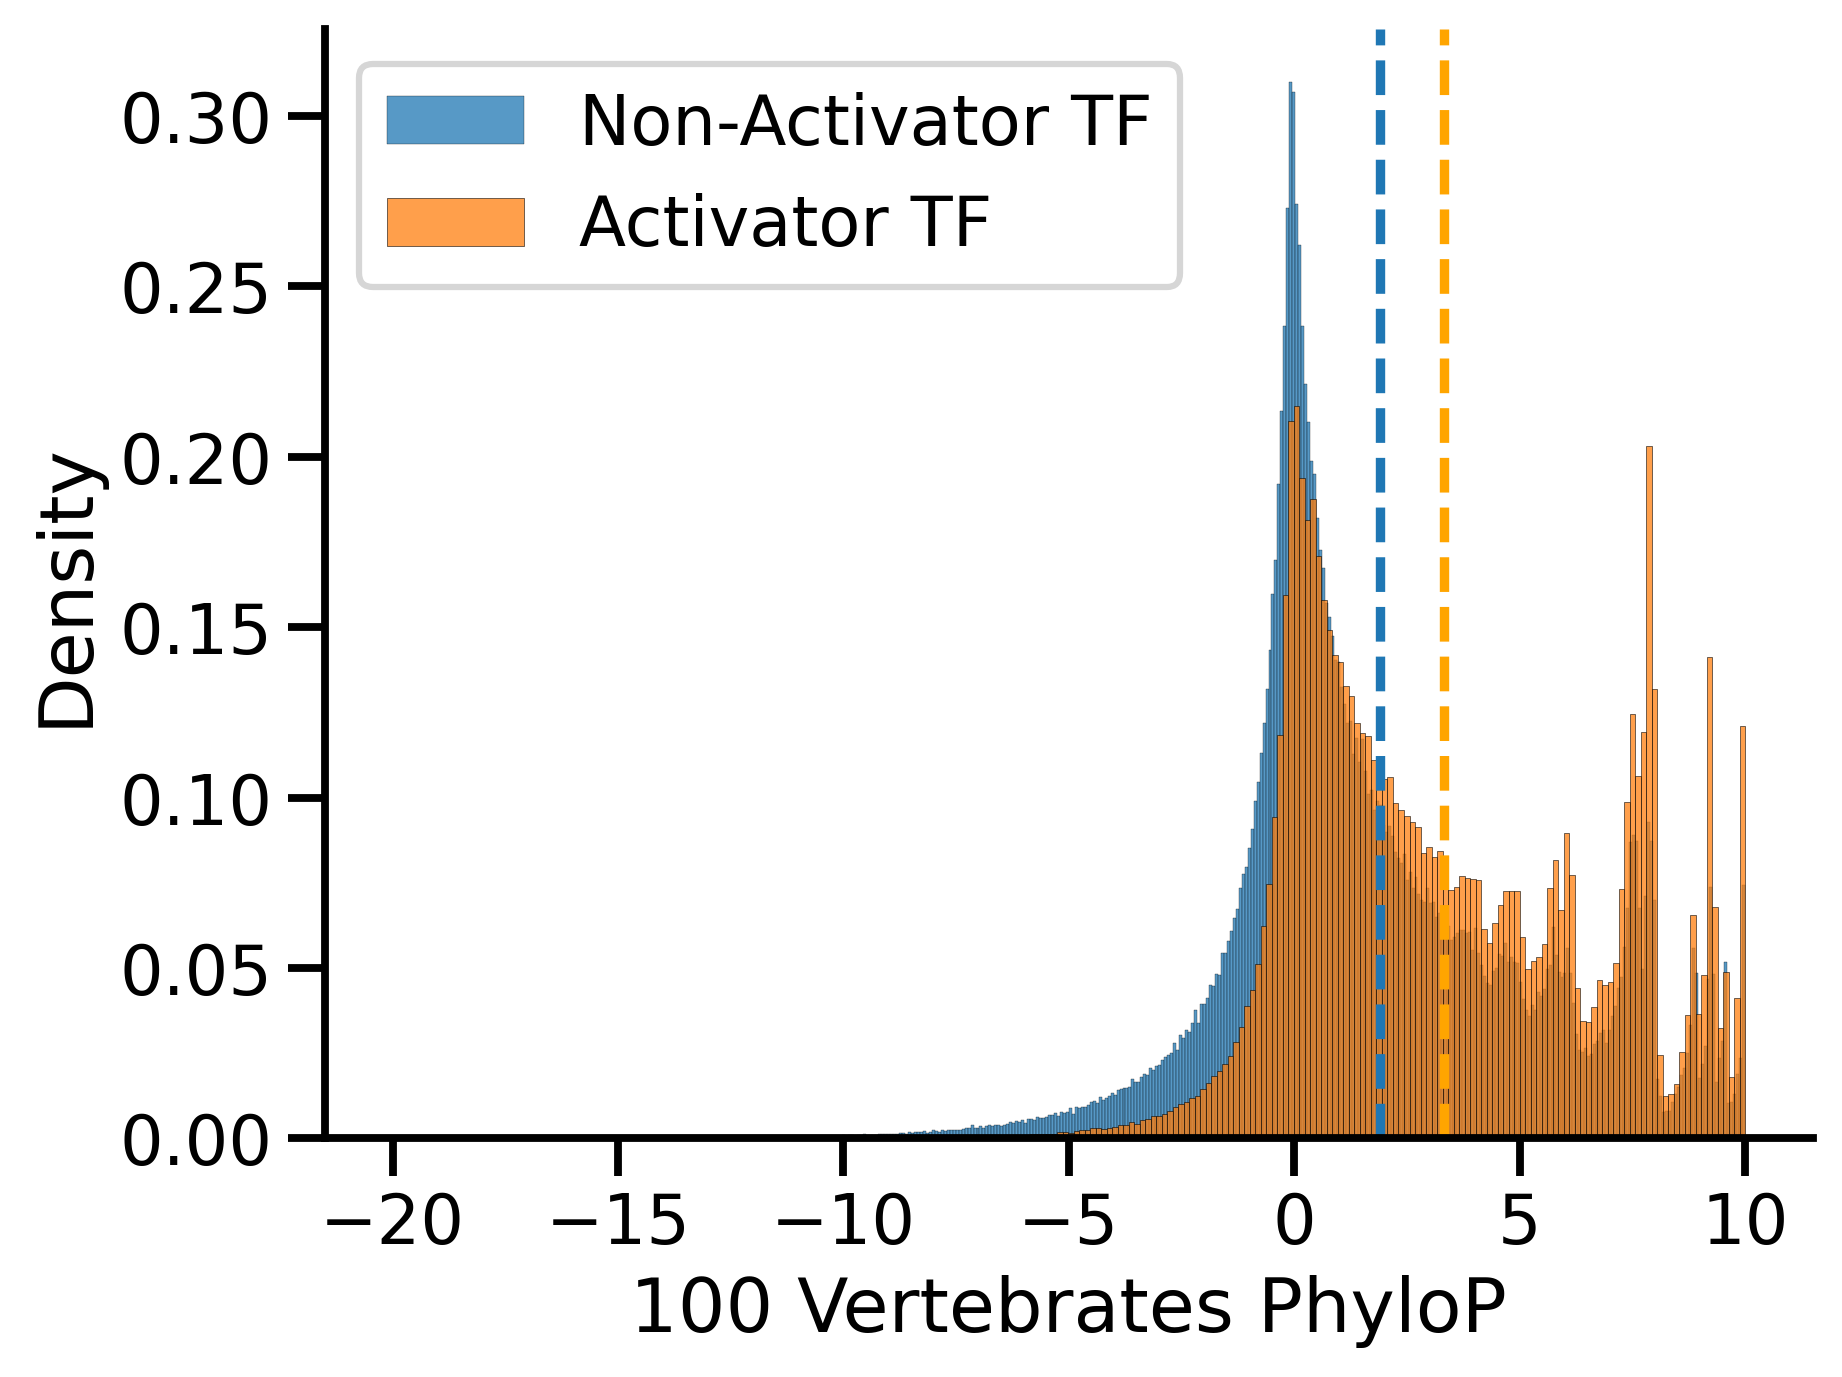

In [41]:
sns.set_context('talk')
plt.figure(dpi = 300)
sns.histplot(verteb_all_TFs[~verteb_all_TFs[3].isin(activator_TFs["ENST"])][8], stat = 'density', label = "Non-Activator TF")
plt.axvline(np.mean(verteb_all_TFs[~verteb_all_TFs[3].isin(activator_TFs["ENST"])][8]), linestyle = "--")
sns.histplot(verteb_all_TFs[verteb_all_TFs[3].isin(activator_TFs["ENST"])][8], stat = 'density', label = "Activator TF")
plt.axvline(np.mean(verteb_all_TFs[verteb_all_TFs[3].isin(activator_TFs["ENST"])][8]), color = 'orange', linestyle = "--")
sns.despine()
plt.legend()
plt.xlabel("100 Vertebrates PhyloP")

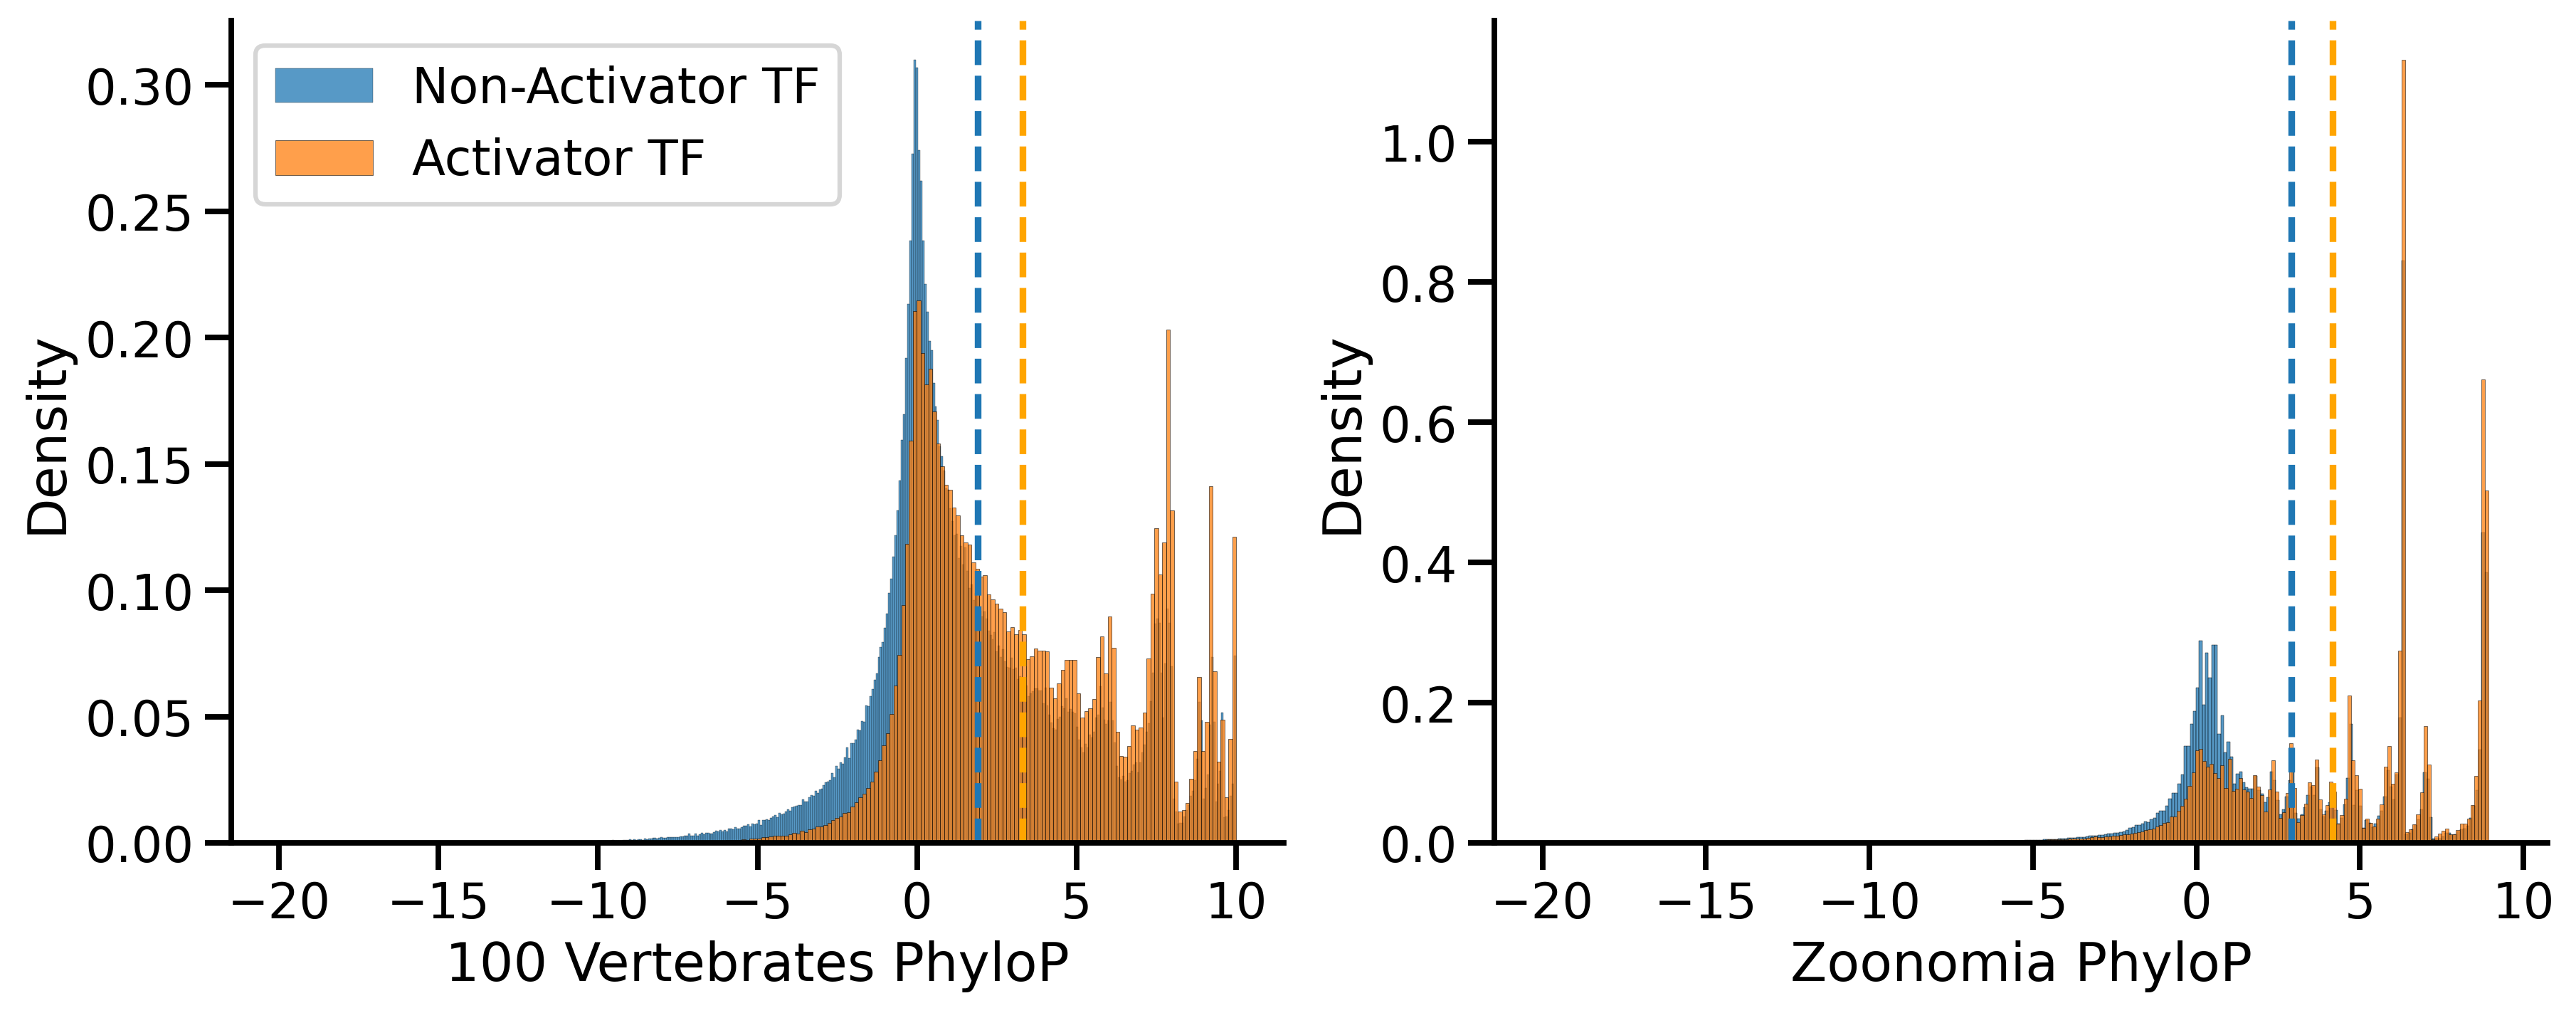

In [42]:
fig, axs = plt.subplots(1, 2, figsize = (14, 5), dpi = 300)
sns.set_context('talk')

axs = [axs[1], axs[0]]

sns.histplot(verteb_all_TFs[~verteb_all_TFs[3].isin(activator_TFs["ENST"])][8], 
             stat = 'density', label = "Non-Activator TF", ax = axs[1])
axs[1].axvline(np.mean(verteb_all_TFs[~verteb_all_TFs[3].isin(activator_TFs["ENST"])][8]), 
            linestyle = "--")
sns.histplot(verteb_all_TFs[verteb_all_TFs[3].isin(activator_TFs["ENST"])][8], 
             stat = 'density', label = "Activator TF", ax = axs[1])
axs[1].axvline(np.mean(verteb_all_TFs[verteb_all_TFs[3].isin(activator_TFs["ENST"])][8]), 
            color = 'orange', linestyle = "--")
axs[1].set_xlabel("100 Vertebrates PhyloP")


sns.despine()
axs[1].legend()


sns.histplot(zoonomia_all_TFs[~zoonomia_all_TFs[3].isin(activator_TFs["ENST"])][8], 
             stat = 'density', label = "Non-Activator TF", ax = axs[0])
sns.histplot(zoonomia_all_TFs[zoonomia_all_TFs[3].isin(activator_TFs["ENST"])][8], 
             stat = 'density', label = "Activator TF", ax = axs[0])
axs[0].axvline(np.mean(zoonomia_all_TFs[~zoonomia_all_TFs[3].isin(activator_TFs["ENST"])][8]), 
            linestyle = "--")
axs[0].axvline(np.mean(zoonomia_all_TFs[zoonomia_all_TFs[3].isin(activator_TFs["ENST"])][8]), 
            color = 'orange', linestyle = "--")
axs[0].set_xlabel("Zoonomia PhyloP")

sns.despine()
#plt.legend()


In [43]:
zoonomia_domains = return_big_df("../soto_analysis/outputs/mutations/domains_zoonomia_all_TF_cds/*")
zoonomia_domains

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,2,27150134,27150135,DBD,NaN,.,1,ENST00000296096,2,27150134,27150135,ENST00000296096,1,2,27150134,27150135,7.051
1,2,27150135,27150136,DBD,NaN,.,1,ENST00000296096,2,27150135,27150136,ENST00000296096,1,2,27150135,27150136,7.020
2,2,27150136,27150137,DBD,NaN,.,1,ENST00000296096,2,27150136,27150137,ENST00000296096,1,2,27150136,27150137,-3.174
3,2,27150137,27150138,DBD,NaN,.,1,ENST00000296096,2,27150137,27150138,ENST00000296096,1,2,27150137,27150138,3.950
4,2,27150138,27150139,DBD,NaN,.,1,ENST00000296096,2,27150138,27150139,ENST00000296096,1,2,27150138,27150139,6.274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3715,16,49636020,49636021,IDR,NaN,.,-1,ENST00000561648,16,49636020,49636021,ENST00000561648,-1,16,49636020,49636021,4.732
3716,16,49636021,49636022,IDR,NaN,.,-1,ENST00000561648,16,49636021,49636022,ENST00000561648,-1,16,49636021,49636022,8.779
3717,16,49636022,49636023,IDR,NaN,.,-1,ENST00000561648,16,49636022,49636023,ENST00000561648,-1,16,49636022,49636023,8.885
3718,16,49636023,49636024,IDR,NaN,.,-1,ENST00000561648,16,49636023,49636024,ENST00000561648,-1,16,49636023,49636024,6.323


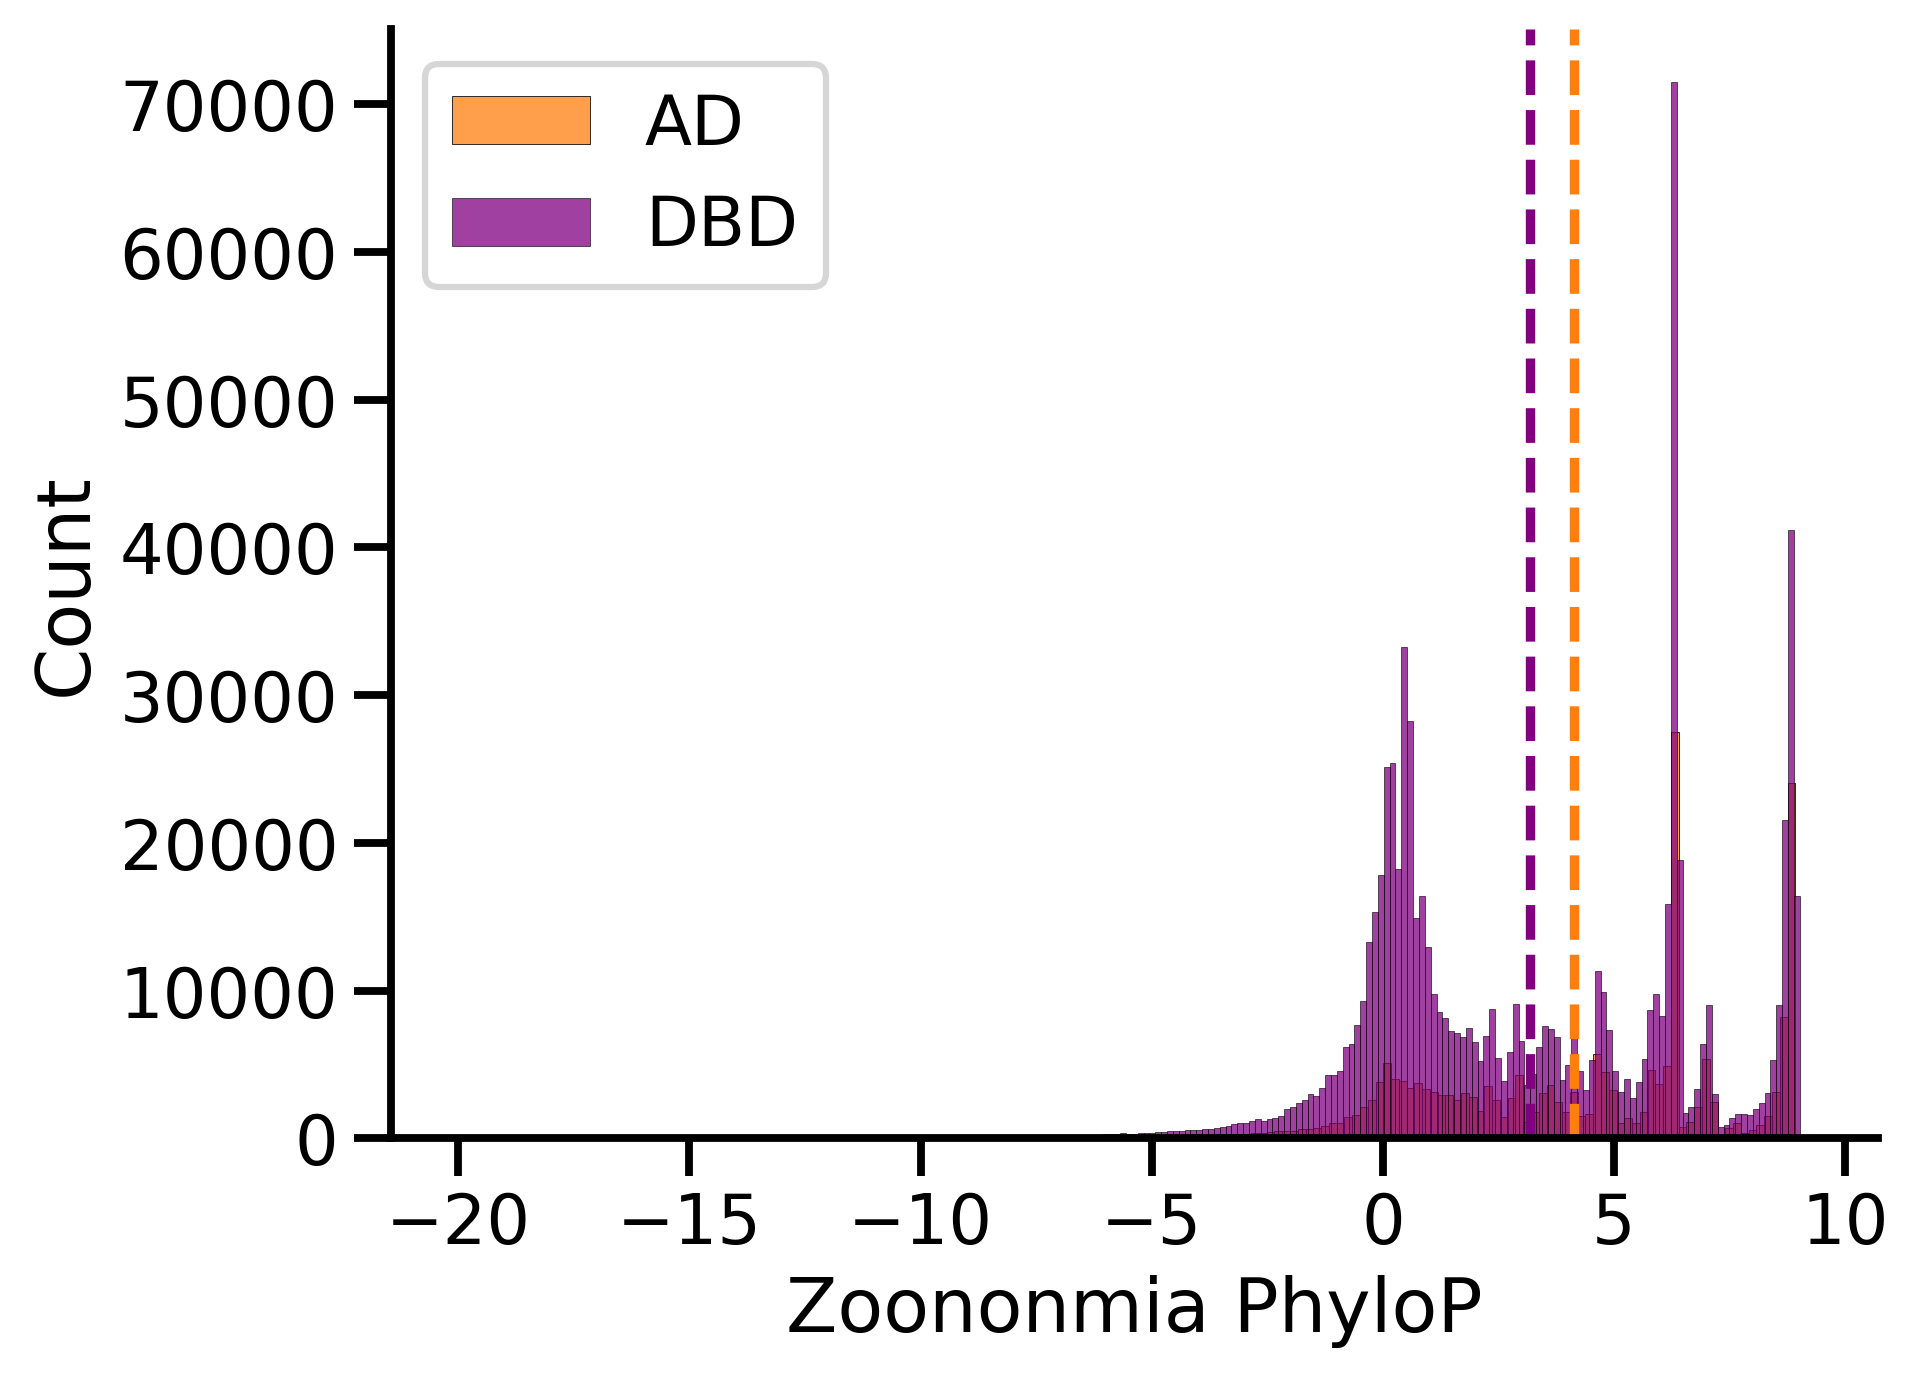

In [44]:
plt.figure(dpi = 300)
sns.histplot(zoonomia_domains[zoonomia_domains[3] == "AD"][16], label = "AD", color = "C1")
plt.axvline(np.mean(zoonomia_domains[zoonomia_domains[3] == "AD"][16]), color = "C1", linestyle = "--")

sns.histplot(zoonomia_domains[zoonomia_domains[3] == "DBD"][16], label = "DBD", color = "purple")
plt.axvline(np.mean(zoonomia_domains[zoonomia_domains[3] == "DBD"][16]), color = "purple", linestyle = "--")

plt.legend()
plt.xlabel("Zoononmia PhyloP")
sns.despine()

In [45]:
zoonomia_activator_TFs

,0,1,2,3,4,5,6,7,8
0,6,53128206,53128207,ENST00000259803,-1,6,53128206,53128207,3.506
1,6,53128207,53128208,ENST00000259803,-1,6,53128207,53128208,4.649
2,6,53128208,53128209,ENST00000259803,-1,6,53128208,53128209,1.790
3,6,53128209,53128210,ENST00000259803,-1,6,53128209,53128210,5.710
4,6,53128210,53128211,ENST00000259803,-1,6,53128210,53128211,0.398
...,...,...,...,...,...,...,...,...,...
2060,19,15379726,15379727,ENST00000269701,-1,19,15379726,15379727,4.610
2061,19,15379727,15379728,ENST00000269701,-1,19,15379727,15379728,8.697
2062,19,15379728,15379729,ENST00000269701,-1,19,15379728,15379729,8.697
2063,19,15379729,15379730,ENST00000269701,-1,19,15379729,15379730,6.192


In [46]:
# zoonomia_all_TFs

In [47]:
zoonomia_activator_TFs["key"] = "chr" + zoonomia_activator_TFs[0].astype(str) + "_" + zoonomia_activator_TFs[1].astype(str)
zoonomia_activator_TFs

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_99639/470671852.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zoonomia_activator_TFs["key"] = "chr" + zoonomia_activator_TFs[0].astype(str) + "_" + zoonomia_activator_TFs[1].astype(str)


,0,1,2,3,4,5,6,7,8,key
0,6,53128206,53128207,ENST00000259803,-1,6,53128206,53128207,3.506,chr6_53128206
1,6,53128207,53128208,ENST00000259803,-1,6,53128207,53128208,4.649,chr6_53128207
2,6,53128208,53128209,ENST00000259803,-1,6,53128208,53128209,1.790,chr6_53128208
3,6,53128209,53128210,ENST00000259803,-1,6,53128209,53128210,5.710,chr6_53128209
4,6,53128210,53128211,ENST00000259803,-1,6,53128210,53128211,0.398,chr6_53128210
...,...,...,...,...,...,...,...,...,...,...
2060,19,15379726,15379727,ENST00000269701,-1,19,15379726,15379727,4.610,chr19_15379726
2061,19,15379727,15379728,ENST00000269701,-1,19,15379727,15379728,8.697,chr19_15379727
2062,19,15379728,15379729,ENST00000269701,-1,19,15379728,15379729,8.697,chr19_15379728
2063,19,15379729,15379730,ENST00000269701,-1,19,15379729,15379730,6.192,chr19_15379729


In [48]:
zoonomia_domains["key"] = "chr" + zoonomia_domains[0].astype(str) + "_" + zoonomia_domains[1].astype(str)
zoonomia_domains = zoonomia_domains[zoonomia_domains[3] != "RD"] # DROP RD INFO
zoonomia_domains

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,key
0,2,27150134,27150135,DBD,NaN,.,1,ENST00000296096,2,27150134,27150135,ENST00000296096,1,2,27150134,27150135,7.051,chr2_27150134
1,2,27150135,27150136,DBD,NaN,.,1,ENST00000296096,2,27150135,27150136,ENST00000296096,1,2,27150135,27150136,7.020,chr2_27150135
2,2,27150136,27150137,DBD,NaN,.,1,ENST00000296096,2,27150136,27150137,ENST00000296096,1,2,27150136,27150137,-3.174,chr2_27150136
3,2,27150137,27150138,DBD,NaN,.,1,ENST00000296096,2,27150137,27150138,ENST00000296096,1,2,27150137,27150138,3.950,chr2_27150137
4,2,27150138,27150139,DBD,NaN,.,1,ENST00000296096,2,27150138,27150139,ENST00000296096,1,2,27150138,27150139,6.274,chr2_27150138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3715,16,49636020,49636021,IDR,NaN,.,-1,ENST00000561648,16,49636020,49636021,ENST00000561648,-1,16,49636020,49636021,4.732,chr16_49636020
3716,16,49636021,49636022,IDR,NaN,.,-1,ENST00000561648,16,49636021,49636022,ENST00000561648,-1,16,49636021,49636022,8.779,chr16_49636021
3717,16,49636022,49636023,IDR,NaN,.,-1,ENST00000561648,16,49636022,49636023,ENST00000561648,-1,16,49636022,49636023,8.885,chr16_49636022
3718,16,49636023,49636024,IDR,NaN,.,-1,ENST00000561648,16,49636023,49636024,ENST00000561648,-1,16,49636023,49636024,6.323,chr16_49636023


In [49]:
zoonomia_activator_TFs_non_dom = zoonomia_activator_TFs[~zoonomia_activator_TFs["key"].isin(zoonomia_domains["key"])]
zoonomia_activator_TFs_non_dom

,0,1,2,3,4,5,6,7,8,key
227,2,70900849,70900850,ENST00000234392,1,2,70900849,70900850,8.772,chr2_70900849
228,2,70900850,70900851,ENST00000234392,1,2,70900850,70900851,8.666,chr2_70900850
229,2,70900851,70900852,ENST00000234392,1,2,70900851,70900852,5.846,chr2_70900851
230,2,70900852,70900853,ENST00000234392,1,2,70900852,70900853,8.772,chr2_70900852
231,2,70900853,70900854,ENST00000234392,1,2,70900853,70900854,8.666,chr2_70900853
...,...,...,...,...,...,...,...,...,...,...
934,14,64260746,64260747,ENST00000341099,-1,14,64260746,64260747,0.936,chr14_64260746
935,14,64260747,64260748,ENST00000341099,-1,14,64260747,64260748,8.900,chr14_64260747
936,14,64268795,64268796,ENST00000341099,-1,14,64268795,64268796,-2.405,chr14_64268795
937,14,64268796,64268797,ENST00000341099,-1,14,64268796,64268797,8.694,chr14_64268796


In [50]:
lambert_TFs_groups = pd.read_csv("../output/lambert_TFs_LOEUF_group_info.csv")
SFARI_TFs = lambert_TFs_groups[lambert_TFs_groups["sfari"]]
SFARI_TFs

,Unnamed: 0,gene_id,gene,From,Entry,Gene Names (primary),LOEUF,transcript,repressor,activator,sfari
10,10,ENSG00000117139,KDM5B,KDM5B,Q9UGL1,KDM5B,0.858,ENST00000367265,True,True,True
11,11,ENSG00000189079,ARID2,ARID2,Q68CP9,ARID2,0.224,ENST00000334344,True,False,True
13,13,ENSG00000126705,AHDC1,AHDC1,Q5TGY3,AHDC1,0.168,ENST00000673934,True,False,True
15,15,ENSG00000116539,ASH1L,ASH1L,Q9NR48,ASH1L,0.104,ENST00000392403,True,False,True
23,23,ENSG00000135365,PHF21A,PHF21A,Q96BD5,PHF21A,0.149,ENST00000676320,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...
1612,1612,ENSG00000008441,NFIX,NFIX,Q14938,NFIX,0.092,ENST00000592199,True,True,True
1615,1615,ENSG00000141646,SMAD4,SMAD4,Q13485,SMAD4,0.227,ENST00000342988,True,True,True
1629,1629,ENSG00000136535,TBR1,TBR1,Q16650,TBR1,0.246,ENST00000389554,True,False,True
1630,1630,ENSG00000184058,TBX1,TBX1,O43435,TBX1,0.703,ENST00000649276,False,True,True


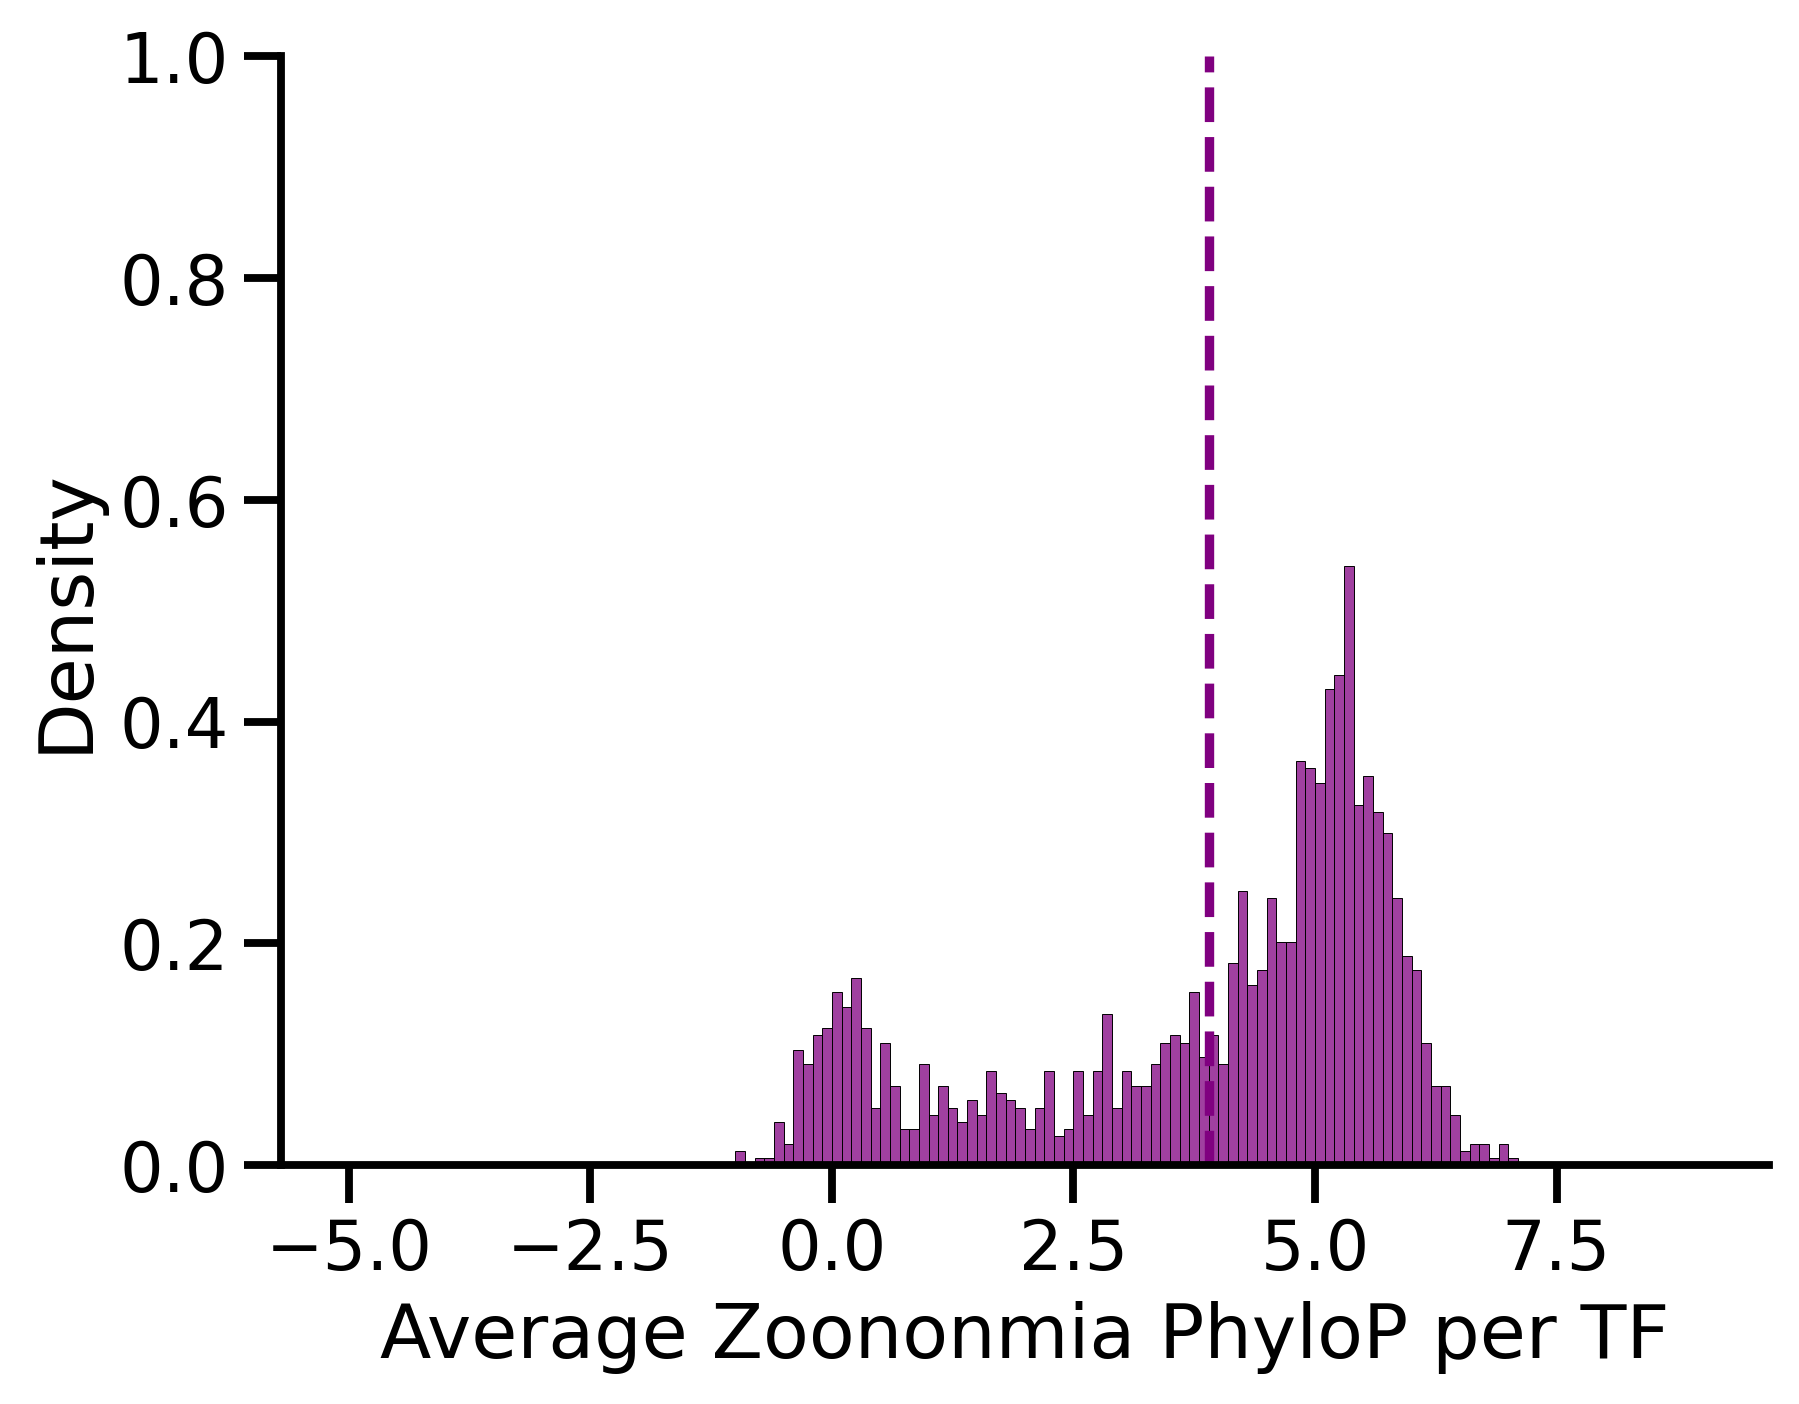

In [51]:
plt.figure(dpi = 300)

bins = np.arange(-5, 9.1, 0.1)
plt.ylim(0, 1)

# df = zoonomia_all_TFs_non_dom
# sns.histplot(df[[7, 8]].groupby(7).mean()[8], label = "Rest of TF", color = "C0", bins = bins, stat = 'density')
# plt.axvline(np.mean(df[[7, 8]].groupby(7).mean()[8]), color = "C0", linestyle = "--")

# df = zoonomia_domains[zoonomia_domains[3] == "AD"]
# sns.histplot(df[[7, 16]].groupby(7).mean()[16], label = "AD", color = "C1", bins = bins, stat = 'density')
# #plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "C1", linestyle = "--")

df = zoonomia_domains[zoonomia_domains[3] == "DBD"]
sns.histplot(df[[7, 16]].groupby(7).mean()[16], label = "DBD", bins = bins, stat = 'density', color = "purple")
plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "purple", linestyle = "--")



#plt.legend()
plt.xlabel("Average Zoononmia PhyloP per TF")
sns.despine()

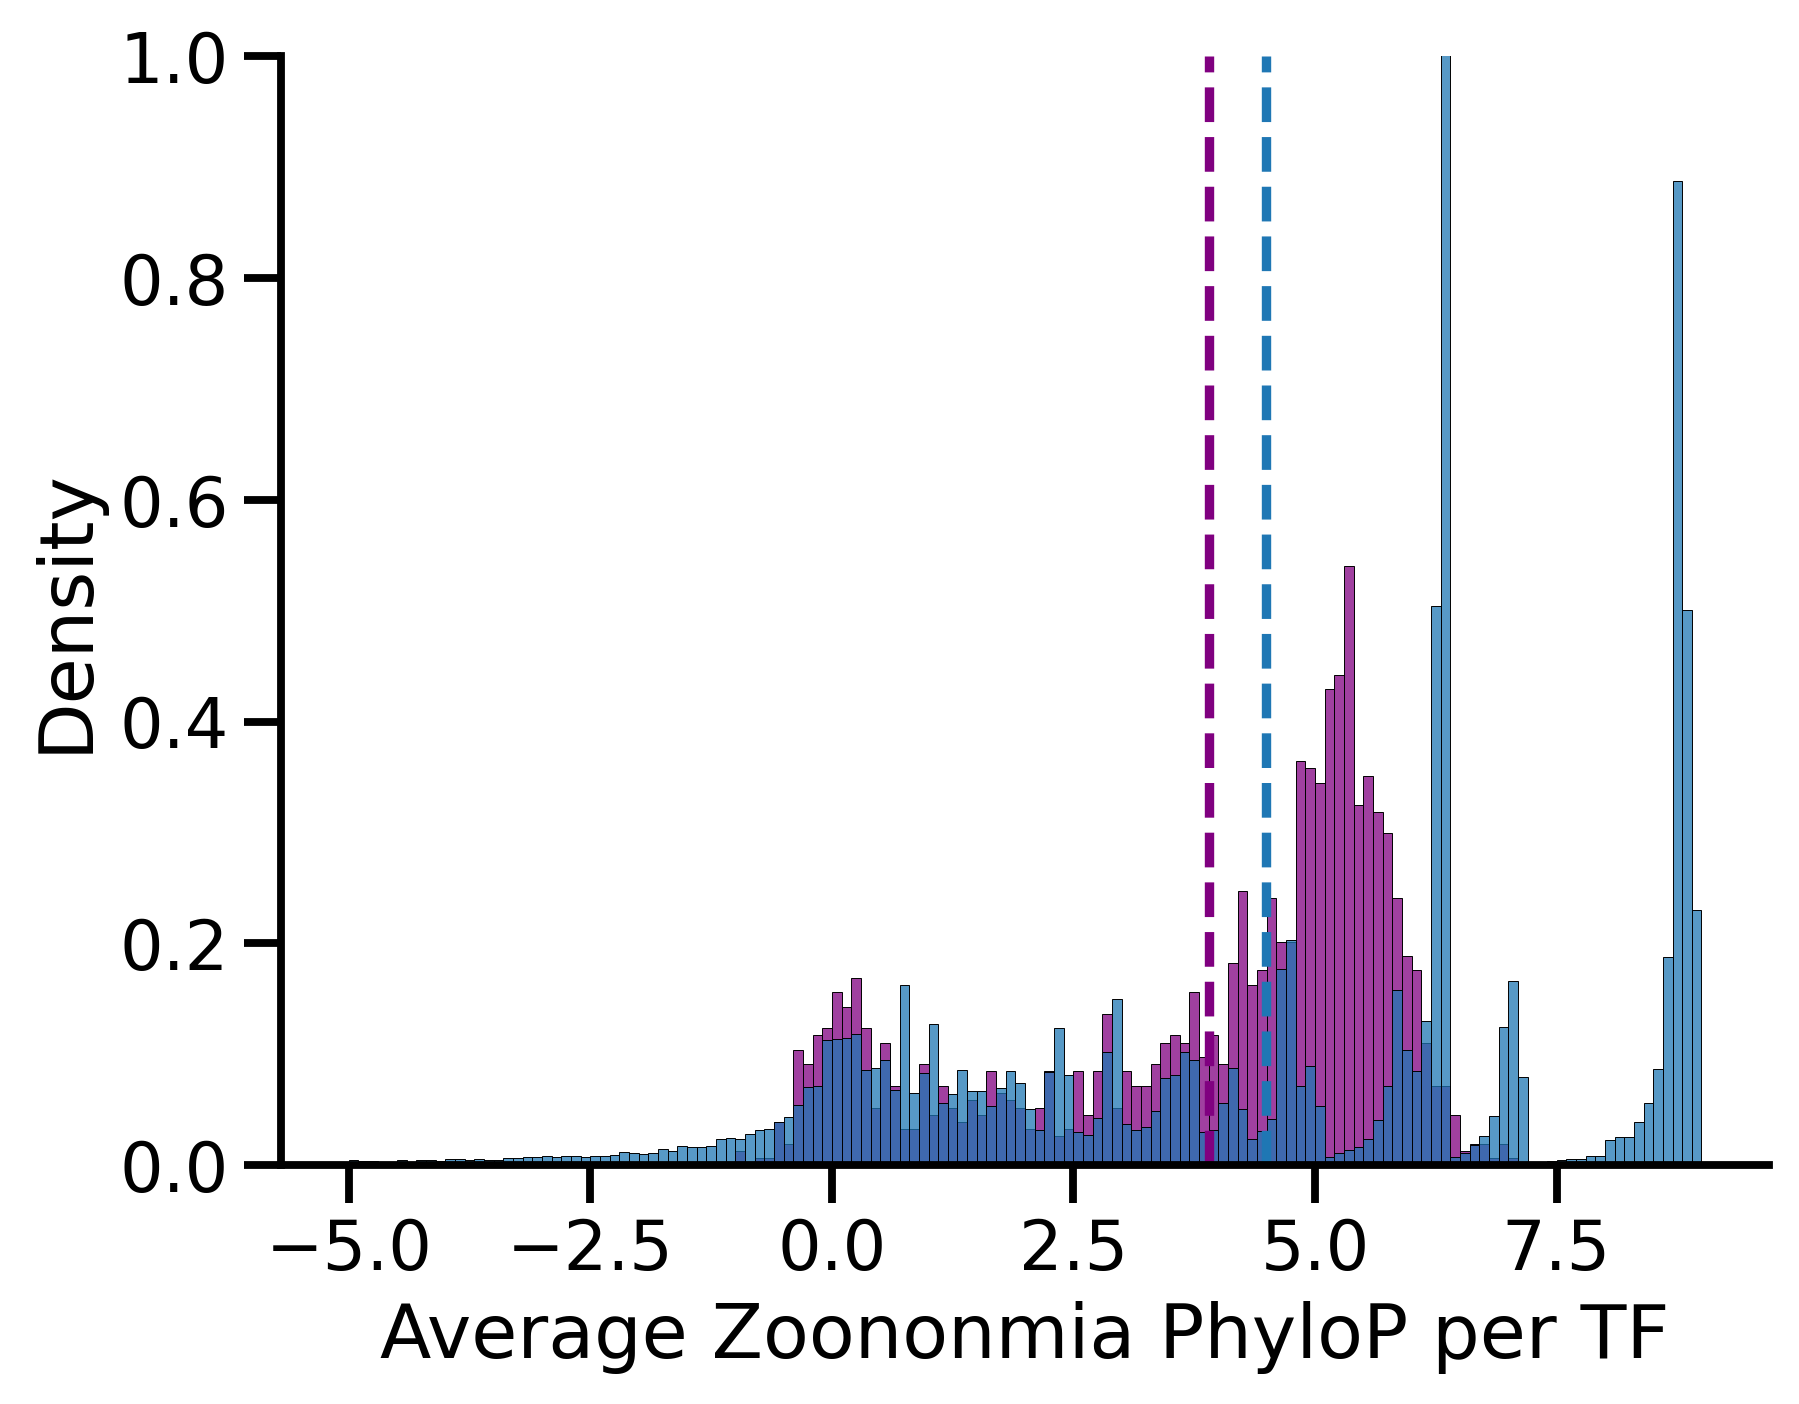

In [52]:
plt.figure(dpi = 300)

bins = np.arange(-5, 9.1, 0.1)
plt.ylim(0, 1)

df = zoonomia_domains[zoonomia_domains[3] == "DBD"]
sns.histplot(df[[7, 16]].groupby(7).mean()[16], label = "DBD", bins = bins, stat = 'density', color = "purple")
plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "purple", linestyle = "--")

df = zoonomia_activator_TFs_non_dom
sns.histplot(df[[7, 8]].groupby(7).mean()[8], label = "Rest of TF", color = "C0", bins = bins, stat = 'density')
plt.axvline(np.mean(df[[7, 8]].groupby(7).mean()[8]), color = "C0", linestyle = "--")

# df = zoonomia_domains[zoonomia_domains[3] == "AD"]
# sns.histplot(df[[7, 16]].groupby(7).mean()[16], label = "AD", color = "C1", bins = bins, stat = 'density')
# plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "C1", linestyle = "--")




#plt.legend()
plt.xlabel("Average Zoononmia PhyloP per TF")
sns.despine()

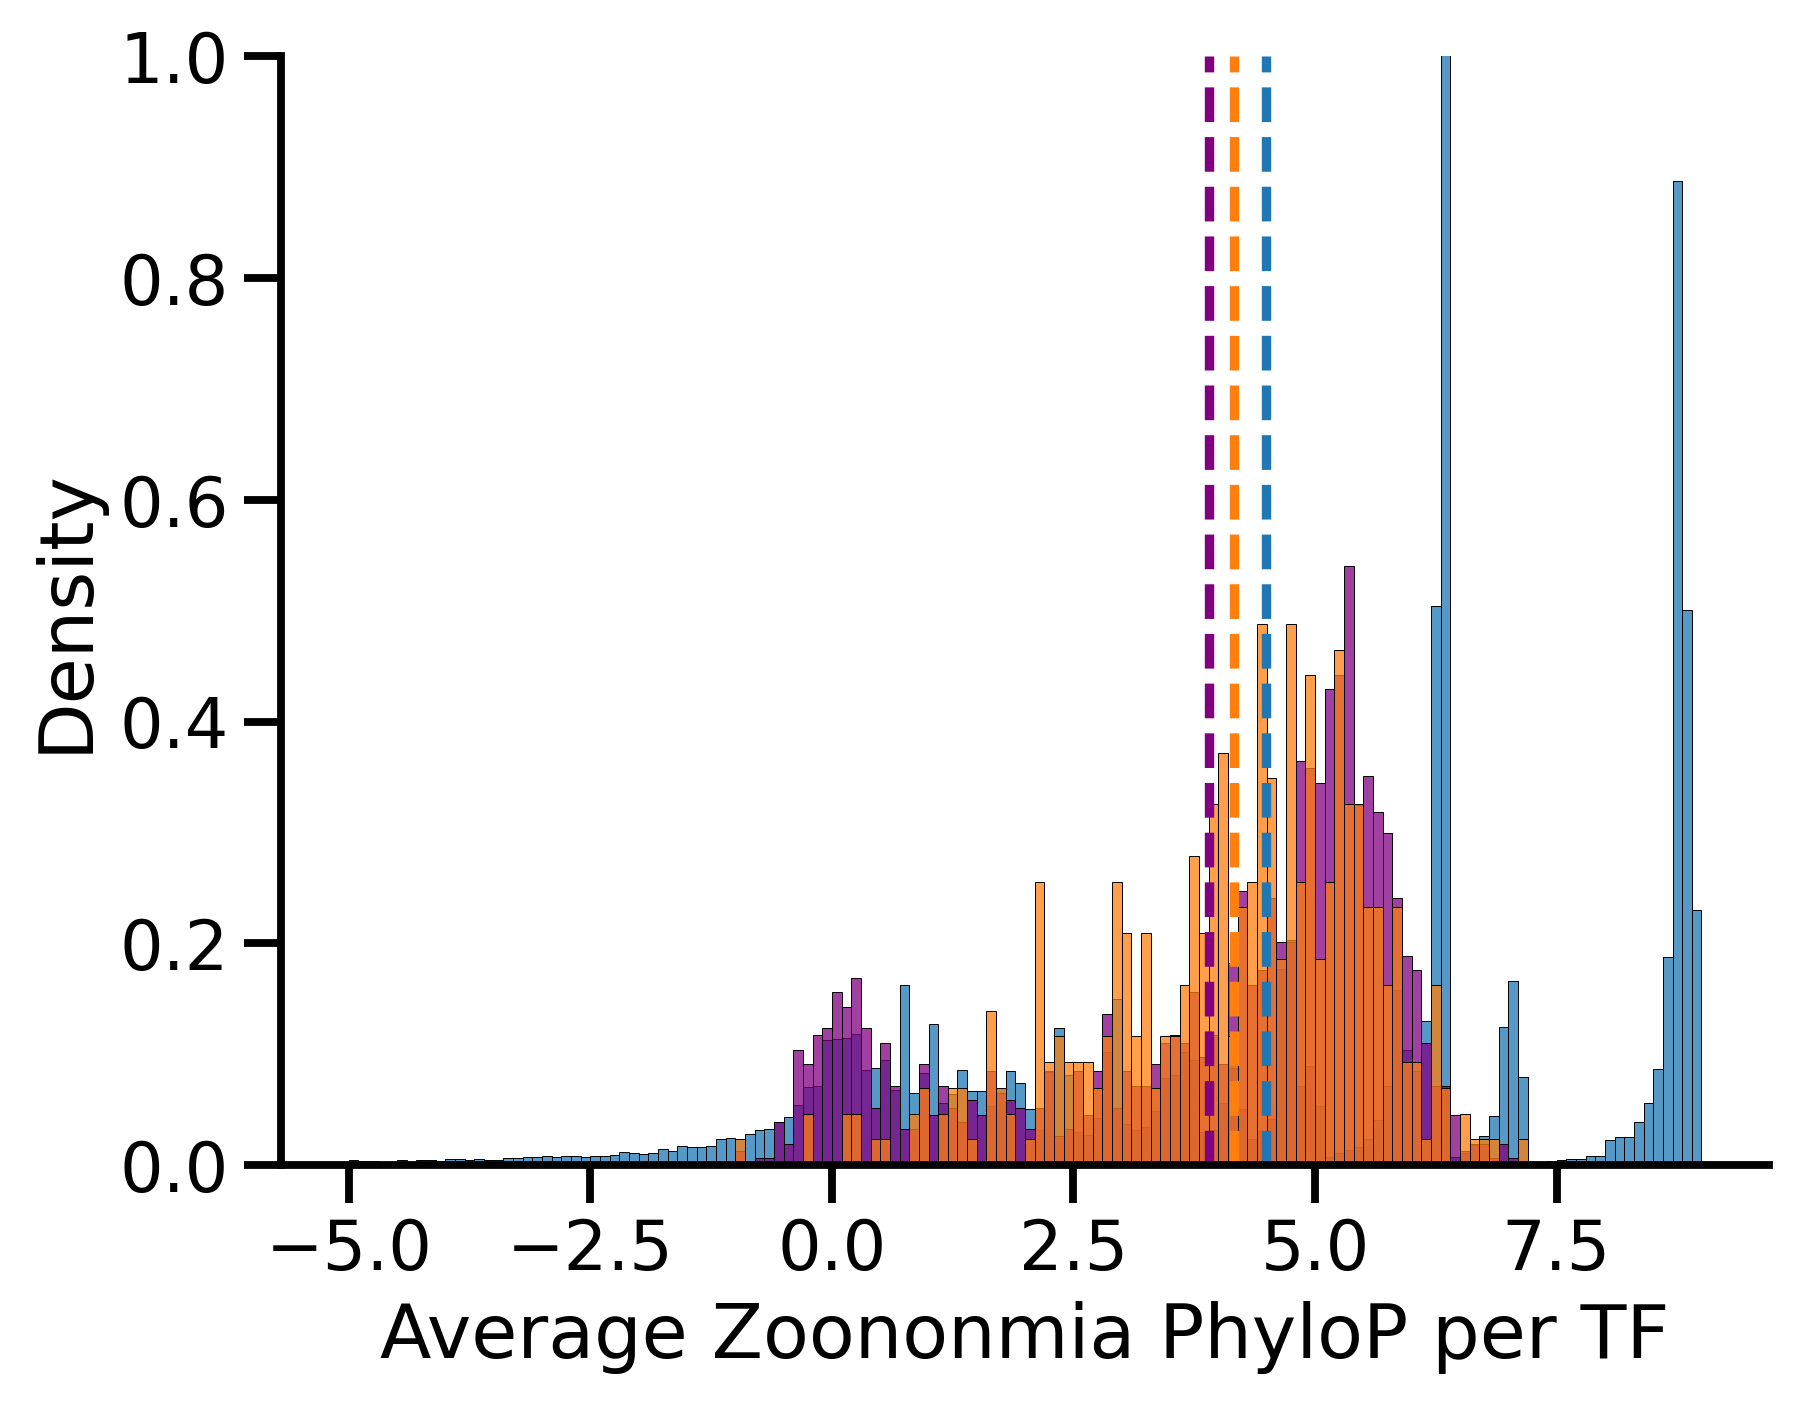

In [53]:
plt.figure(dpi = 300)

bins = np.arange(-5, 9.1, 0.1)
plt.ylim(0, 1)

df = zoonomia_activator_TFs_non_dom
sns.histplot(df[[7, 8]].groupby(7).mean()[8], label = "Rest of TF", color = "C0", bins = bins, stat = 'density')
plt.axvline(np.mean(df[[7, 8]].groupby(7).mean()[8]), color = "C0", linestyle = "--")


df = zoonomia_domains[zoonomia_domains[3] == "DBD"]
sns.histplot(df[[7, 16]].groupby(7).mean()[16], label = "DBD", bins = bins, stat = 'density', color = "purple")
plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "purple", linestyle = "--")

df = zoonomia_domains[zoonomia_domains[3] == "AD"]
sns.histplot(df[[7, 16]].groupby(7).mean()[16], label = "AD", color = "C1", bins = bins, stat = 'density')
plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "C1", linestyle = "--")


#plt.legend()
plt.xlabel("Average Zoononmia PhyloP per TF")
sns.despine()

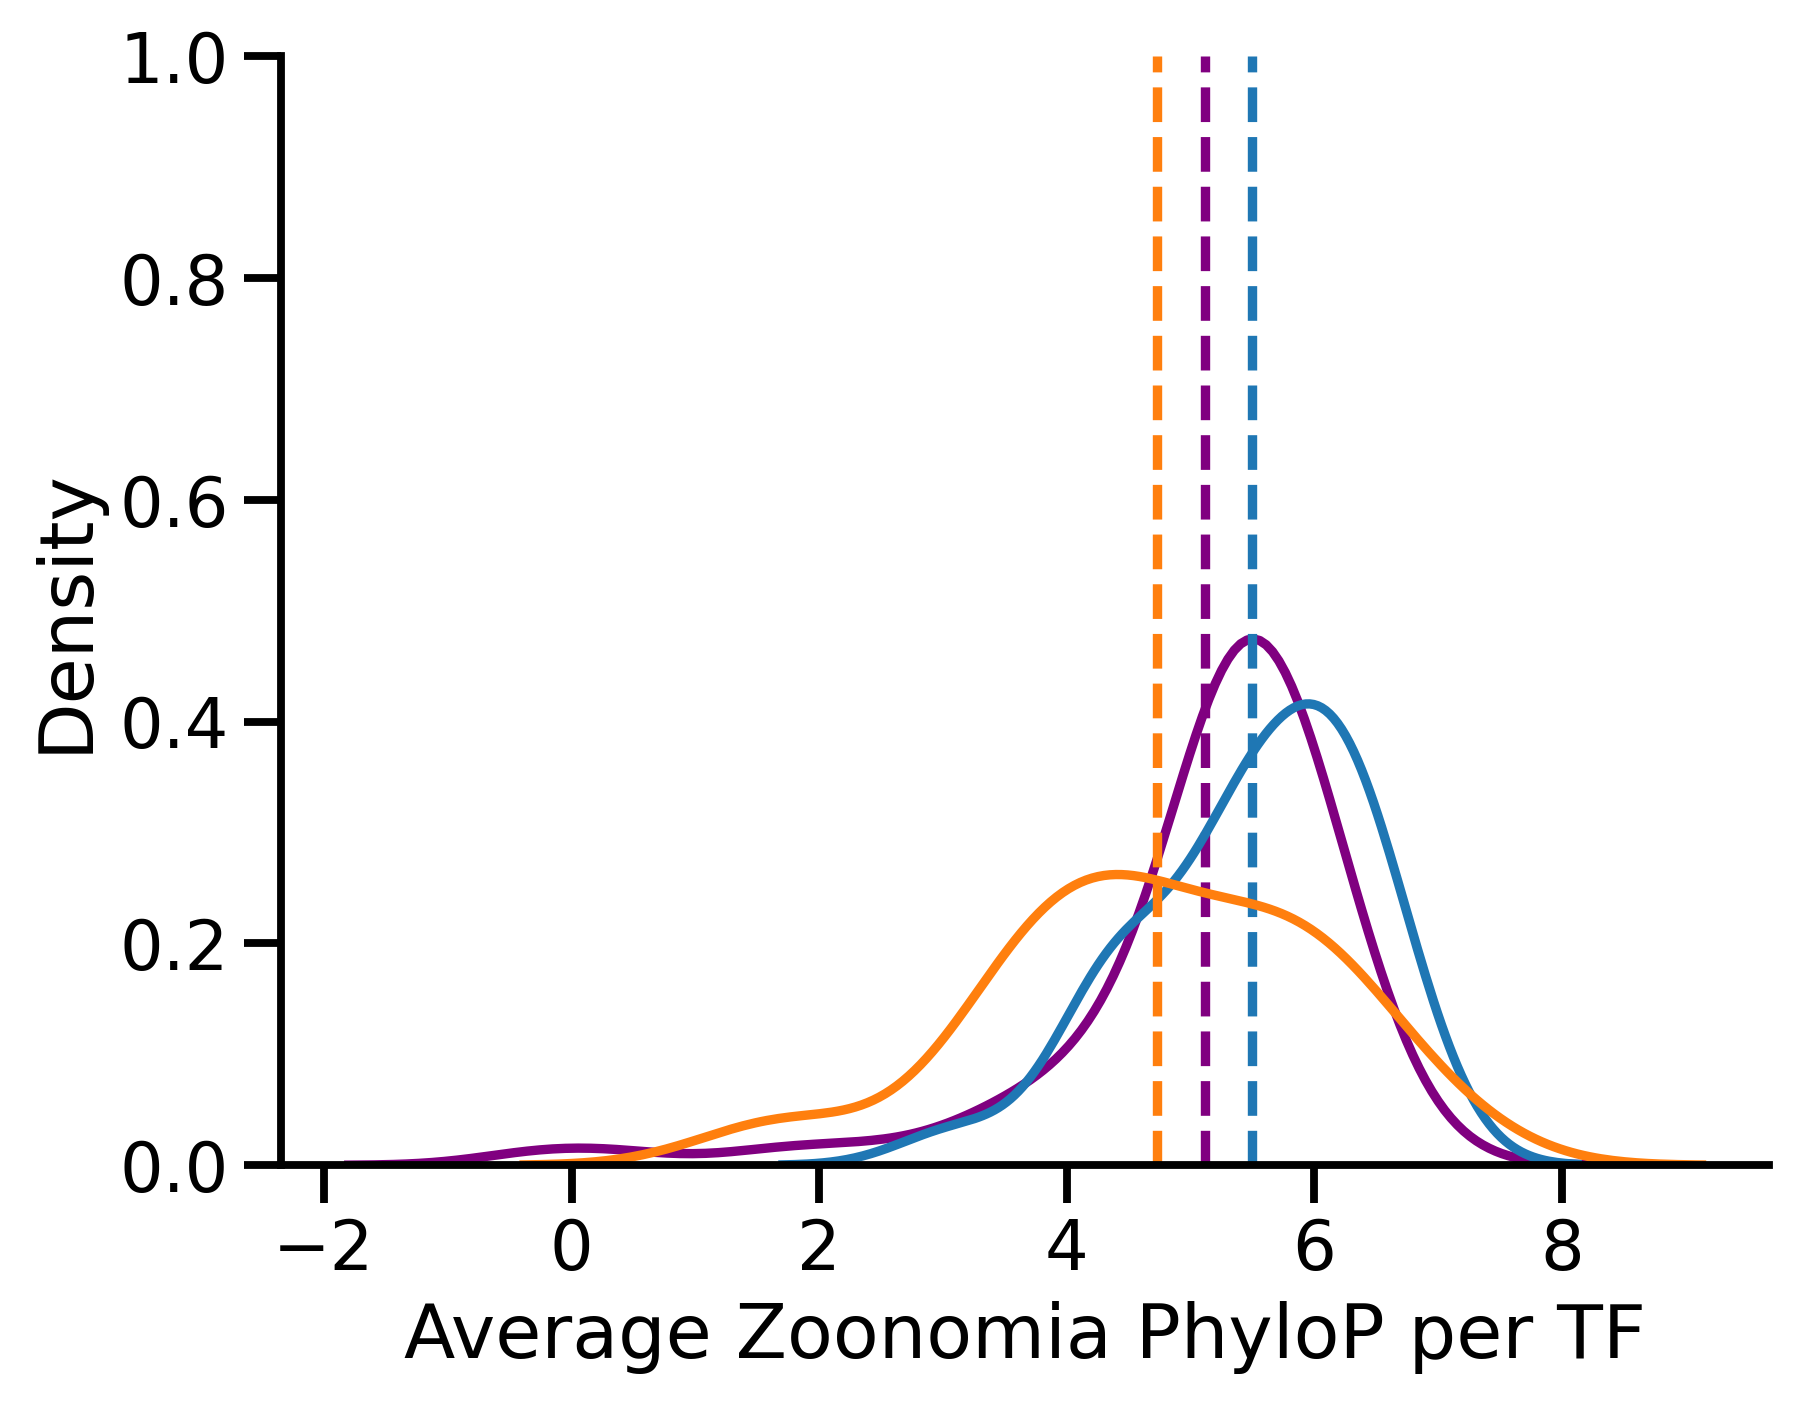

In [55]:
plt.figure(dpi = 300)
plt.ylim(0, 1)

#bins = np.arange(-1.7, 7.5, 0.25)

df = zoonomia_domains[zoonomia_domains[3] == "DBD"]
df = df[df[7].isin(SFARI_TFs["transcript"])]
sns.kdeplot(df[[7, 16]].groupby(7).mean()[16], label = "DBD", color = "purple")
plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "purple", linestyle = "--")

df = zoonomia_activator_TFs_non_dom
df = df[df[3].isin(SFARI_TFs["transcript"])]
sns.kdeplot(df[[3, 8]].groupby(3).mean()[8], label = "Rest of TF", color = "C0")
plt.axvline(np.mean(df[[3, 8]].groupby(3).mean()[8]), color = "C0", linestyle = "--")

df = zoonomia_domains[zoonomia_domains[3] == "AD"]
df = df[df[7].isin(SFARI_TFs["transcript"])]
sns.kdeplot(df[[7, 16]].groupby(7).mean()[16], label = "AD", color = "C1", )
plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "C1", linestyle = "--")


#plt.legend()
plt.xlabel("Average Zoonomia PhyloP per TF")
sns.despine()

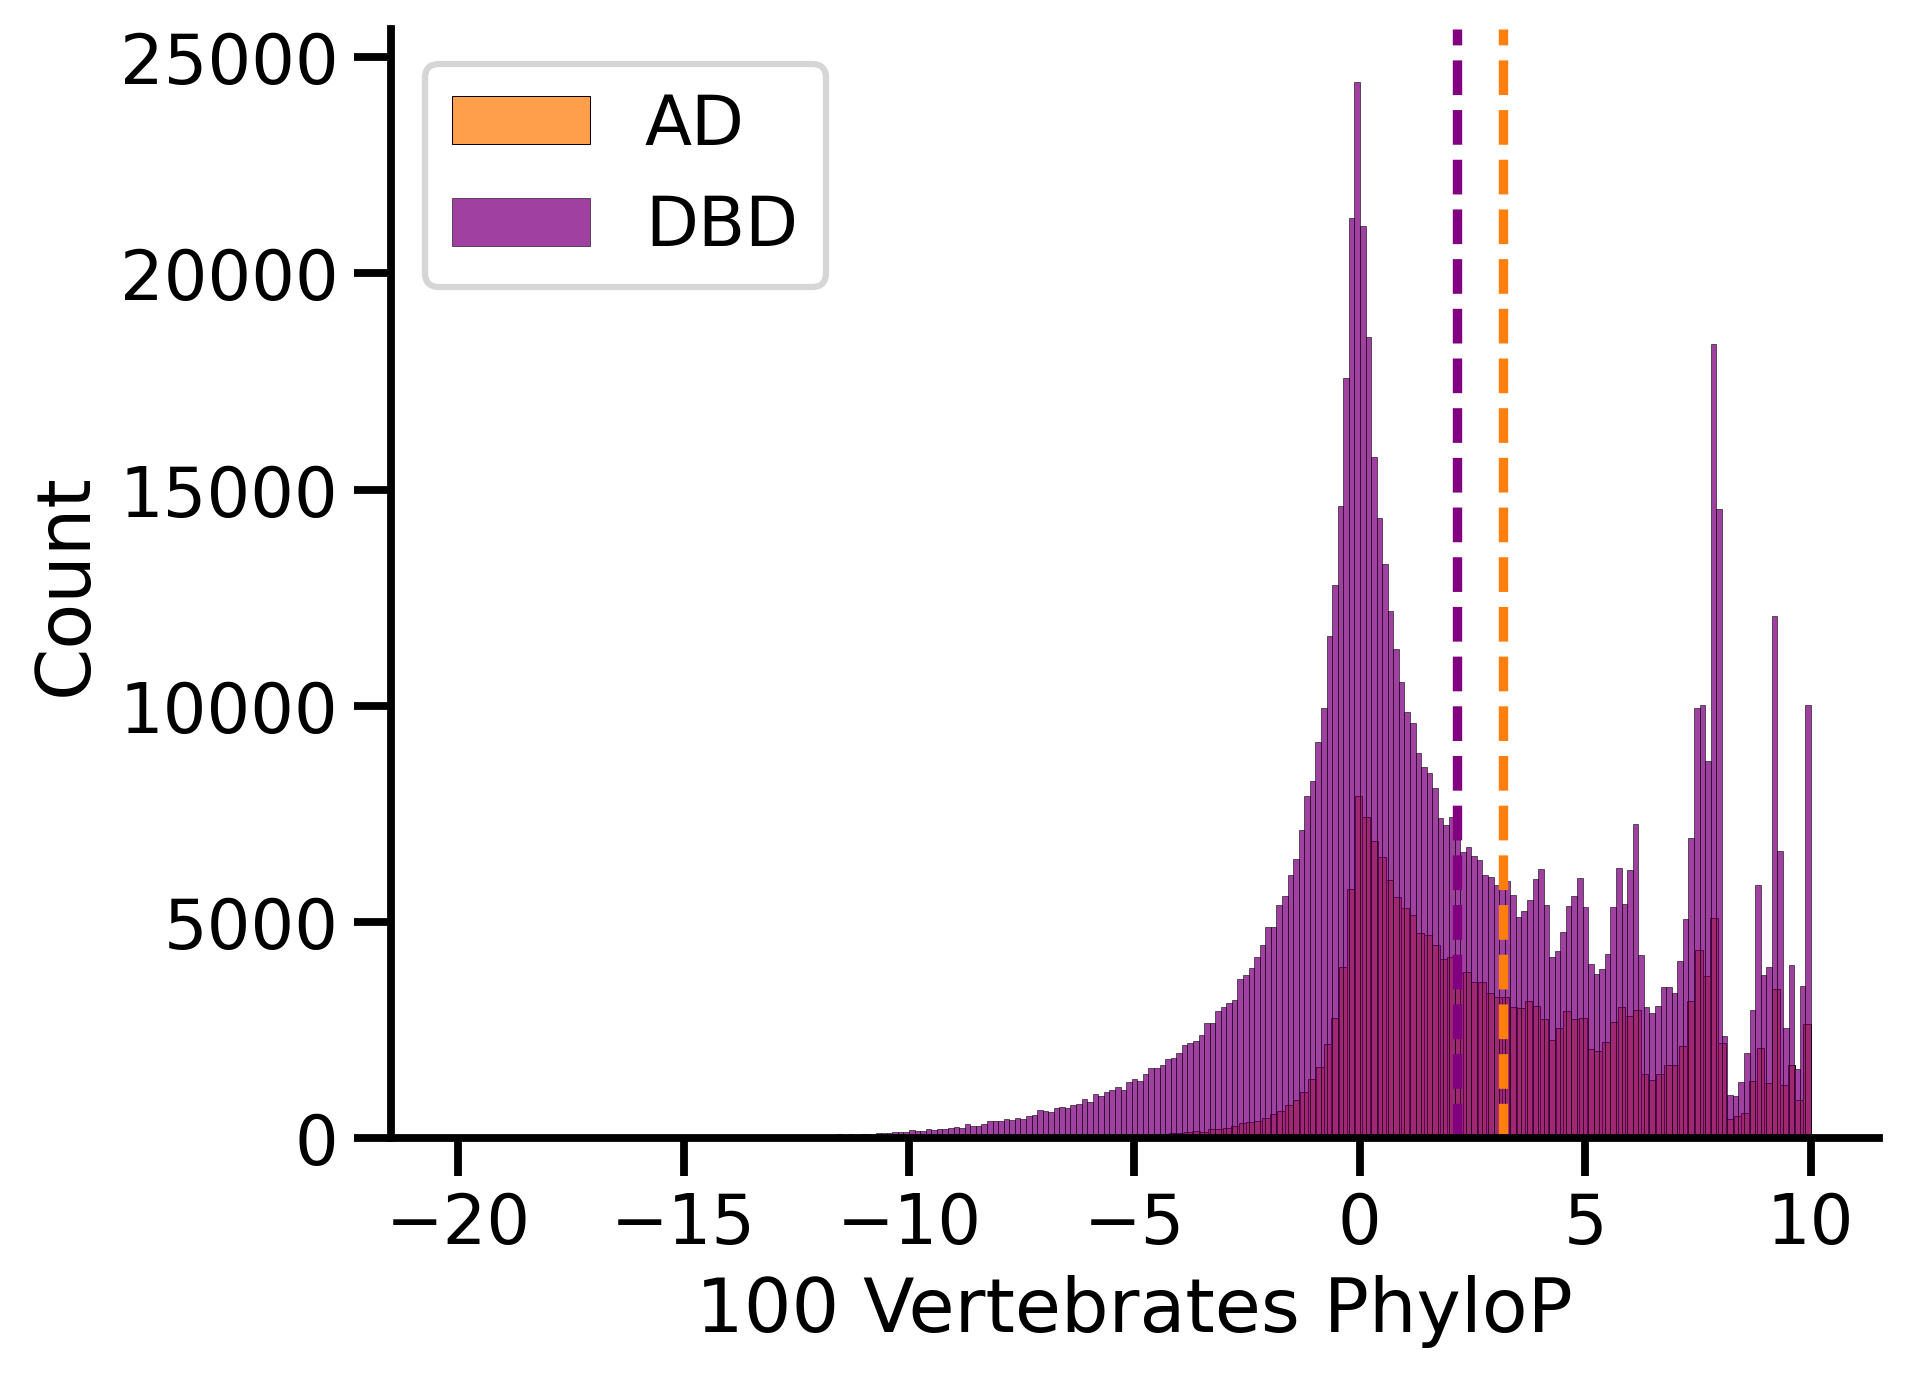

In [56]:
plt.figure(dpi = 300)
sns.histplot(verteb_domains[verteb_domains[3] == "AD"][16], label = "AD", color = "C1")
plt.axvline(np.mean(verteb_domains[verteb_domains[3] == "AD"][16]), color = "C1", linestyle = "--")

sns.histplot(verteb_domains[verteb_domains[3] == "DBD"][16], label = "DBD", color = "purple")
plt.axvline(np.mean(verteb_domains[verteb_domains[3] == "DBD"][16]), color = "purple", linestyle = "--")

plt.legend()
plt.xlabel("100 Vertebrates PhyloP")
sns.despine()

In [57]:
verteb_activator_TFs_non_dom

,0,1,2,3,4,5,6,7,8,key
227,2,70900849,70900850,ENST00000234392,1,2,70900849,70900850,3.954260,chr2_70900849
228,2,70900850,70900851,ENST00000234392,1,2,70900850,70900851,2.526170,chr2_70900850
229,2,70900851,70900852,ENST00000234392,1,2,70900851,70900852,3.954260,chr2_70900851
230,2,70900852,70900853,ENST00000234392,1,2,70900852,70900853,3.954260,chr2_70900852
231,2,70900853,70900854,ENST00000234392,1,2,70900853,70900854,3.240210,chr2_70900853
...,...,...,...,...,...,...,...,...,...,...
934,14,64260746,64260747,ENST00000341099,-1,14,64260746,64260747,0.063181,chr14_64260746
935,14,64260747,64260748,ENST00000341099,-1,14,64260747,64260748,6.531720,chr14_64260747
936,14,64268795,64268796,ENST00000341099,-1,14,64268795,64268796,0.162835,chr14_64268795
937,14,64268796,64268797,ENST00000341099,-1,14,64268796,64268797,4.810590,chr14_64268796


In [58]:
# verteb_all_TFs_non_dom = verteb_all_TFs[~verteb_all_TFs["key"].isin(verteb_domains["key"])]
# verteb_all_TFs_non_dom

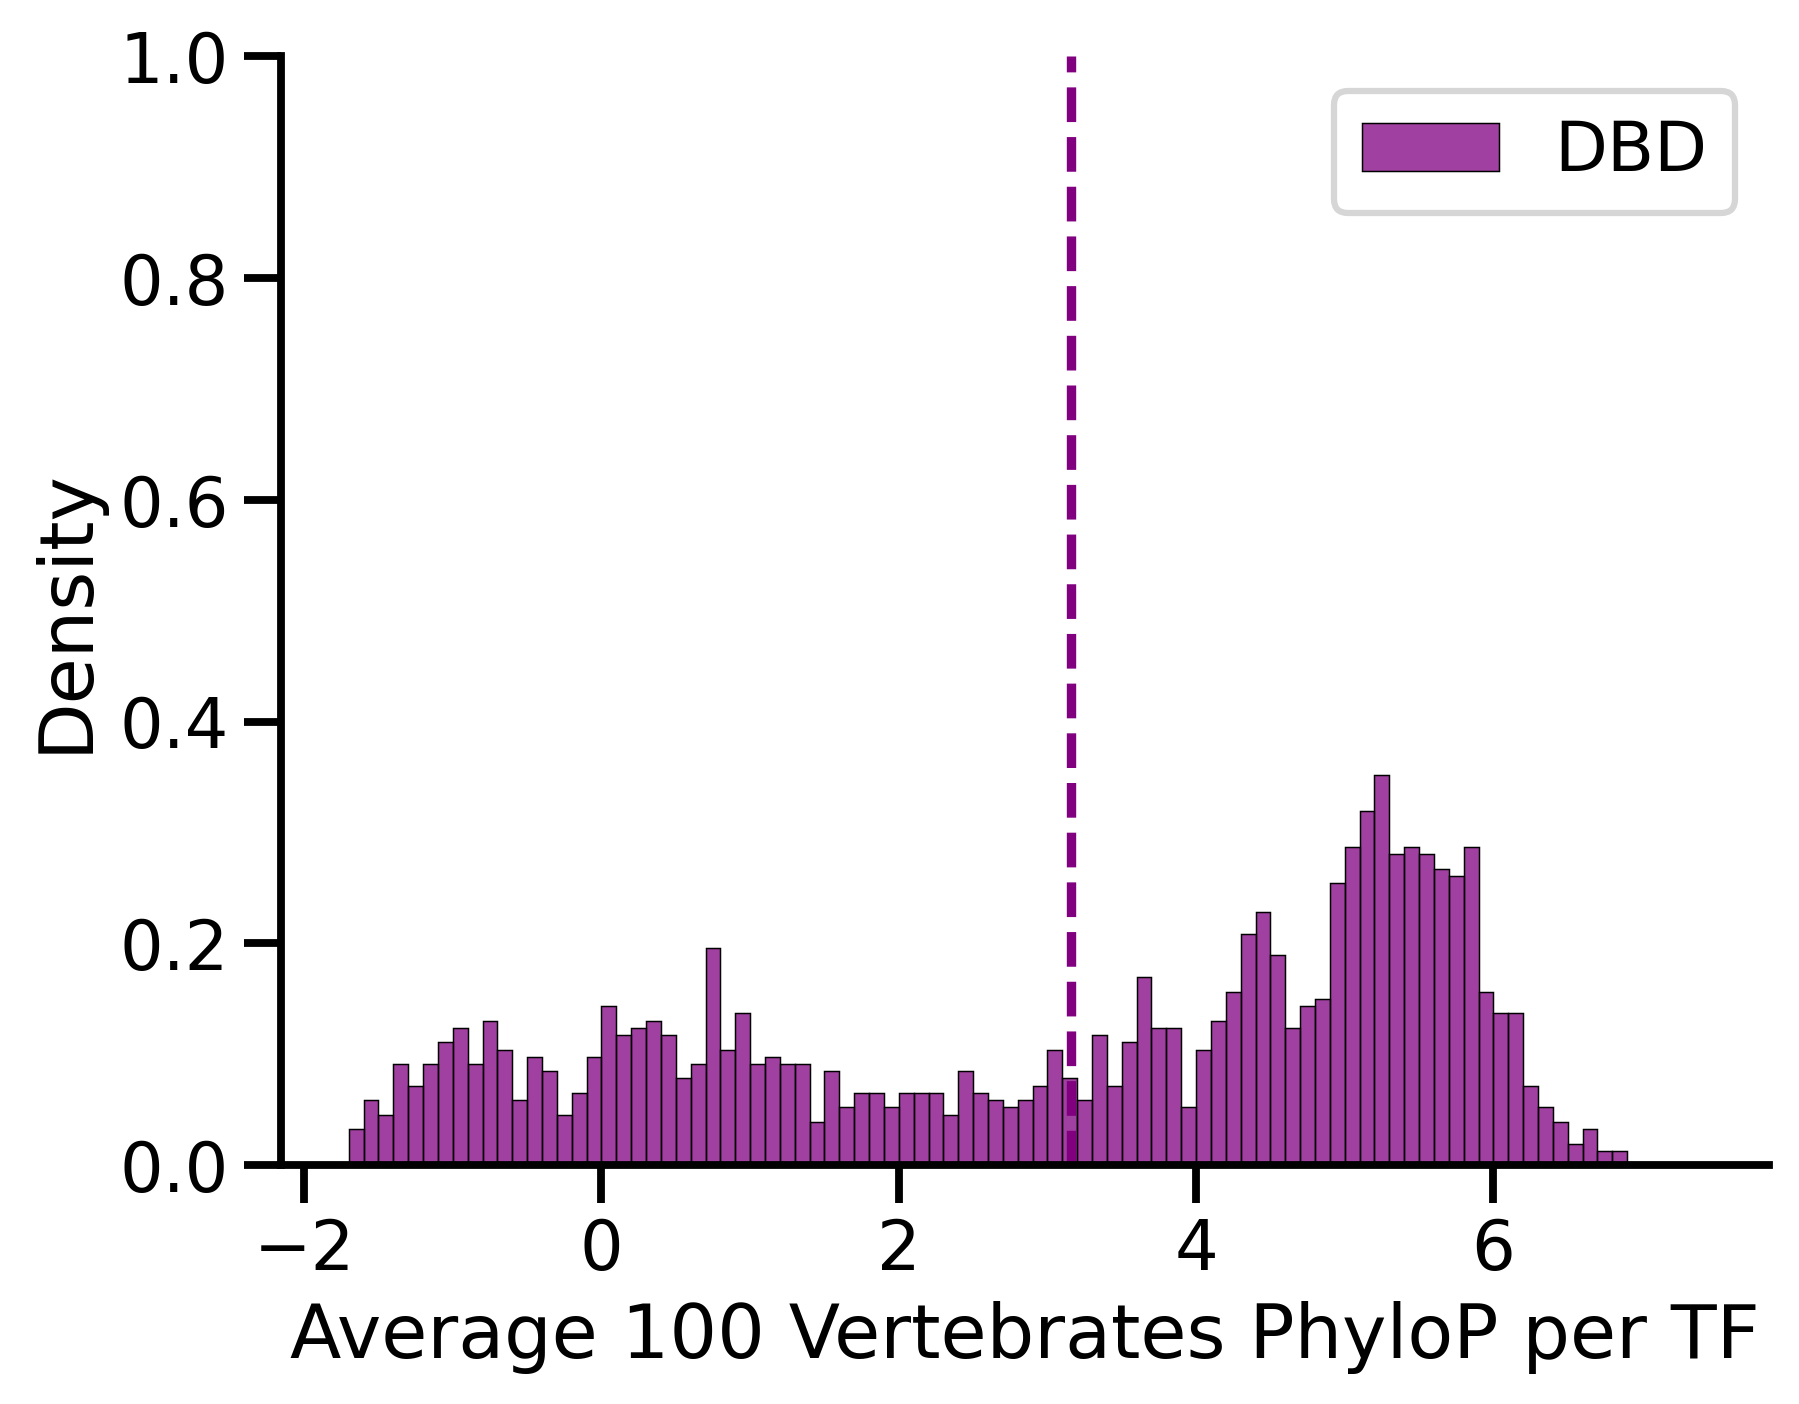

In [59]:
plt.figure(dpi = 300)

plt.ylim(0, 1)
bins = np.arange(-1.7, 7.5, 0.1)

# df = verteb_all_TFs_non_dom
# sns.histplot(df[[3, 8]].groupby(3).mean()[8], label = "Rest of TF", color = "C0", bins = bins, stat = 'density')
# plt.axvline(np.mean(df[[3, 8]].groupby(3).mean()[8]), color = "C0", linestyle = "--")

# df = verteb_domains[verteb_domains[3] == "AD"]
# sns.histplot(df[[7, 16]].groupby(7).mean()[16], label = "AD", color = "C1", bins = bins, stat = 'density')
# #plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "C1", linestyle = "--")

df = verteb_domains[verteb_domains[3] == "DBD"]
sns.histplot(df[[7, 16]].groupby(7).mean()[16], label = "DBD", bins = bins, stat = 'density', color = "purple")
plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "purple", linestyle = "--")

plt.legend()
plt.xlabel("Average 100 Vertebrates PhyloP per TF")
sns.despine()

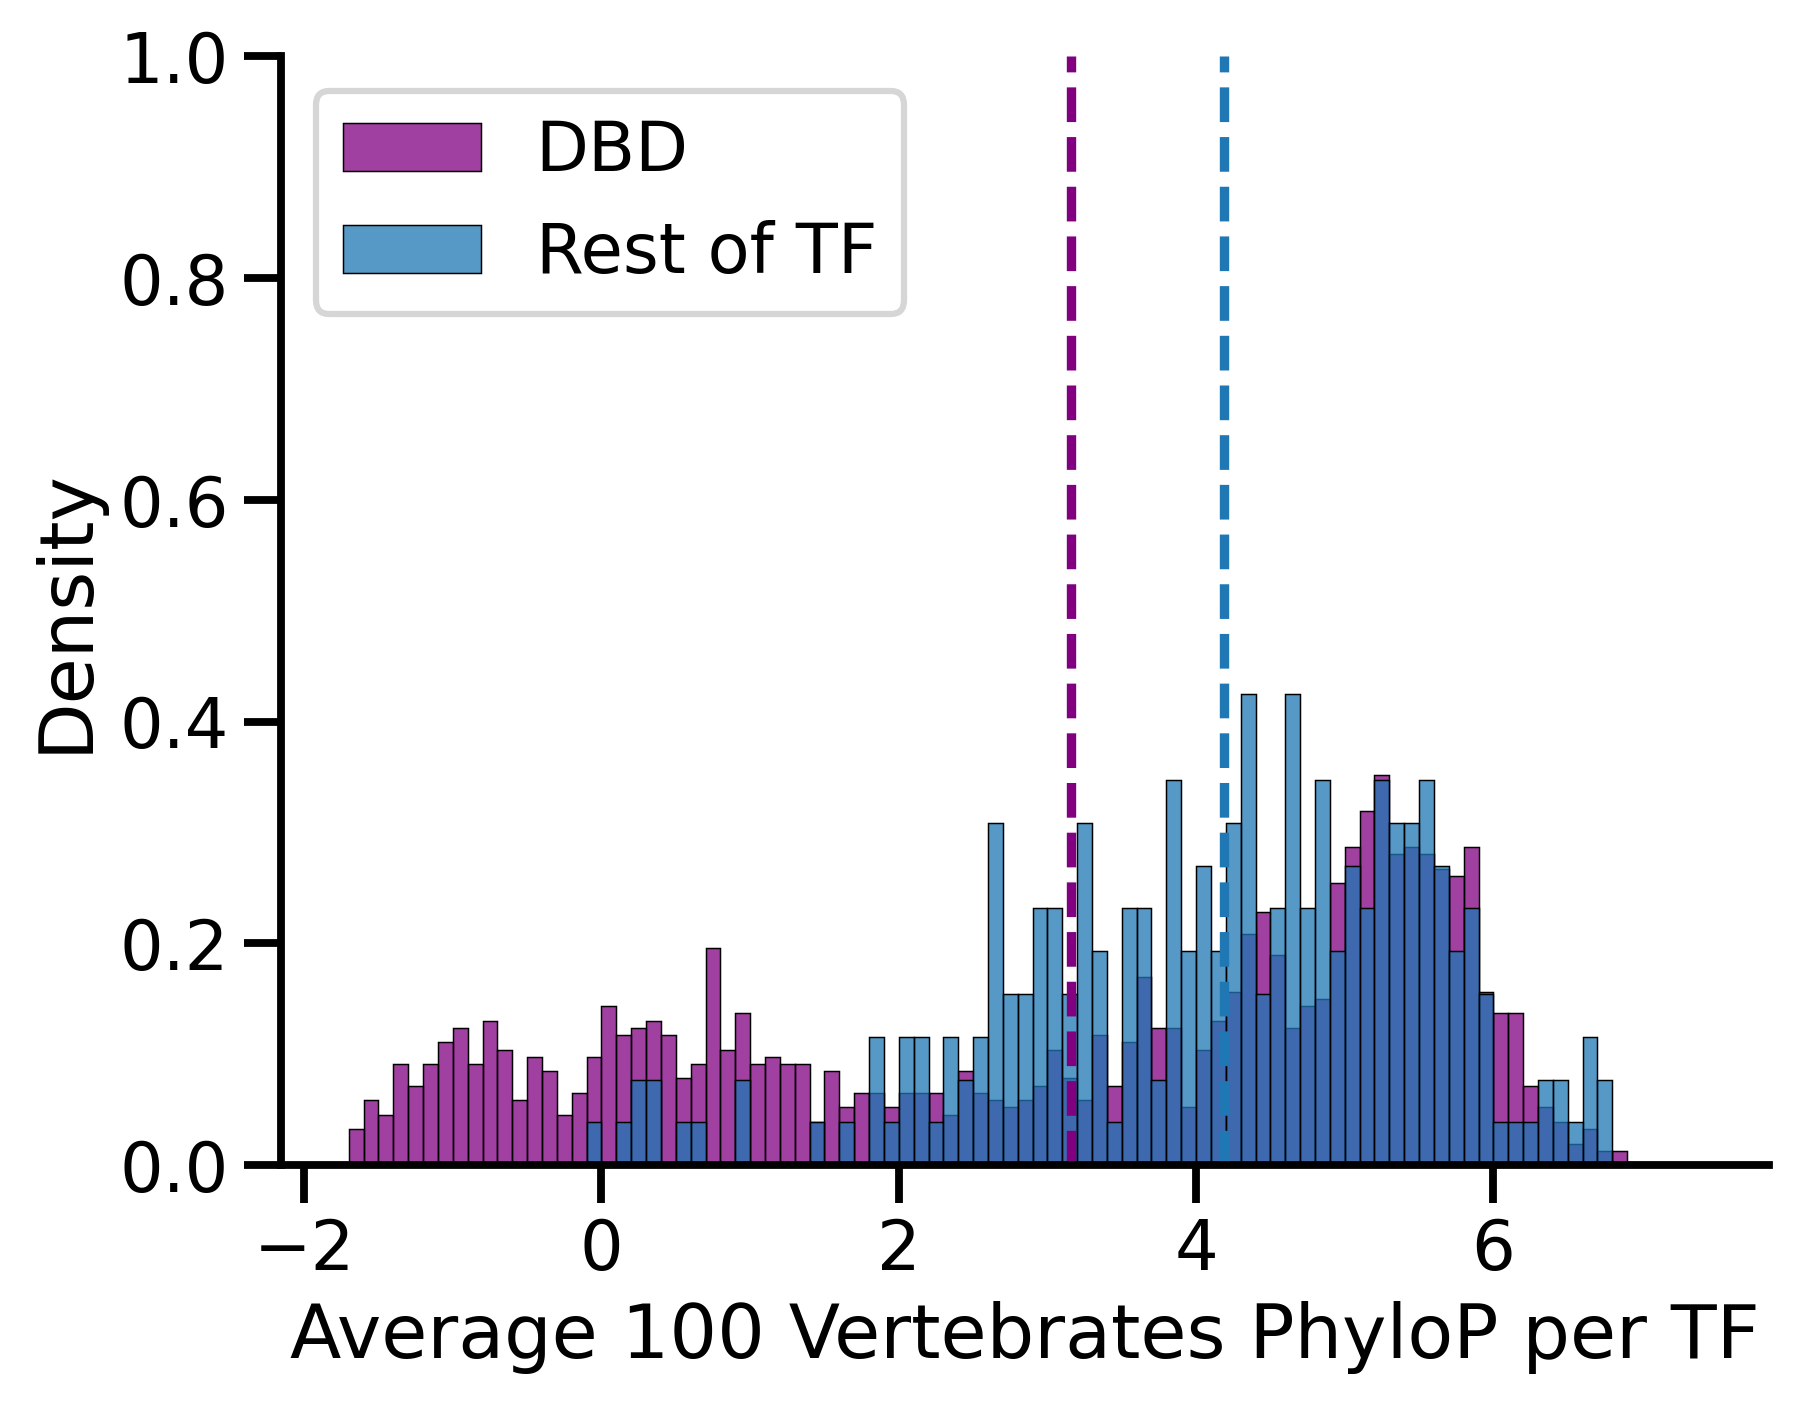

In [60]:
plt.figure(dpi = 300)
plt.ylim(0, 1)

bins = np.arange(-1.7, 7.5, 0.1)

df = verteb_domains[verteb_domains[3] == "DBD"]
sns.histplot(df[[7, 16]].groupby(7).mean()[16], label = "DBD", bins = bins, stat = 'density', color = "purple")
plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "purple", linestyle = "--")

df = verteb_activator_TFs_non_dom
sns.histplot(df[[3, 8]].groupby(3).mean()[8], label = "Rest of TF", color = "C0", bins = bins, stat = 'density')
plt.axvline(np.mean(df[[3, 8]].groupby(3).mean()[8]), color = "C0", linestyle = "--")

# df = verteb_domains[verteb_domains[3] == "AD"]
# sns.histplot(df[[7, 16]].groupby(7).mean()[16], label = "AD", color = "C1", bins = bins, stat = 'density')
# plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "C1", linestyle = "--")


plt.legend()
plt.xlabel("Average 100 Vertebrates PhyloP per TF")
sns.despine()

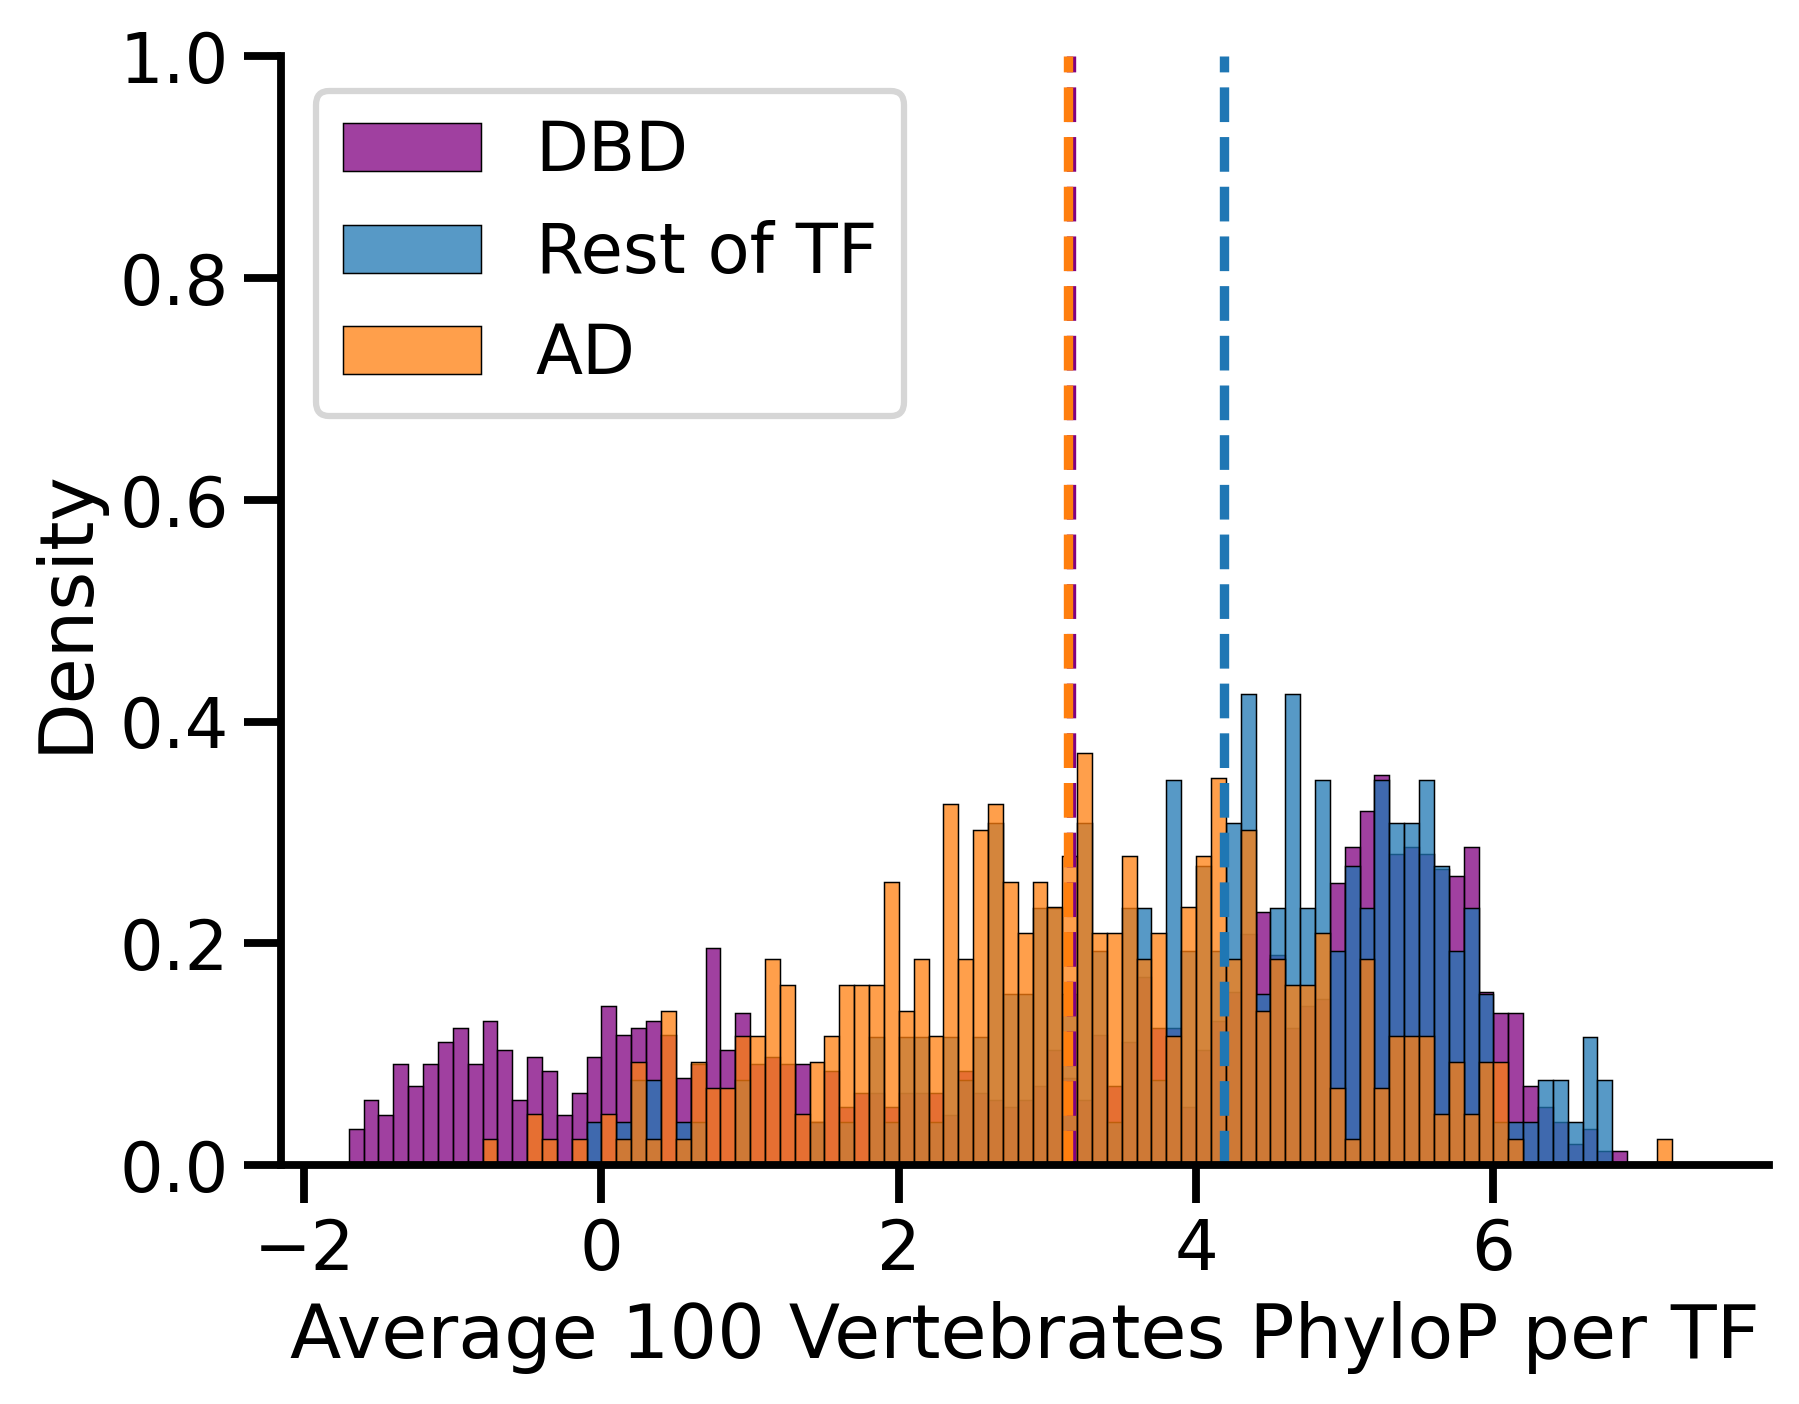

In [61]:
plt.figure(dpi = 300)
plt.ylim(0, 1)

bins = np.arange(-1.7, 7.5, 0.1)

df = verteb_domains[verteb_domains[3] == "DBD"]
sns.histplot(df[[7, 16]].groupby(7).mean()[16], label = "DBD", bins = bins, stat = 'density', color = "purple")
plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "purple", linestyle = "--")

df = verteb_activator_TFs_non_dom
sns.histplot(df[[3, 8]].groupby(3).mean()[8], label = "Rest of TF", color = "C0", bins = bins, stat = 'density')
plt.axvline(np.mean(df[[3, 8]].groupby(3).mean()[8]), color = "C0", linestyle = "--")

df = verteb_domains[verteb_domains[3] == "AD"]
sns.histplot(df[[7, 16]].groupby(7).mean()[16], label = "AD", color = "C1", bins = bins, stat = 'density')
plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "C1", linestyle = "--")


plt.legend()
plt.xlabel("Average 100 Vertebrates PhyloP per TF")
sns.despine()

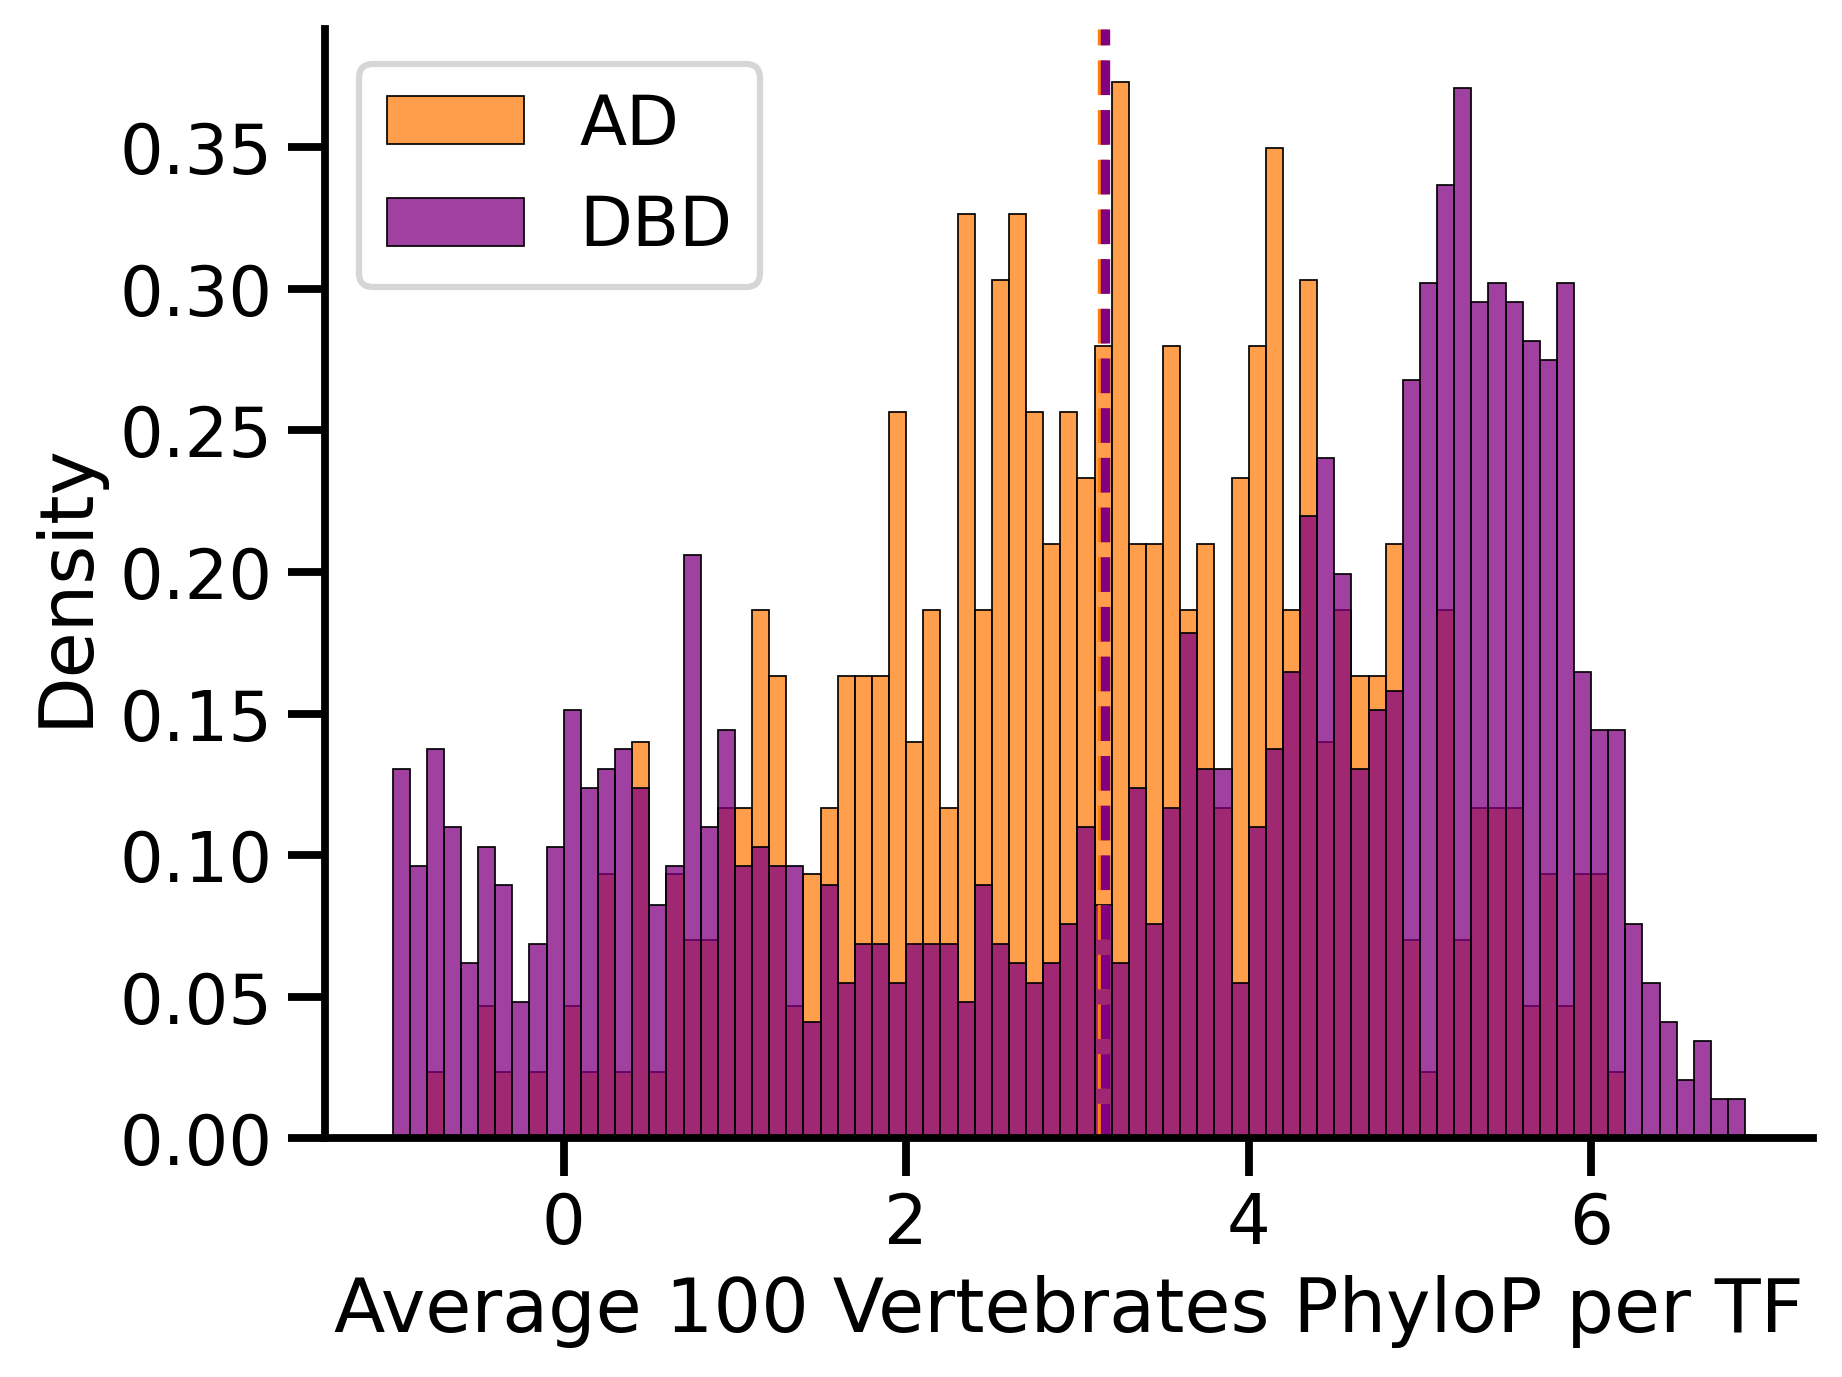

In [62]:
plt.figure(dpi = 300)

bins = np.arange(-1, 7, 0.1)

df = verteb_domains[verteb_domains[3] == "AD"]
sns.histplot(df[[7, 16]].groupby(7).mean()[16], label = "AD", color = "C1", bins = bins, stat = 'density')
plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "C1", linestyle = "--")

df = verteb_domains[verteb_domains[3] == "DBD"]
sns.histplot(df[[7, 16]].groupby(7).mean()[16], label = "DBD", bins = bins, stat = 'density', color = "purple")
plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "purple", linestyle = "--")

plt.legend()
plt.xlabel("Average 100 Vertebrates PhyloP per TF")
sns.despine()

NameError: name 'verteb_all_TFs_non_dom' is not defined

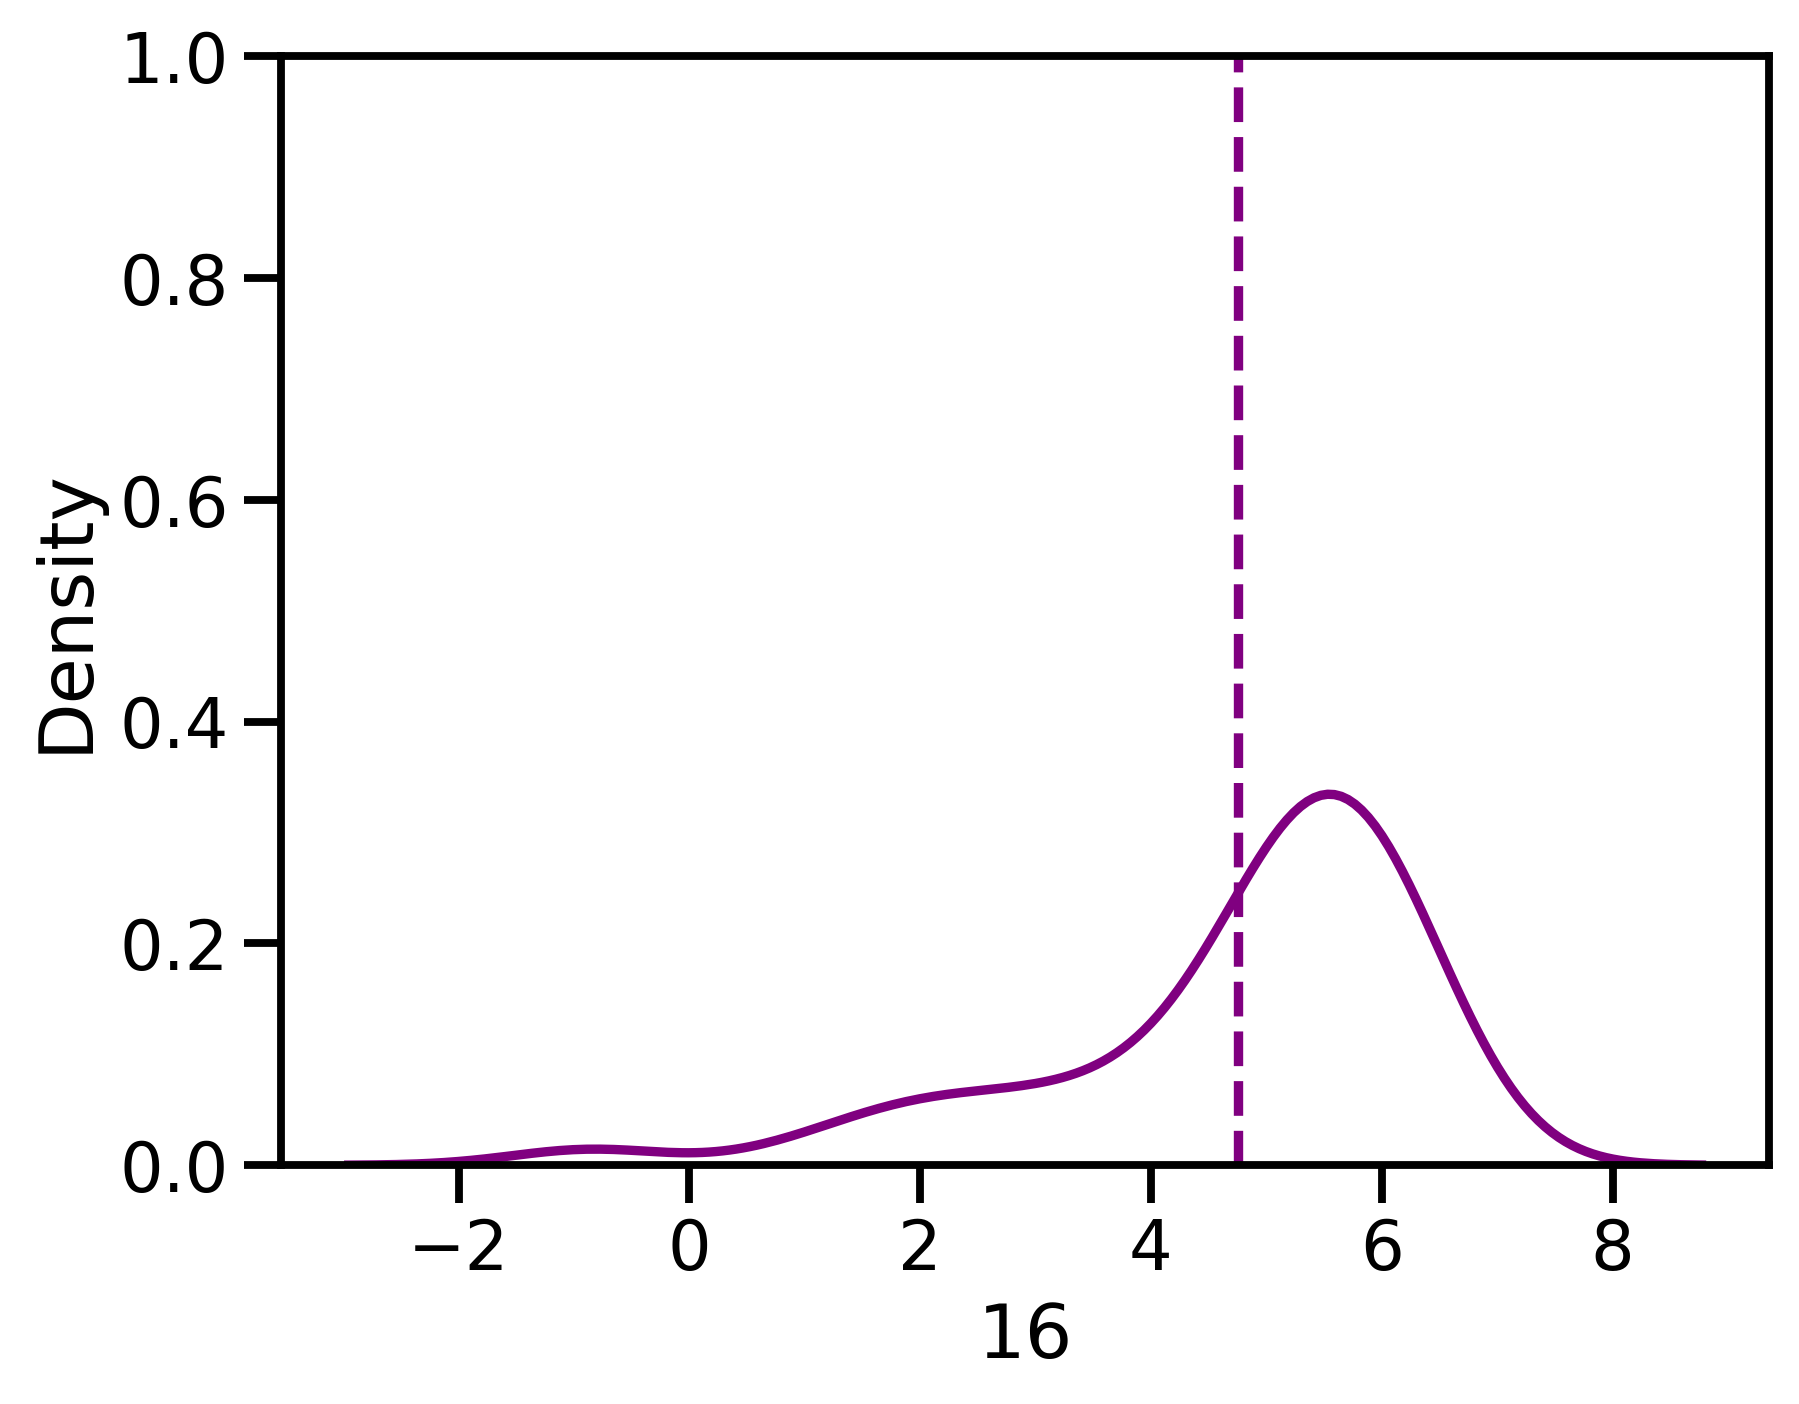

In [63]:
plt.figure(dpi = 300)
plt.ylim(0, 1)

#bins = np.arange(-1.7, 7.5, 0.25)

df = verteb_domains[verteb_domains[3] == "DBD"]
df = df[df[7].isin(SFARI_TFs["transcript"])]
sns.kdeplot(df[[7, 16]].groupby(7).mean()[16], label = "DBD", color = "purple")
plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "purple", linestyle = "--")

df = verteb_all_TFs_non_dom
df = df[df[3].isin(SFARI_TFs["transcript"])]
sns.kdeplot(df[[3, 8]].groupby(3).mean()[8], label = "Rest of TF", color = "C0")
plt.axvline(np.mean(df[[3, 8]].groupby(3).mean()[8]), color = "C0", linestyle = "--")

df = verteb_domains[verteb_domains[3] == "AD"]
df = df[df[7].isin(SFARI_TFs["transcript"])]
sns.kdeplot(df[[7, 16]].groupby(7).mean()[16], label = "AD", color = "C1", )
plt.axvline(np.mean(df[[7, 16]].groupby(7).mean()[16]), color = "C1", linestyle = "--")


plt.legend()
plt.xlabel("Average 100 Vertebrates PhyloP per TF")
sns.despine()

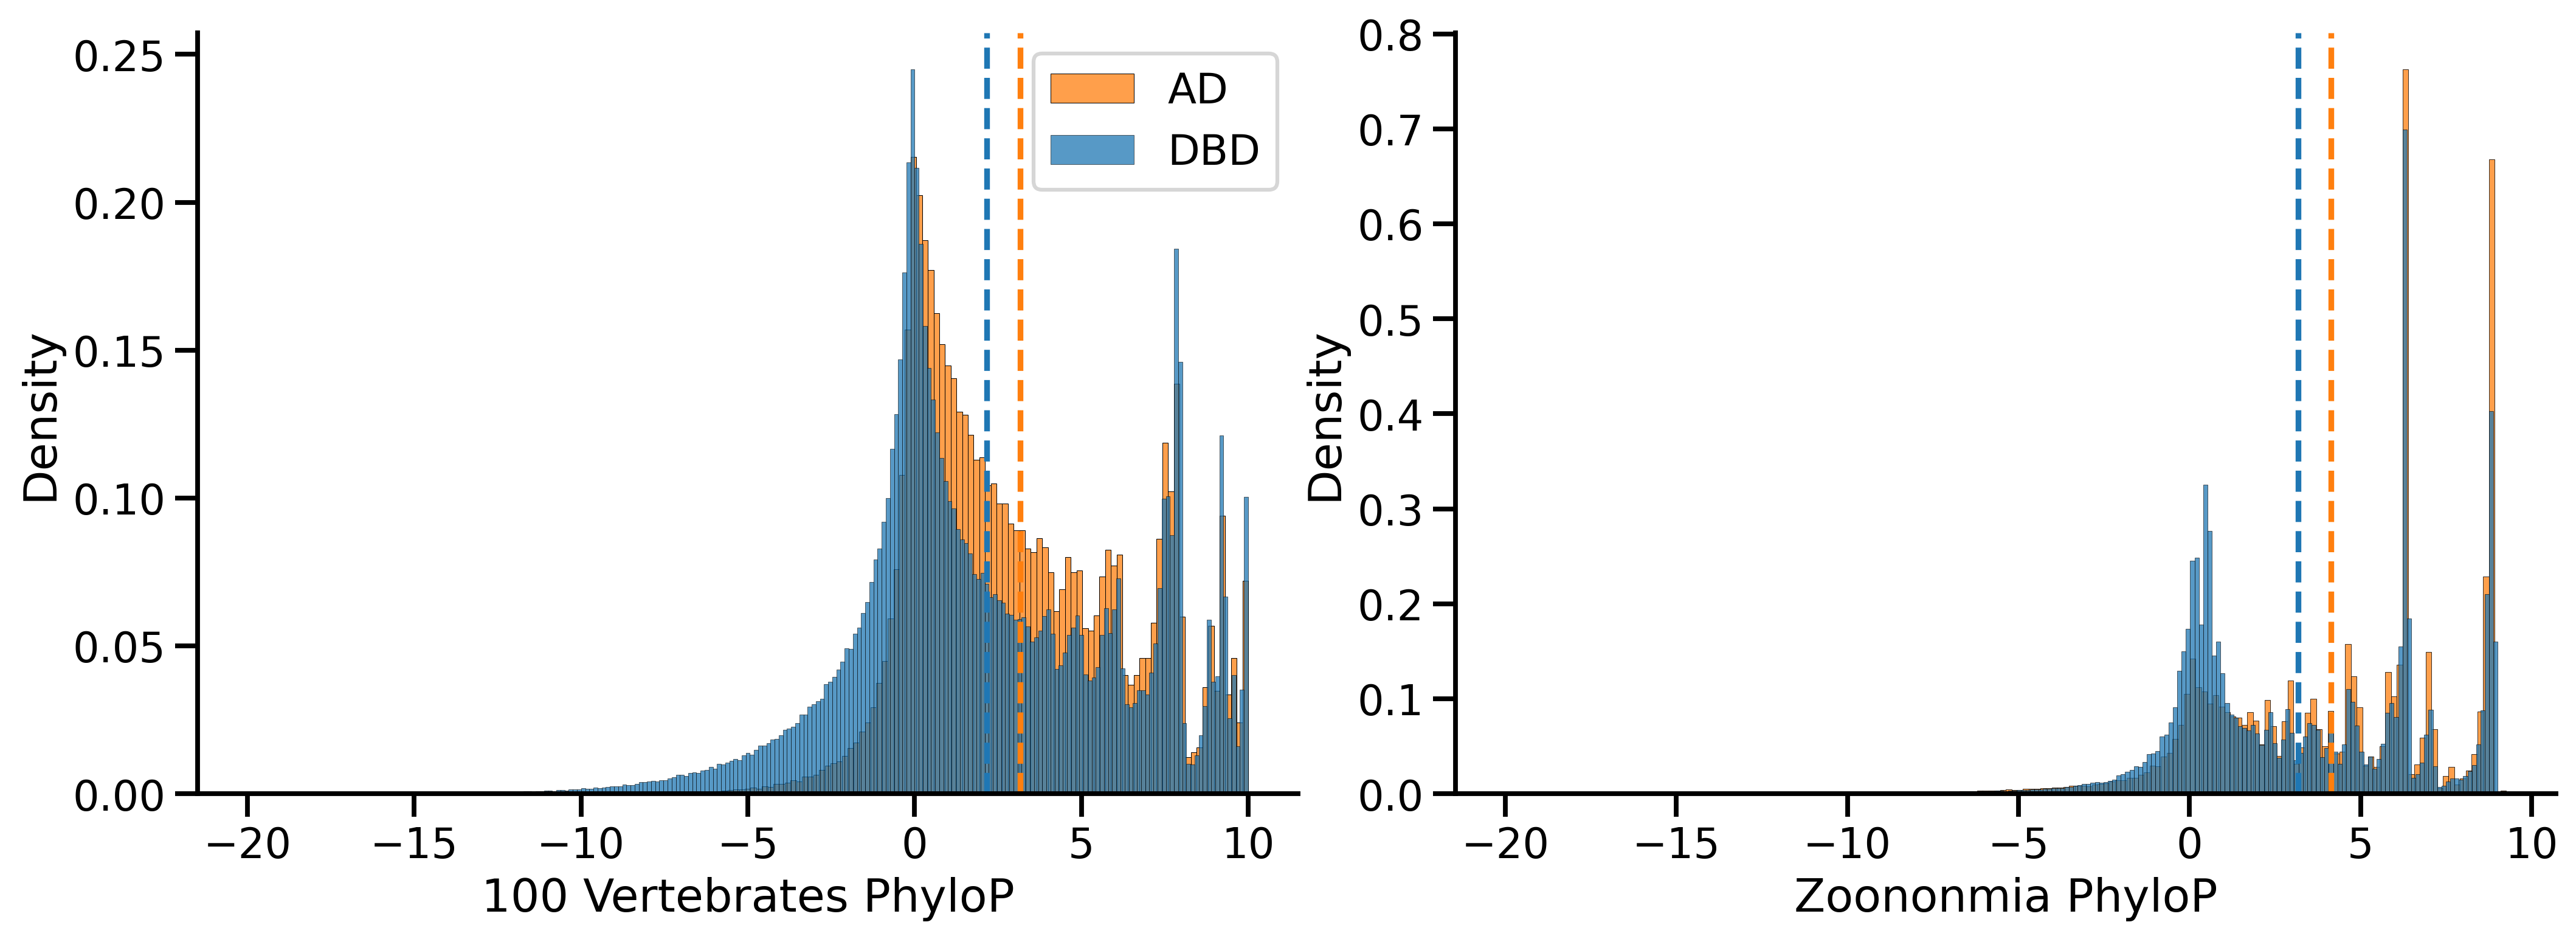

In [64]:
sns.set_context('talk')
fig, axs = plt.subplots(1, 2, figsize = (14, 5), dpi = 300)

axs = [axs[1], axs[0]]

sns.histplot(zoonomia_domains[zoonomia_domains[3] == "AD"][16], label = "AD", 
             color = "C1", ax = axs[0], stat = 'density')
axs[0].axvline(np.mean(zoonomia_domains[zoonomia_domains[3] == "AD"][16]), 
            color = "C1", linestyle = "--")

sns.histplot(zoonomia_domains[zoonomia_domains[3] == "DBD"][16], 
             label = "DBD", ax = axs[0], stat = 'density')
axs[0].axvline(np.mean(zoonomia_domains[zoonomia_domains[3] == "DBD"][16]), 
            color = "C0", linestyle = "--")

axs[0].set_xlabel("Zoononmia PhyloP")


sns.histplot(verteb_domains[verteb_domains[3] == "AD"][16], label = "AD", 
             color = "C1", ax = axs[1], stat = 'density')
axs[1].axvline(np.mean(verteb_domains[verteb_domains[3] == "AD"][16]), 
            color = "C1", linestyle = "--")

sns.histplot(verteb_domains[verteb_domains[3] == "DBD"][16], 
             label = "DBD", ax = axs[1], stat = 'density')
axs[1].axvline(np.mean(verteb_domains[verteb_domains[3] == "DBD"][16]), 
            color = "C0", linestyle = "--")
axs[1].legend()

sns.despine()
#plt.legend()
axs[1].set_xlabel("100 Vertebrates PhyloP")
plt.tight_layout(pad = 0.1)

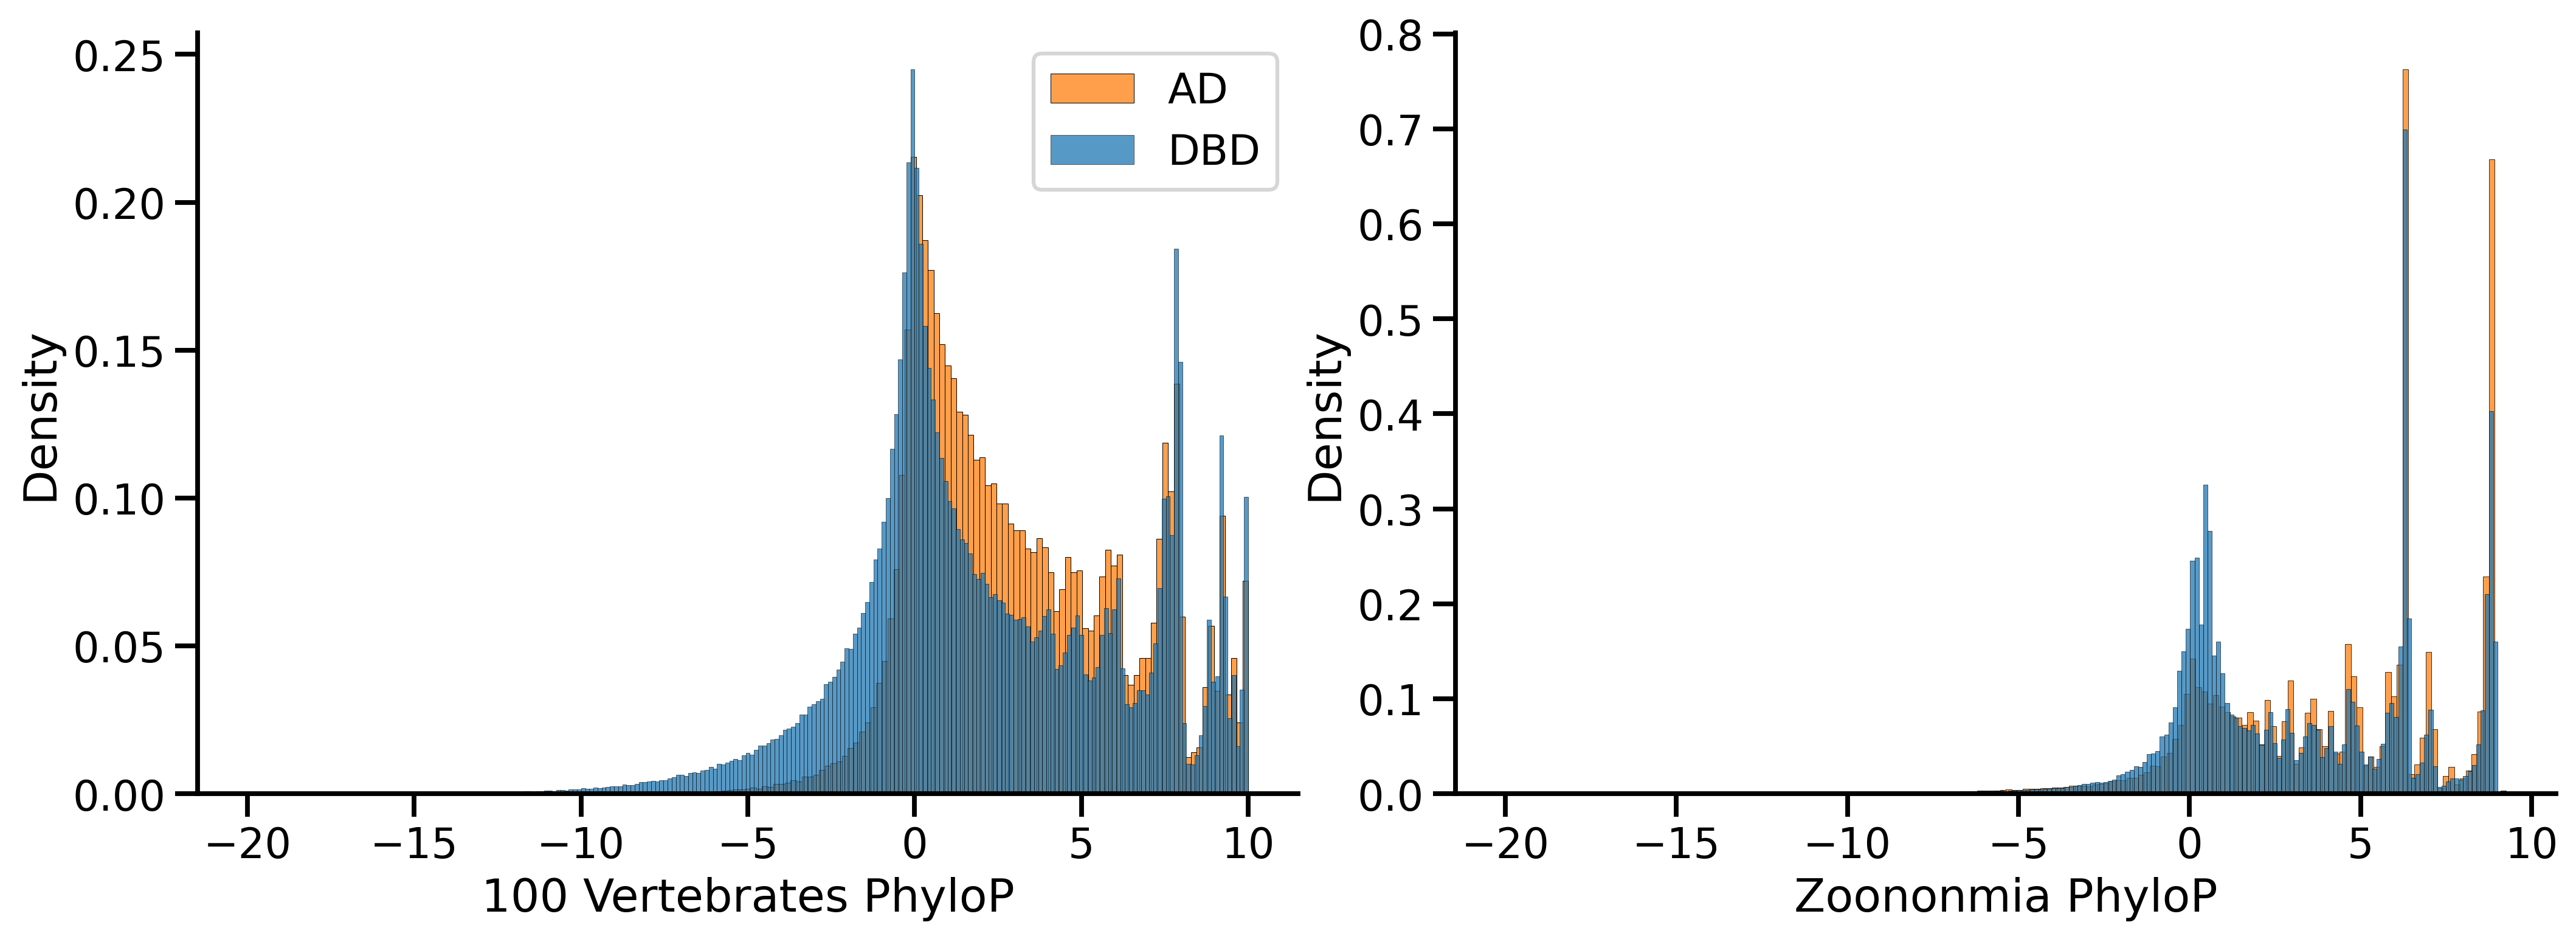

In [65]:
sns.set_context('talk')
fig, axs = plt.subplots(1, 2, figsize = (14, 5), dpi = 300)

axs = [axs[1], axs[0]]

sns.histplot(zoonomia_domains[zoonomia_domains[3] == "AD"][16], label = "AD", 
             color = "C1", ax = axs[0], stat = 'density')
# axs[0].axvline(np.mean(zoonomia_domains[zoonomia_domains[3] == "AD"][16]), 
#             color = "C1", linestyle = "--")

sns.histplot(zoonomia_domains[zoonomia_domains[3] == "DBD"][16], 
             label = "DBD", ax = axs[0], stat = 'density')
# axs[0].axvline(np.mean(zoonomia_domains[zoonomia_domains[3] == "DBD"][16]), 
#             color = "C0", linestyle = "--")

axs[0].set_xlabel("Zoononmia PhyloP")


sns.histplot(verteb_domains[verteb_domains[3] == "AD"][16], label = "AD", 
             color = "C1", ax = axs[1], stat = 'density')
# axs[1].axvline(np.mean(verteb_domains[verteb_domains[3] == "AD"][16]), 
#             color = "C1", linestyle = "--")

sns.histplot(verteb_domains[verteb_domains[3] == "DBD"][16], 
             label = "DBD", ax = axs[1], stat = 'density')
# axs[1].axvline(np.mean(verteb_domains[verteb_domains[3] == "DBD"][16]), 
#             color = "C0", linestyle = "--")
axs[1].legend()

sns.despine()
#plt.legend()
axs[1].set_xlabel("100 Vertebrates PhyloP")
plt.tight_layout(pad = 0.1)

In [66]:
name_map = pd.read_csv("../data/lambert_tfs_gene_names.tsv", sep = "\t")
name_map = name_map.rename(columns = {"From" : "uniprotID", "Gene Names (primary)" : "Gene"})
name_map = name_map.drop(columns = "Entry")
all_TFs_with_gene_name = pd.merge(all_TFs, name_map, on = "uniprotID")
all_TFs_with_gene_name

,Unnamed: 0,1,2,uniprotID,ENSG,ENST,DBD_coords,AD_coords,RD_coords,Bif_coords,length,Gene
0,1,NaN,NaN,A0AVK6,NaN,ENST00000250024,"114-182,262-347",NaN,NaN,NaN,1,E2F8
1,2,NaN,NaN,A1YPR0,NaN,ENST00000535628,"364-386,392-414,420-442,448-469",NaN,NaN,NaN,1,ZBTB7C
2,3,NaN,NaN,A2RRD8,NaN,ENST00000391781,"161-183,189-211,217-239,245-267,273-295,301-32...",NaN,NaN,NaN,1,ZNF320
3,4,NaN,NaN,A2RU54,NaN,ENST00000339992,150-206,NaN,NaN,NaN,1,HMX2
4,5,NaN,NaN,A4D1E1,NaN,ENST00000333190,56-78,NaN,NaN,NaN,1,ZNF804B
...,...,...,...,...,...,...,...,...,...,...,...,...
1565,1585,NaN,NaN,Q9Y692,NaN,ENST00000294409,89-165,422-573,NaN,NaN,1,GMEB1
1566,1586,NaN,NaN,Q9Y6Q3,NaN,ENST00000374227,"293-315,321-343,377-399,405-427,433-455,461-48...",NaN,NaN,NaN,1,ZFP37
1567,1587,NaN,NaN,Q9Y6Q9,NaN,ENST00000371998,31-83,621-1424,NaN,NaN,1,NCOA3
1568,1588,NaN,NaN,Q9Y6X0,NaN,ENST00000649279,"583-596,1015-1027,1450-1462",NaN,NaN,NaN,1,SETBP1


In [67]:
dfs = []
for path in glob.glob("../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/*"):
    df = pd.read_csv(path, index_col = 0)
    df["path"] = path
    dfs.append(df)
percent_identities = pd.concat(dfs)
percent_identities["Gene"] = percent_identities["path"].str.split("/").str[-1]
percent_identities = percent_identities.drop(columns = "path")
percent_identities

,percent_identity,pos,Gene
0,97.722567,M,ARID3C
1,97.515528,E,ARID3C
2,91.304348,A,ARID3C
3,97.515528,L,ARID3C
4,97.515528,Q,ARID3C
...,...,...,...
337,96.995708,N,HOXC10
338,98.497854,F,HOXC10
339,98.497854,N,HOXC10
340,98.497854,F,HOXC10


In [68]:
percent_identities_with_uniprotID = pd.merge(percent_identities, all_TFs_with_gene_name[["uniprotID", "Gene"]])
percent_identities_with_uniprotID

,percent_identity,pos,Gene,uniprotID
0,97.722567,M,ARID3C,A6NKF2
1,97.515528,E,ARID3C,A6NKF2
2,91.304348,A,ARID3C,A6NKF2
3,97.515528,L,ARID3C,A6NKF2
4,97.515528,Q,ARID3C,A6NKF2
...,...,...,...,...
638741,96.995708,N,HOXC10,Q9NYD6
638742,98.497854,F,HOXC10,Q9NYD6
638743,98.497854,N,HOXC10,Q9NYD6
638744,98.497854,F,HOXC10,Q9NYD6


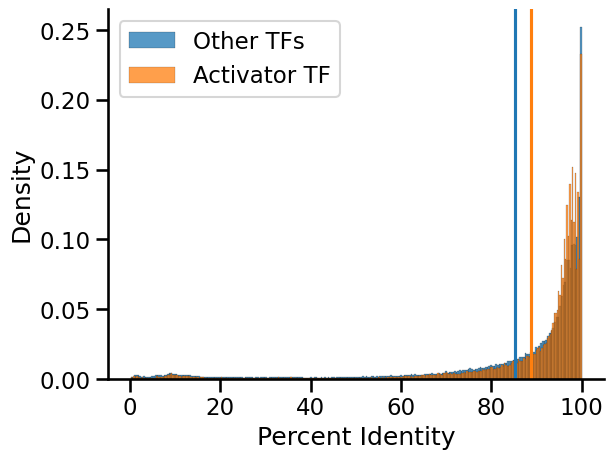

In [69]:
sns.histplot(percent_identities_with_uniprotID[~percent_identities_with_uniprotID["uniprotID"].isin(activator_TFs["uniprotID"])]["percent_identity"], 
             stat = 'density', label = "Other TFs", color = "C0")
plt.axvline(np.mean(percent_identities_with_uniprotID[~percent_identities_with_uniprotID["uniprotID"].isin(activator_TFs["uniprotID"])]["percent_identity"]), 
            color = "C0")

sns.histplot(percent_identities_with_uniprotID[percent_identities_with_uniprotID["uniprotID"].isin(activator_TFs["uniprotID"])]["percent_identity"], 
             stat = 'density', label = "Activator TF", color = "C1")
plt.axvline(np.mean(percent_identities_with_uniprotID[percent_identities_with_uniprotID["uniprotID"].isin(activator_TFs["uniprotID"])]["percent_identity"]), 
            color = "C1")

sns.despine()
plt.xlabel("Percent Identity")

plt.legend()

Constraint

In [70]:
return_big_df("../soto_analysis/outputs/mutations/cds_mtr/*")

EmptyDataError: No columns to parse from file

---

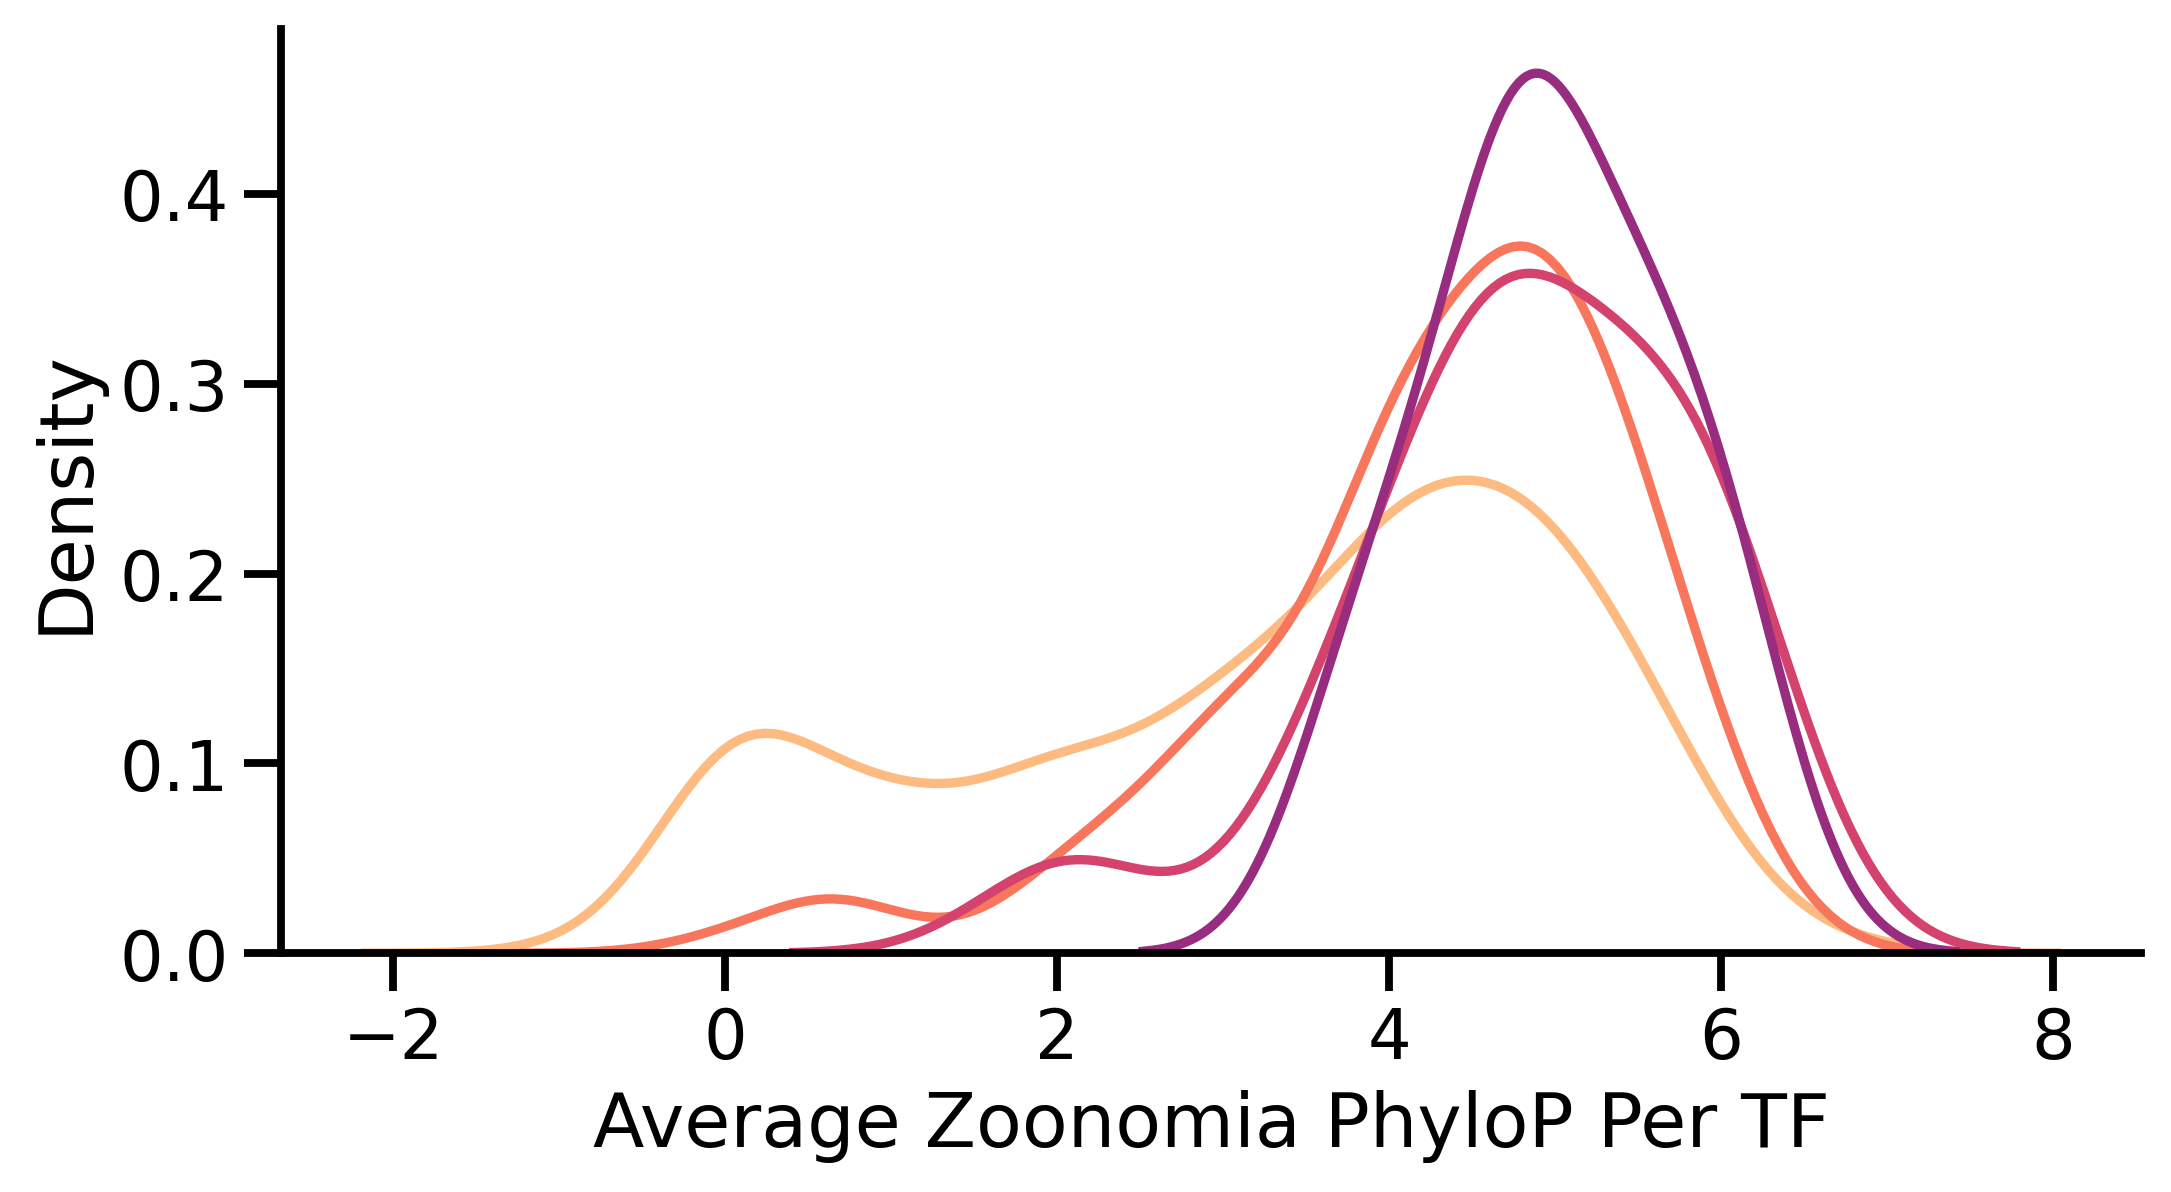

In [71]:
sns.set_context('talk')
plt.figure(figsize = (8, 4), dpi = 300)
palette = sns.color_palette('magma_r')
sns.kdeplot(zoonomia_all_TFs[[3, 8]].groupby(3).mean()[8], label = "All TFs", color = palette[0])
sns.kdeplot(zoonomia_activator_TFs[[3, 8]].groupby(3).mean()[8], label = "Activator TFs", color = palette[1])
sns.kdeplot(zoonomia_SFARI_activator_TFs[[3, 8]].groupby(3).mean()[8], label = "SFARI Activator TFs", color = palette[2])
sns.kdeplot(zoonomia_SFARI_TF_hits[[3, 8]].groupby(3).mean()[8], label = "SFARI Activator TF Hits", color = palette[3])
plt.xlabel("Average Zoonomia PhyloP Per TF")
sns.despine()
#plt.legend()

(0.0, 0.37)

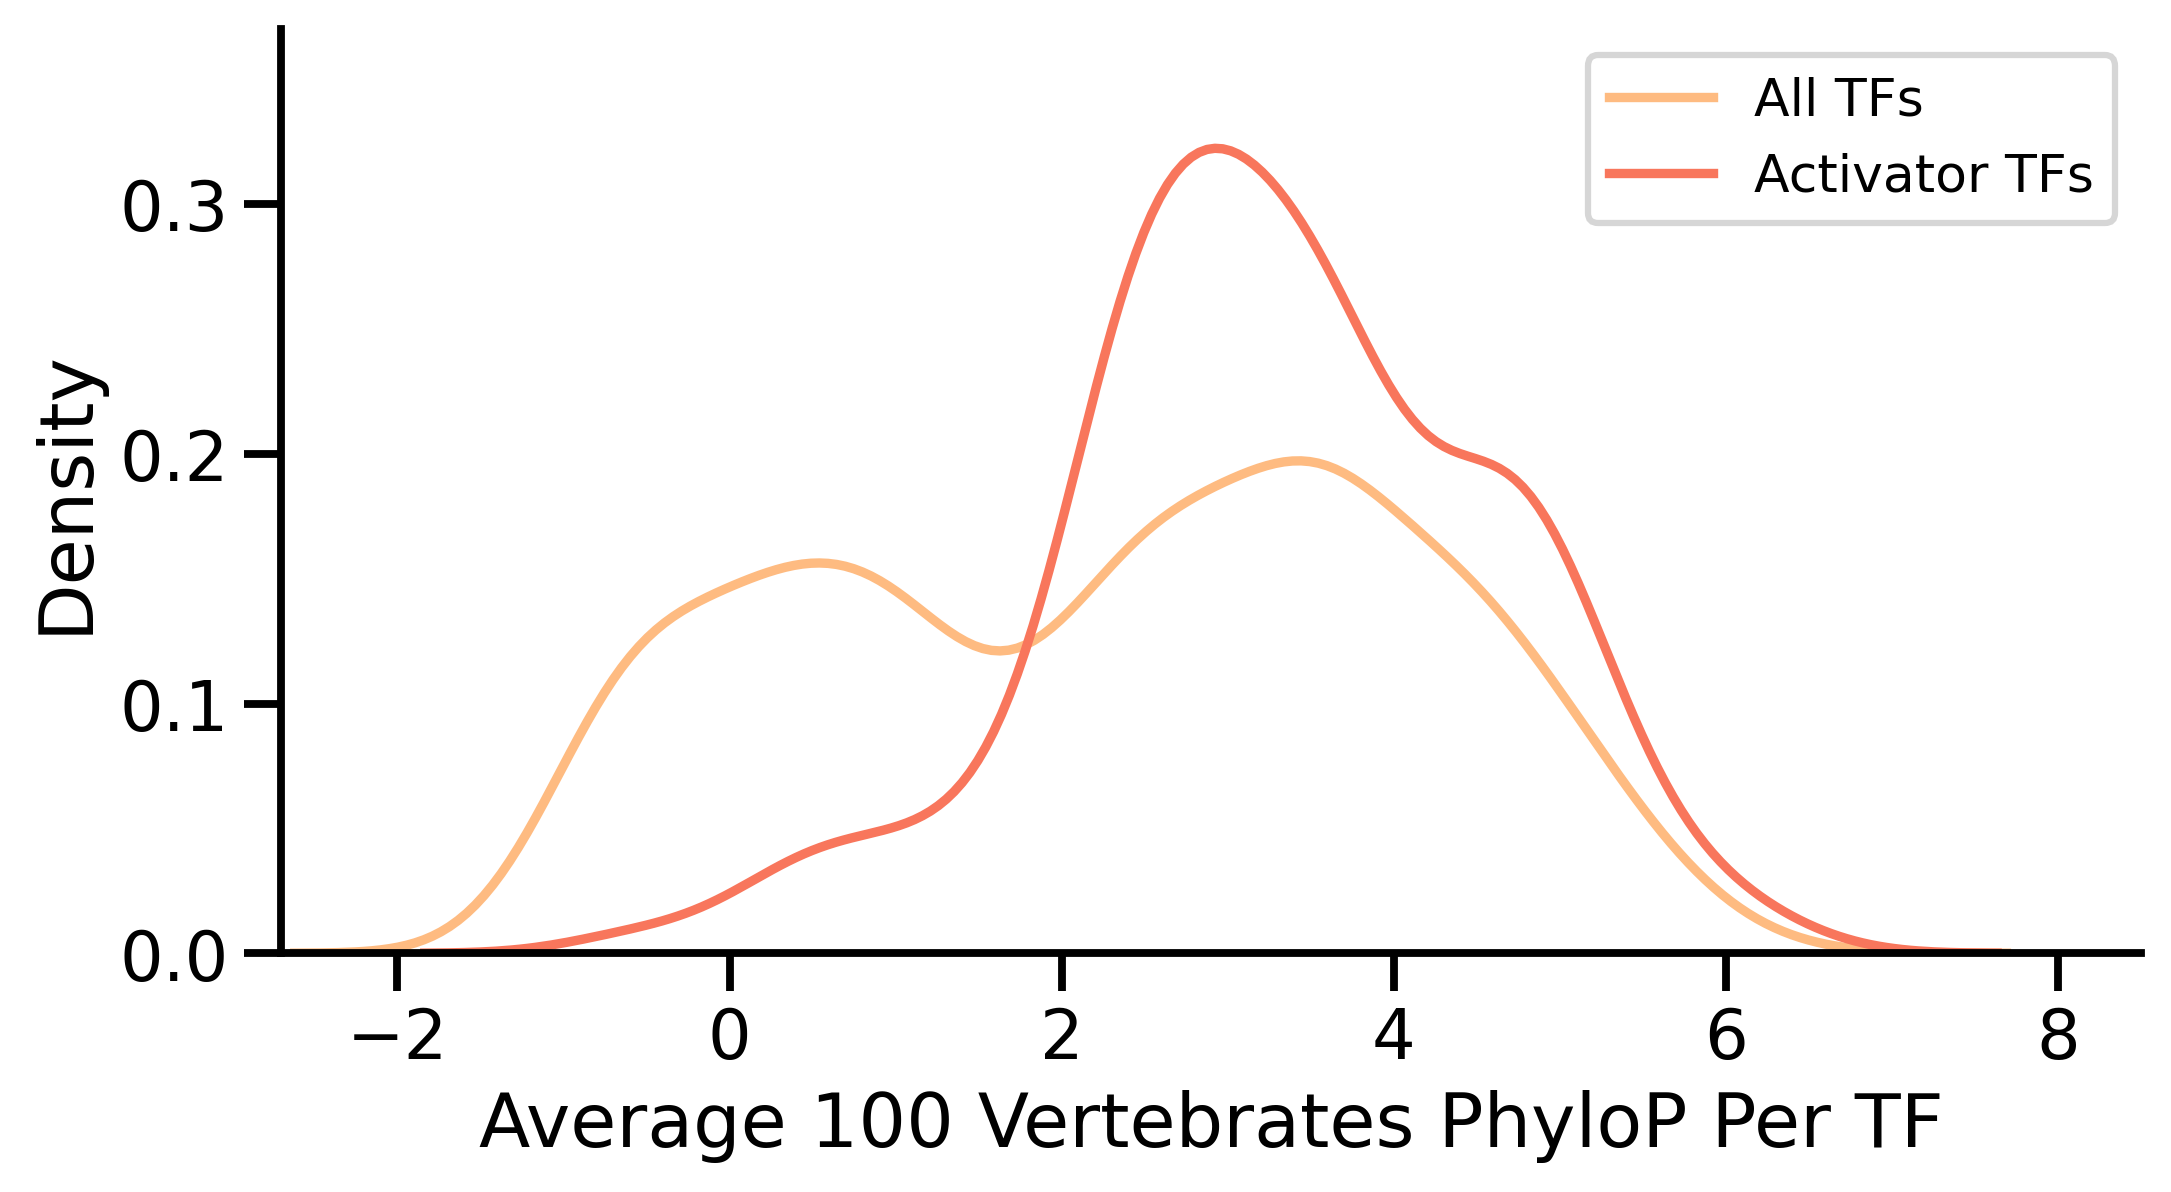

In [72]:
sns.set_context('talk')
plt.figure(figsize = (8, 4), dpi = 300)
palette = sns.color_palette('magma_r')
sns.kdeplot(verteb_all_TFs[[3, 8]].groupby(3).mean()[8], label = "All TFs", color = palette[0])
sns.kdeplot(verteb_activator_TFs[[3, 8]].groupby(3).mean()[8], label = "Activator TFs", color = palette[1])
# sns.kdeplot(verteb_SFARI_activator_TFs[[3, 8]].groupby(3).mean()[8], label = "SFARI Activator TFs", color = palette[2])
# sns.kdeplot(verteb_SFARI_TF_hits[[3, 8]].groupby(3).mean()[8], label = "SFARI Activator TF Hits", color = palette[3])
plt.xlabel("Average 100 Vertebrates PhyloP Per TF")
sns.despine()
plt.legend(fontsize = 'x-small')

plt.xlim(-2.7,8.5)
plt.ylim(0, 0.37)

(0.0, 0.37)

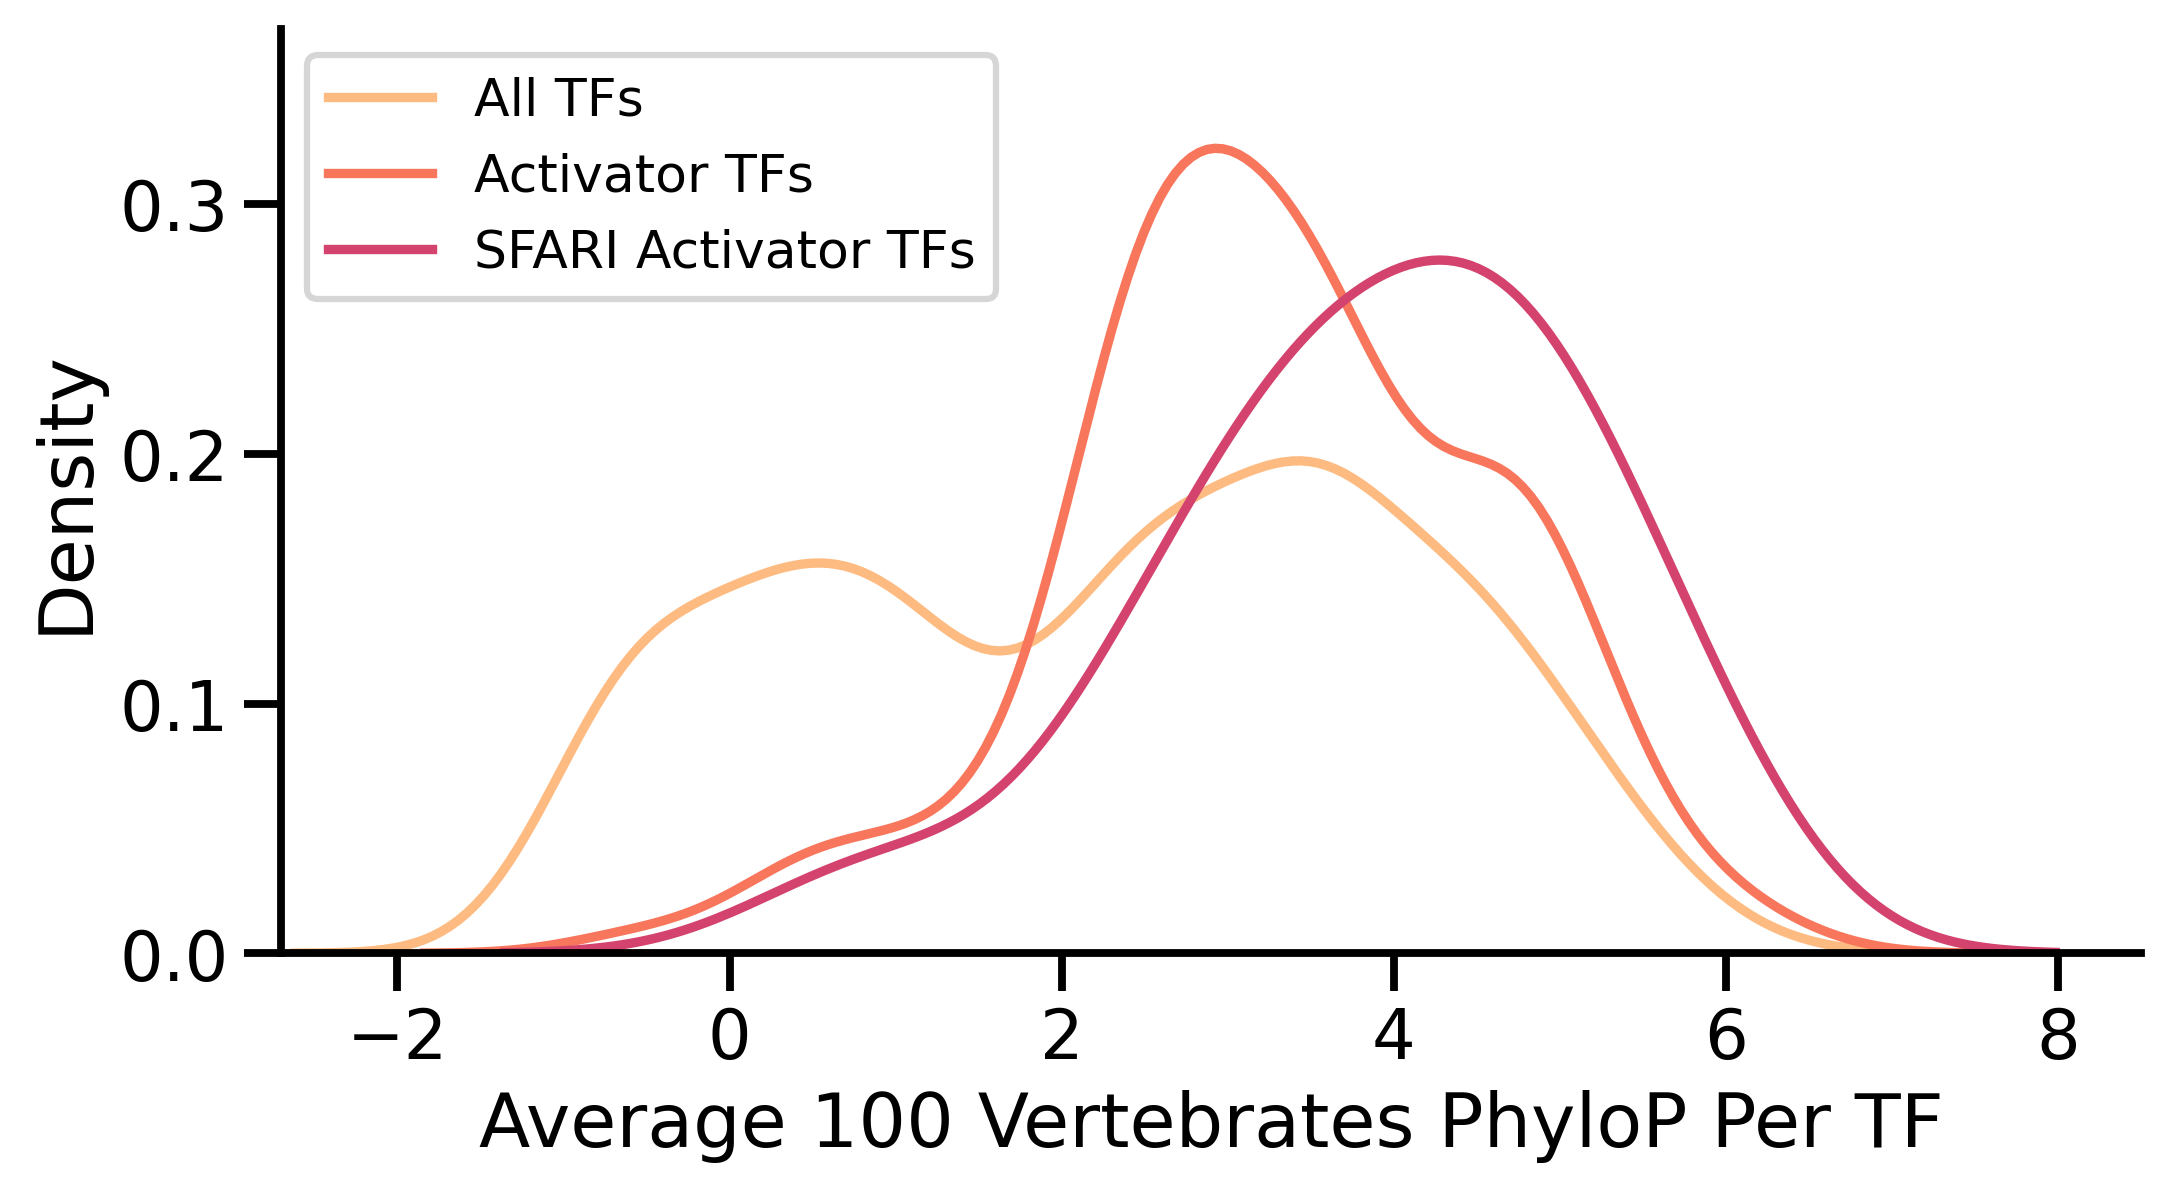

In [74]:
sns.set_context('talk')
plt.figure(figsize = (8, 4), dpi = 300)
palette = sns.color_palette('magma_r')
sns.kdeplot(verteb_all_TFs[[3, 8]].groupby(3).mean()[8], label = "All TFs", color = palette[0])
sns.kdeplot(verteb_activator_TFs[[3, 8]].groupby(3).mean()[8], label = "Activator TFs", color = palette[1])
sns.kdeplot(verteb_SFARI_activator_TFs[[3, 8]].groupby(3).mean()[8], label = "SFARI Activator TFs", color = palette[2])
#sns.kdeplot(verteb_SFARI_TF_hits[[3, 8]].groupby(3).mean()[8], label = "SFARI Activator TF Hits", color = palette[3])
plt.xlabel("Average 100 Vertebrates PhyloP Per TF")
sns.despine()
plt.legend(fontsize = 'x-small')

plt.xlim(-2.7,8.5)
plt.ylim(0, 0.37)

(-2.7, 8.5)

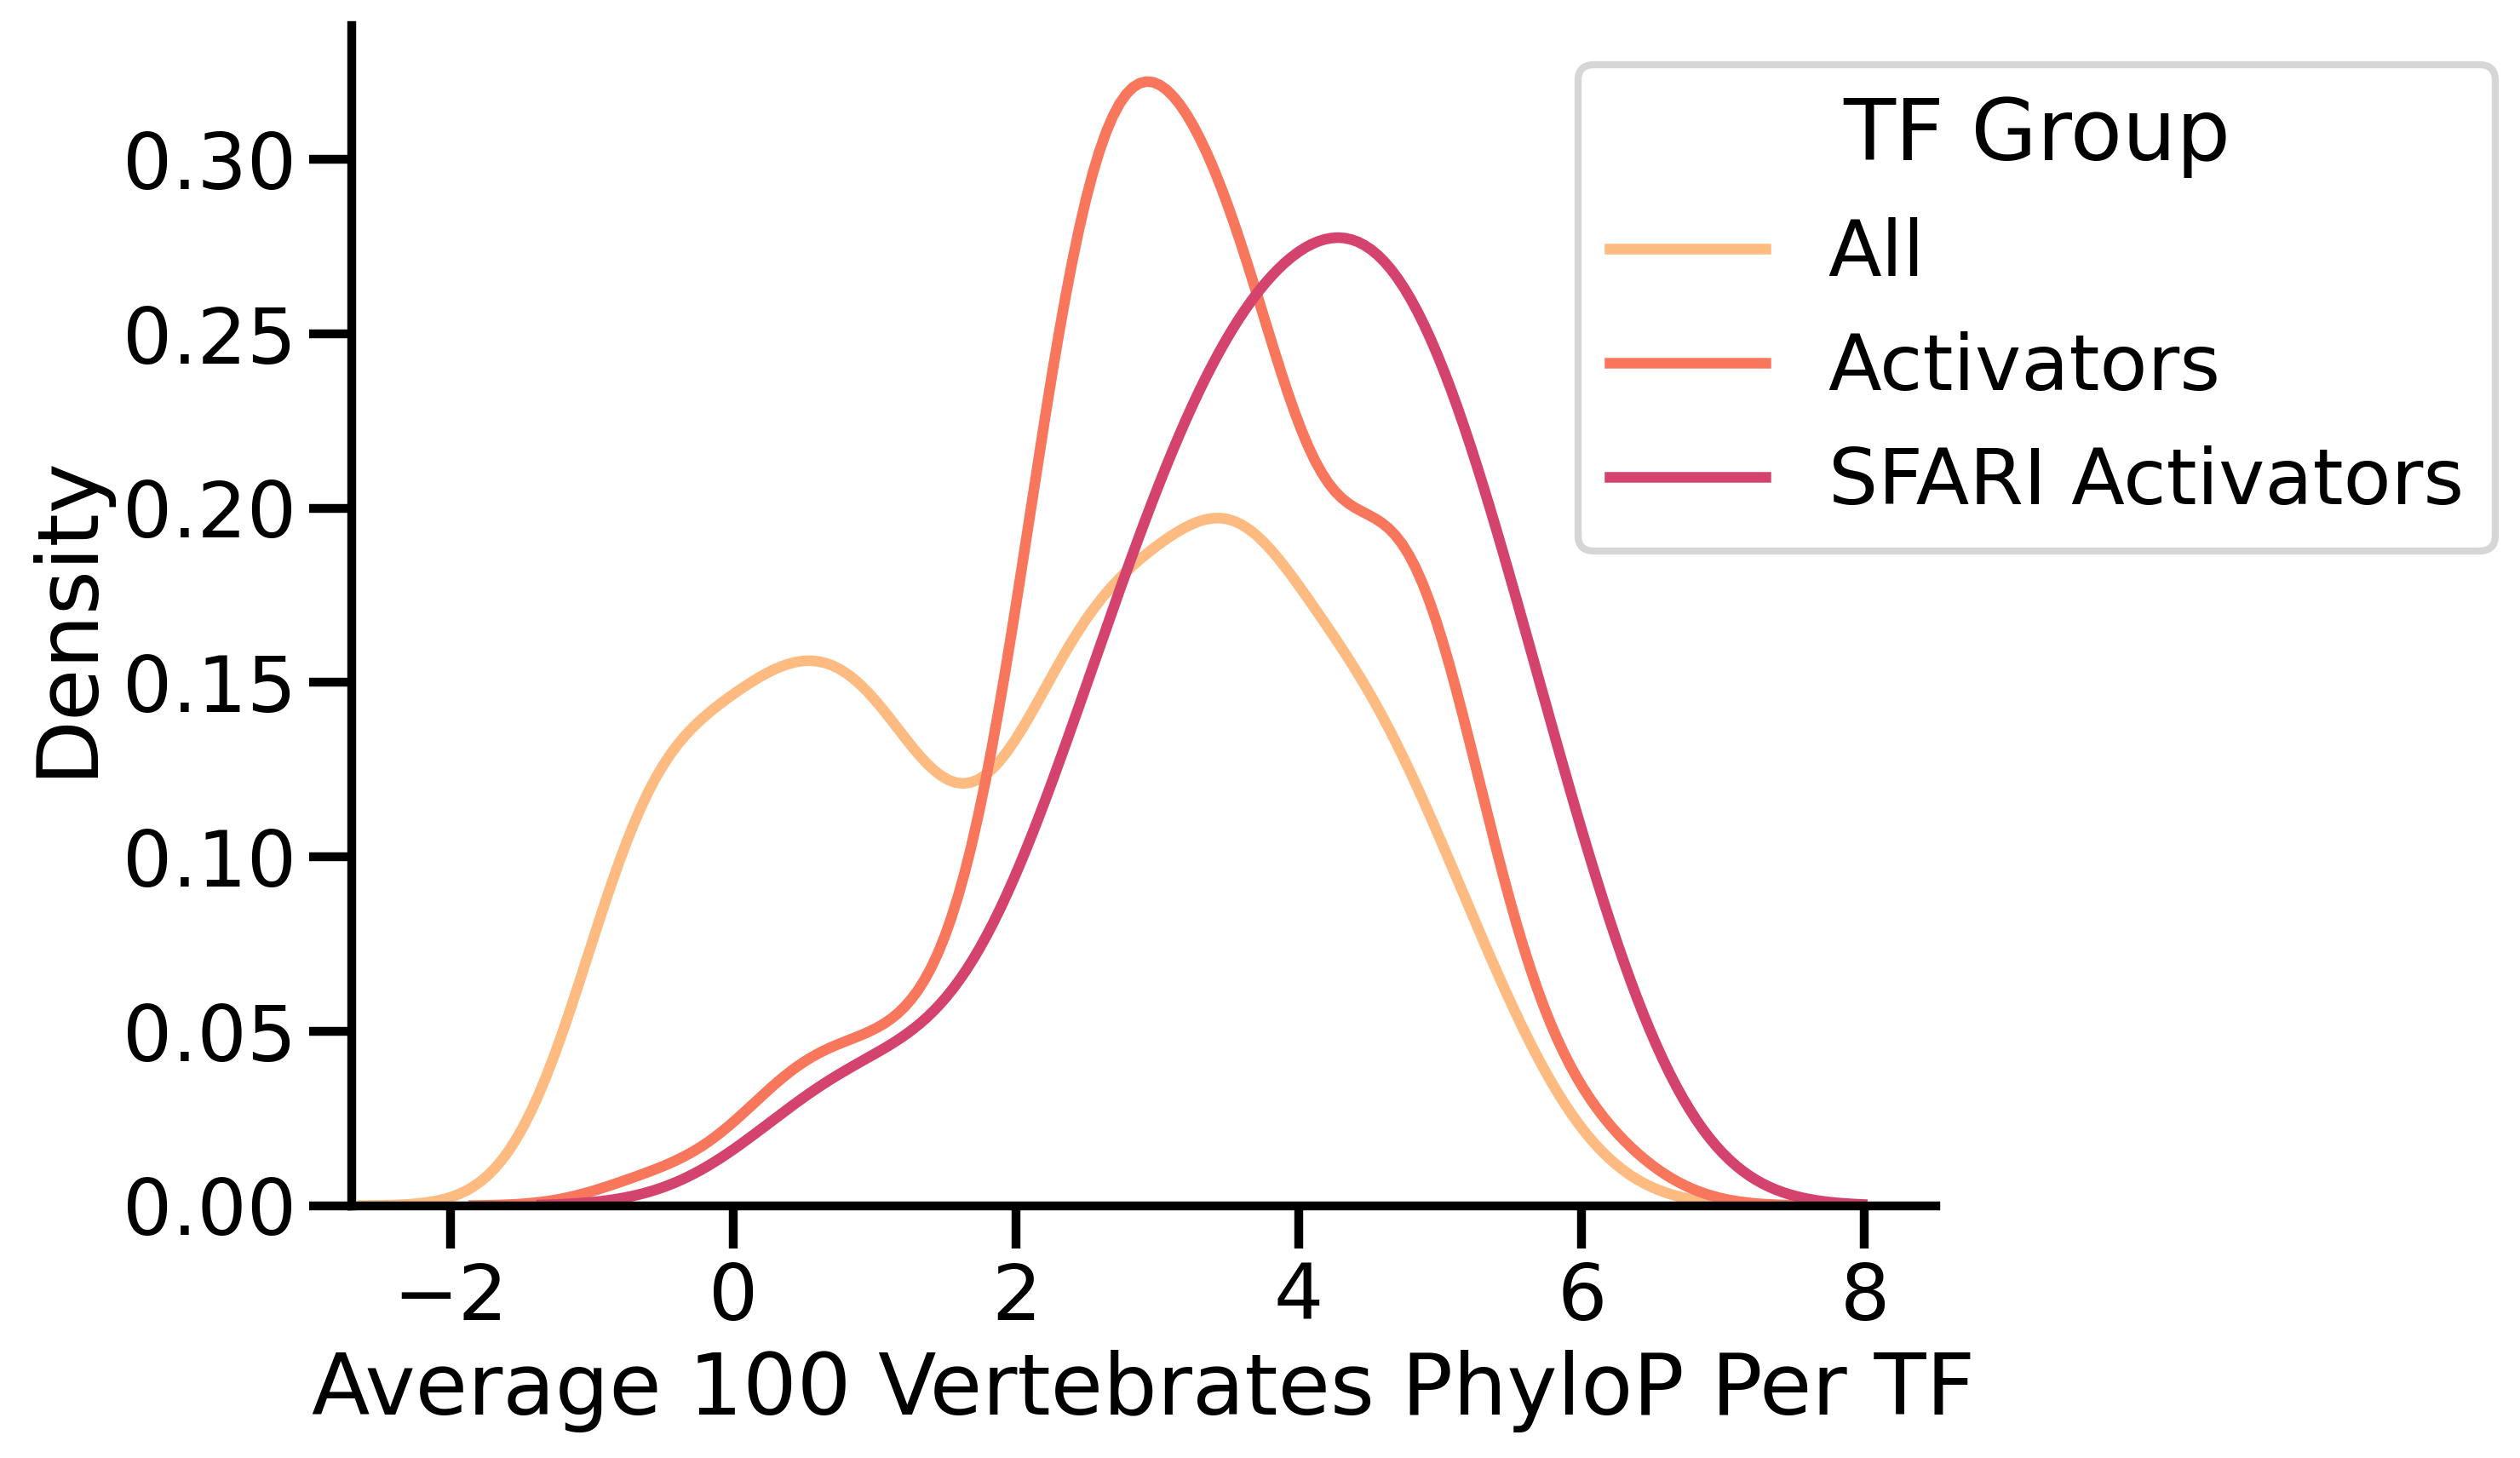

In [75]:
sns.set_context('poster')
plt.figure(figsize = (8, 6), dpi = 300)
palette = sns.color_palette('magma_r')
sns.kdeplot(verteb_all_TFs[[3, 8]].groupby(3).mean()[8], label = "All", color = palette[0])
sns.kdeplot(verteb_activator_TFs[[3, 8]].groupby(3).mean()[8], label = "Activators", color = palette[1])
sns.kdeplot(verteb_SFARI_activator_TFs[[3, 8]].groupby(3).mean()[8], label = "SFARI Activators", color = palette[2])
#sns.kdeplot(verteb_SFARI_TF_hits[[3, 8]].groupby(3).mean()[8], label = "SFARI Activator TF Hits", color = palette[3])
plt.xlabel("Average 100 Vertebrates PhyloP Per TF")
sns.despine()
plt.legend(title = "TF Group", bbox_to_anchor = (0.75, 1))

plt.xlim(-2.7,8.5)
#plt.ylim(0, 0.37)

(0.0, 0.37)

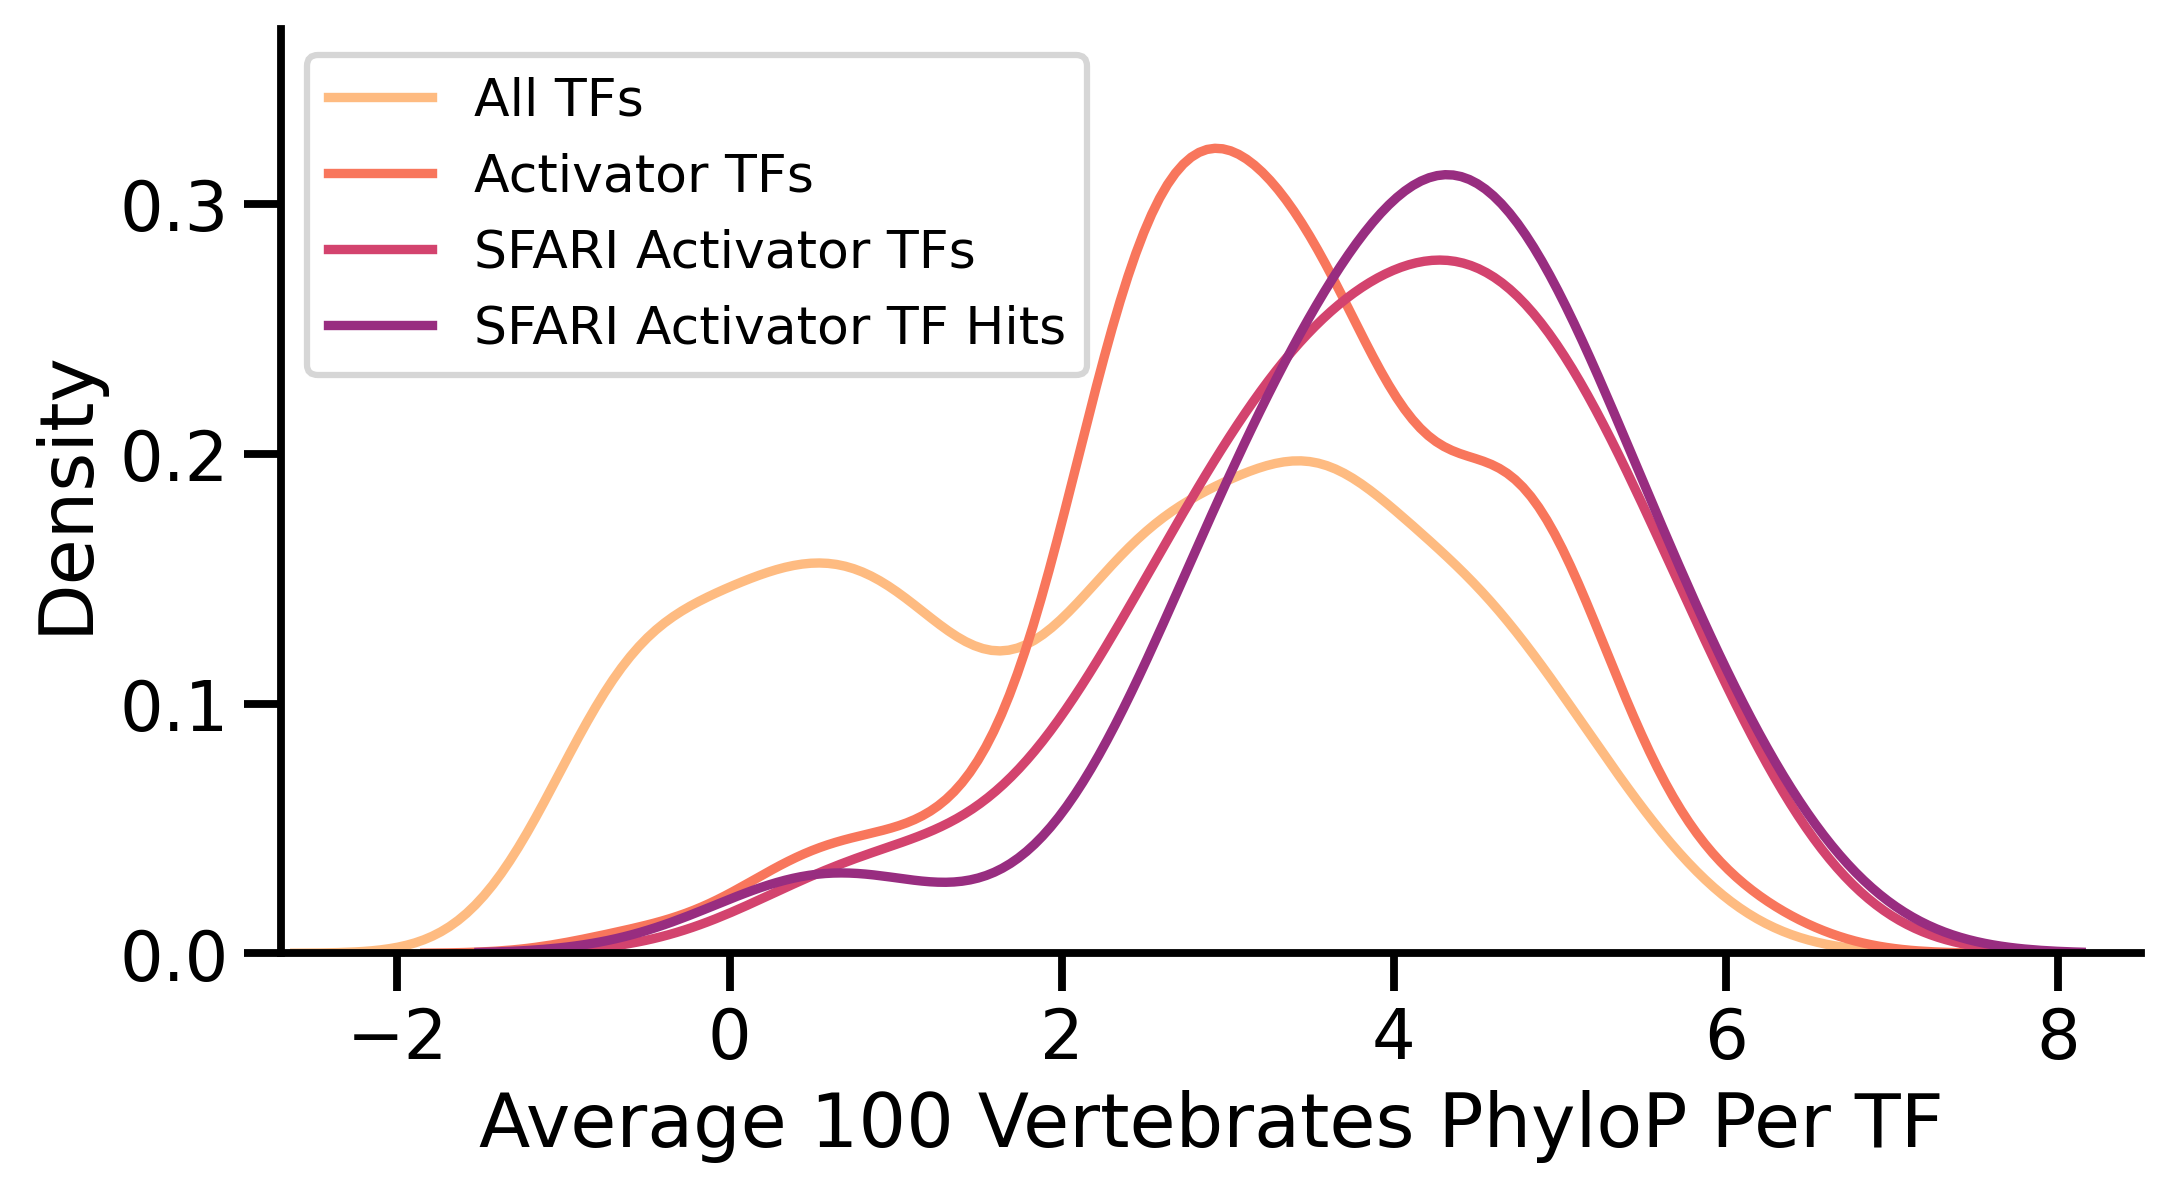

In [76]:
sns.set_context('talk')
plt.figure(figsize = (8, 4), dpi = 300)
palette = sns.color_palette('magma_r')
sns.kdeplot(verteb_all_TFs[[3, 8]].groupby(3).mean()[8], label = "All TFs", color = palette[0])
sns.kdeplot(verteb_activator_TFs[[3, 8]].groupby(3).mean()[8], label = "Activator TFs", color = palette[1])
sns.kdeplot(verteb_SFARI_activator_TFs[[3, 8]].groupby(3).mean()[8], label = "SFARI Activator TFs", color = palette[2])
sns.kdeplot(verteb_SFARI_TF_hits[[3, 8]].groupby(3).mean()[8], label = "SFARI Activator TF Hits", color = palette[3])
plt.xlabel("Average 100 Vertebrates PhyloP Per TF")
sns.despine()
plt.legend(fontsize = 'x-small')

plt.xlim(-2.7,8.5)
plt.ylim(0, 0.37)

In [80]:
lambert_TFs

,Unnamed: 0,gene_id,gene,From,Entry,Gene Names (primary),LOEUF,transcript,repressor,activator,sfari,hits
0,0,ENSG00000137203,TFAP2A,TFAP2A,P05549,TFAP2A,0.334,ENST00000379613,False,True,False,False
1,1,ENSG00000008196,TFAP2B,TFAP2B,Q92481,TFAP2B,0.353,ENST00000393655,True,True,False,False
2,2,ENSG00000087510,TFAP2C,TFAP2C,Q92754,TFAP2C,0.417,ENST00000201031,True,True,False,False
3,3,ENSG00000008197,TFAP2D,TFAP2D,Q7Z6R9,TFAP2D,0.389,ENST00000008391,False,True,False,False
4,4,ENSG00000116819,TFAP2E,TFAP2E,Q6VUC0,TFAP2E,1.418,ENST00000373235,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1658,1658,ENSG00000177683,THAP5,THAP5,Q7Z6K1,THAP5,1.089,ENST00000415914,True,False,False,False
1659,1659,ENSG00000174796,THAP6,THAP6,Q8TBB0,THAP6,1.028,ENST00000311638,True,False,False,False
1660,1660,ENSG00000184436,THAP7,THAP7,Q9BT49,THAP7,1.147,ENST00000215742,True,False,False,False
1661,1661,ENSG00000161277,THAP8,THAP8,Q8NA92,THAP8,1.615,ENST00000292894,True,False,False,False


In [ ]:
lambert_TFs

,Unnamed: 0,gene_id,gene,From,Entry,Gene Names (primary),LOEUF,transcript,repressor,activator,sfari,hits
0,0,ENSG00000137203,TFAP2A,TFAP2A,P05549,TFAP2A,0.334,ENST00000379613,False,True,False,False
1,1,ENSG00000008196,TFAP2B,TFAP2B,Q92481,TFAP2B,0.353,ENST00000393655,True,True,False,False
2,2,ENSG00000087510,TFAP2C,TFAP2C,Q92754,TFAP2C,0.417,ENST00000201031,True,True,False,False
3,3,ENSG00000008197,TFAP2D,TFAP2D,Q7Z6R9,TFAP2D,0.389,ENST00000008391,False,True,False,False
4,4,ENSG00000116819,TFAP2E,TFAP2E,Q6VUC0,TFAP2E,1.418,ENST00000373235,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1658,1658,ENSG00000177683,THAP5,THAP5,Q7Z6K1,THAP5,1.089,ENST00000415914,True,False,False,False
1659,1659,ENSG00000174796,THAP6,THAP6,Q8TBB0,THAP6,1.028,ENST00000311638,True,False,False,False
1660,1660,ENSG00000184436,THAP7,THAP7,Q9BT49,THAP7,1.147,ENST00000215742,True,False,False,False
1661,1661,ENSG00000161277,THAP8,THAP8,Q8NA92,THAP8,1.615,ENST00000292894,True,False,False,False


In [ ]:
activator_genes = set(lambert_TFs[lambert_TFs["activator"]]["Gene Names (primary)"].dropna())
SFARI_activator_genes = set(lambert_TFs[lambert_TFs["sfari"] & lambert_TFs["activator"]]["Gene Names (primary)"].dropna())
SFARI_hits = set(lambert_TFs[lambert_TFs["hits"]]["Gene Names (primary)"].dropna())

In [ ]:
folder_path = "../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/"
with_percent_identities = glob.glob(folder_path + "*")

In [89]:
def return_list_perc_idents(gene_list):
    return_list = []
    for gene in gene_list:
        if folder_path + gene in with_percent_identities:
            df = pd.read_csv(folder_path + gene)
            avg_percent_ident = np.mean(df["percent_identity"])
            return_list.append(avg_percent_ident)      
    return return_list

In [90]:
activator_genes_perc_idents = return_list_perc_idents(activator_genes)
SFARI_activator_genes_perc_idents = return_list_perc_idents(SFARI_activator_genes)
SFARI_hits_perc_idents = return_list_perc_idents(SFARI_hits)


(60.0, 110.0)

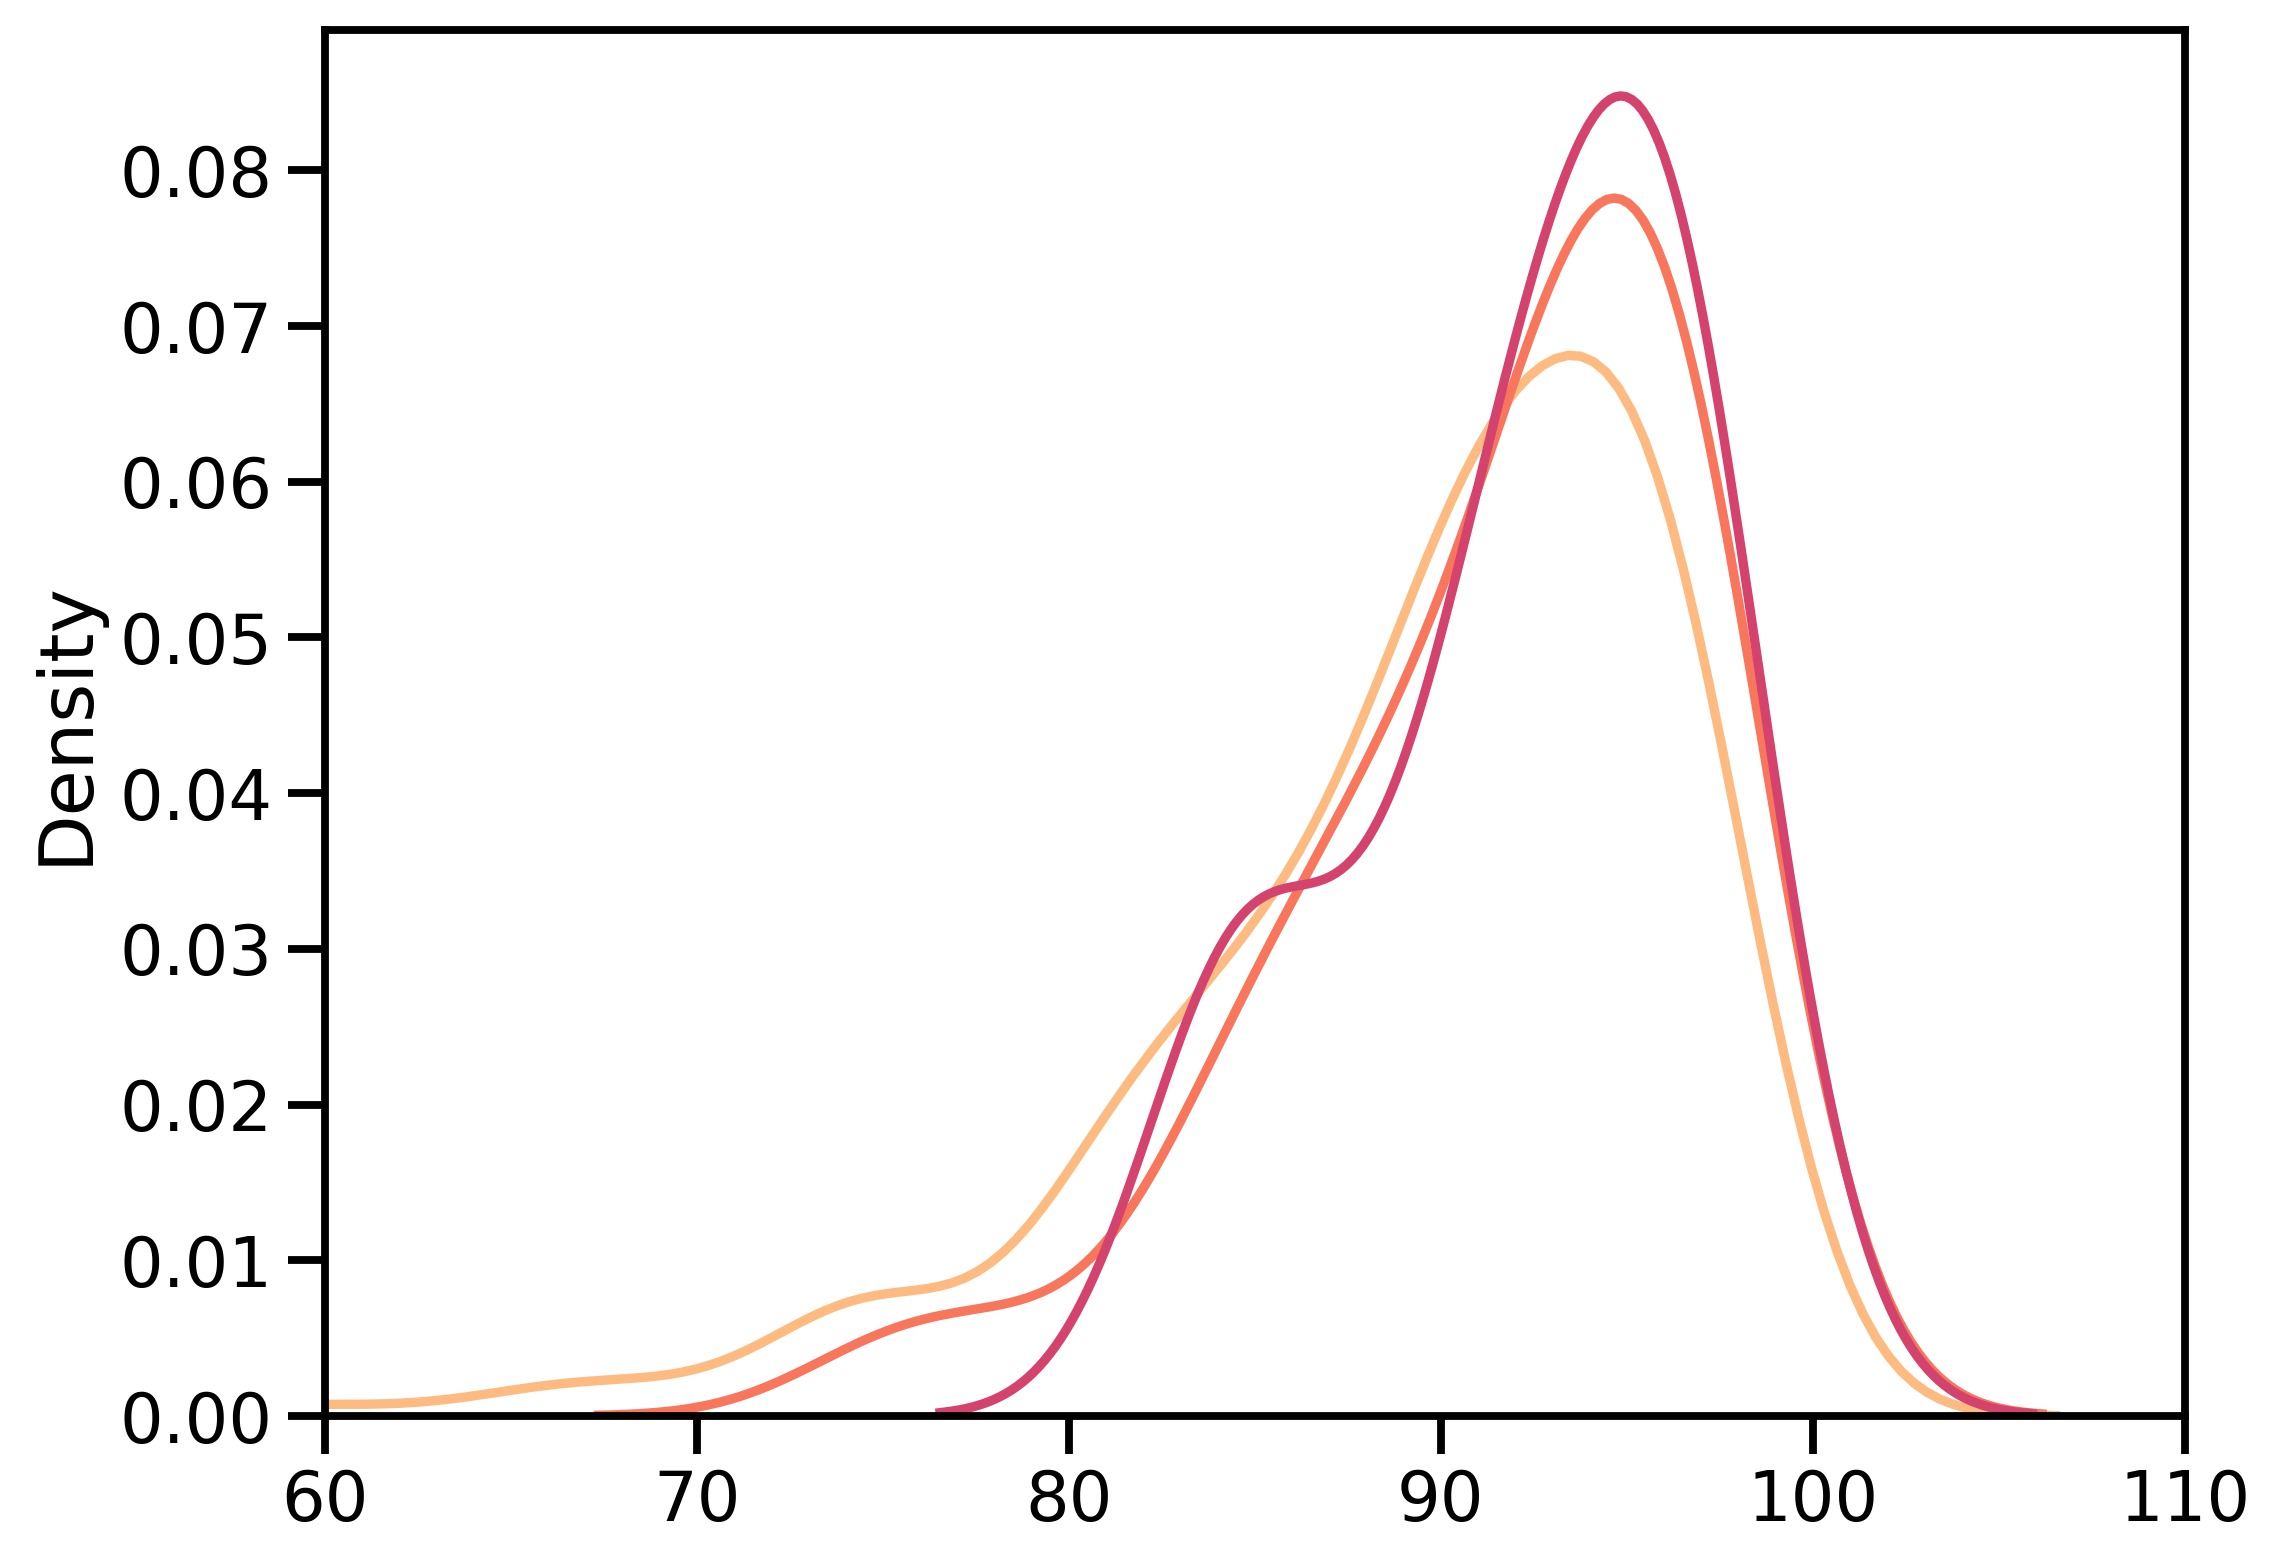

In [91]:
plt.figure(figsize = (8, 6), dpi = 300)
sns.kdeplot(activator_genes_perc_idents, label = "All", color = palette[0])
sns.kdeplot(SFARI_activator_genes_perc_idents, label = "Activators", color = palette[1])
sns.kdeplot(SFARI_hits_perc_idents, label = "SFARI Activators", color = palette[2])
plt.xlim(60, 110)

In [ ]:
sns.set_context('poster')
plt.figure(figsize = (8, 6), dpi = 300)
palette = sns.color_palette('magma_r')
sns.kdeplot(verteb_all_TFs[[3, 8]].groupby(3).mean()[8], label = "All", color = palette[0])
sns.kdeplot(verteb_activator_TFs[[3, 8]].groupby(3).mean()[8], label = "Activators", color = palette[1])
sns.kdeplot(verteb_SFARI_activator_TFs[[3, 8]].groupby(3).mean()[8], label = "SFARI Activators", color = palette[2])
#sns.kdeplot(verteb_SFARI_TF_hits[[3, 8]].groupby(3).mean()[8], label = "SFARI Activator TF Hits", color = palette[3])
plt.xlabel("Average 100 Vertebrates PhyloP Per TF")
sns.despine()
#plt.legend(title = "TF Group", bbox_to_anchor = (0.75, 1))

plt.xlim(-2.7,8.5)
#plt.ylim(0, 0.37)

In [95]:
activator_TFs_loeuf = lambert_TFs[lambert_TFs["transcript"].isin(activator_TFs["ENST"])]
SFARI_TFs_with_ADs = lambert_TFs[lambert_TFs["transcript"].isin(lambert_TFs[lambert_TFs["sfari"] & lambert_TFs["activator"]]["transcript"])]

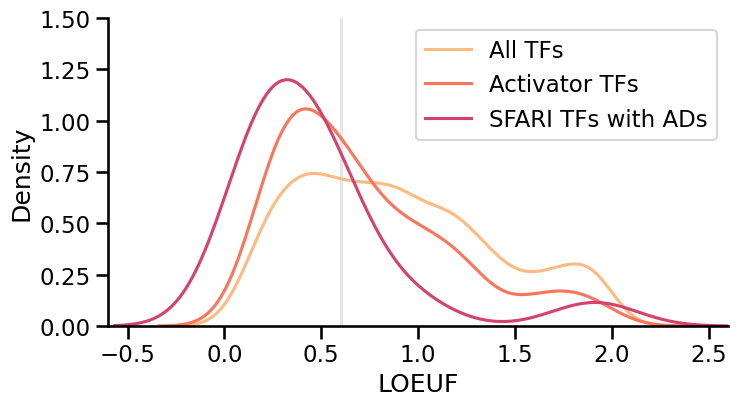

In [96]:
plt.figure(figsize = (8,4))
plt.axvline(0.6, 0,2, color = "gray", alpha = 0.2)
plt.ylim(0, 1.5)

palette = sns.color_palette("magma_r")

plt.xlim(-0.6, 2.6)
sns.kdeplot(lambert_TFs["LOEUF"], color = palette[0], label = "All TFs")
sns.kdeplot(activator_TFs_loeuf["LOEUF"], color = palette[1], label = "Activator TFs")
#sns.kdeplot(SFARI_genes["LOEUF"], color = "purple", label = "SFARI Genes")
sns.kdeplot(SFARI_TFs_with_ADs["LOEUF"], color = palette[2], label = "SFARI TFs with ADs")
sns.despine()
plt.legend();

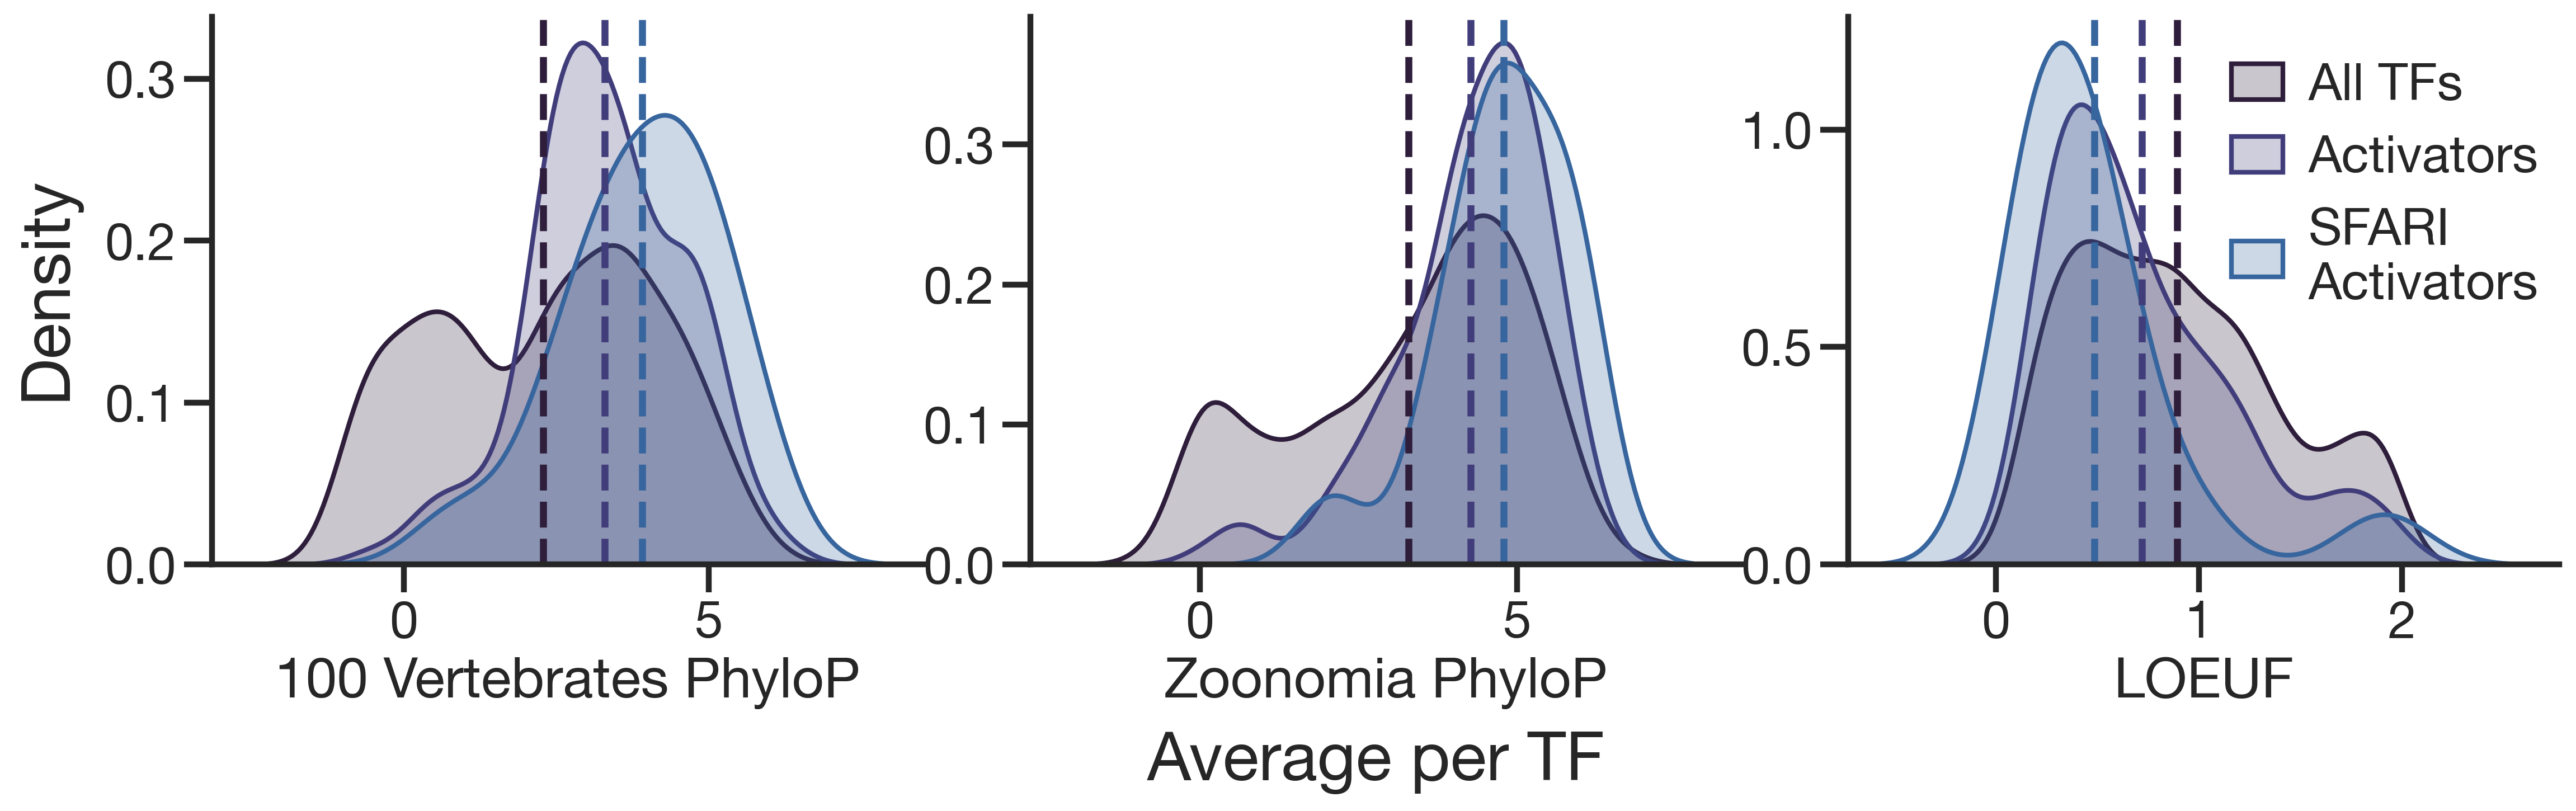

In [200]:
sns.set_context('poster')
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), dpi=300, facecolor='none')  # Create 3 subplots in a single column

palette = sns.color_palette('mako', 6)[:-1]

# First subplot: 100 Vertebrates
sns.kdeplot(verteb_all_TFs[[3, 8]].groupby(3).mean()[8], label="All TFs", color=palette[0], ax=axs[0], fill=True)
sns.kdeplot(verteb_activator_TFs[[3, 8]].groupby(3).mean()[8], label="Activator TFs", color=palette[1], ax=axs[0], fill=True)
sns.kdeplot(verteb_SFARI_activator_TFs[[3, 8]].groupby(3).mean()[8], label="SFARI Activator TFs", color=palette[2], ax=axs[0], fill=True)
axs[0].axvline(verteb_all_TFs[[3, 8]].groupby(3).mean()[8].mean(), color=palette[0], linestyle='--')
axs[0].axvline(verteb_activator_TFs[[3, 8]].groupby(3).mean()[8].mean(), color=palette[1], linestyle='--')
axs[0].axvline(verteb_SFARI_activator_TFs[[3, 8]].groupby(3).mean()[8].mean(), color=palette[2], linestyle='--')
axs[0].set_xlabel("100 Vertebrates PhyloP")
sns.despine(ax=axs[0])

# Second subplot: Zoonomia
sns.kdeplot(zoonomia_all_TFs[[3, 8]].groupby(3).mean()[8], label="All TFs", color=palette[0], ax=axs[1], fill=True)
sns.kdeplot(zoonomia_activator_TFs[[3, 8]].groupby(3).mean()[8], label="Activator TFs", color=palette[1], ax=axs[1], fill=True)
sns.kdeplot(zoonomia_SFARI_activator_TFs[[3, 8]].groupby(3).mean()[8], label="SFARI Activator TFs", color=palette[2], ax=axs[1], fill=True)
axs[1].axvline(zoonomia_all_TFs[[3, 8]].groupby(3).mean()[8].mean(), color=palette[0], linestyle='--')
axs[1].axvline(zoonomia_activator_TFs[[3, 8]].groupby(3).mean()[8].mean(), color=palette[1], linestyle='--')
axs[1].axvline(zoonomia_SFARI_activator_TFs[[3, 8]].groupby(3).mean()[8].mean(), color=palette[2], linestyle='--')
axs[1].set_xlabel("Zoonomia PhyloP")
sns.despine(ax=axs[1])

# Third subplot: LOEUF
sns.kdeplot(lambert_TFs["LOEUF"], color=palette[0], label="All TFs", ax=axs[2], fill=True)
sns.kdeplot(activator_TFs_loeuf["LOEUF"], color=palette[1], label="Activators", ax=axs[2], fill=True)
sns.kdeplot(SFARI_TFs_with_ADs["LOEUF"], color=palette[2], label="SFARI\nActivators", ax=axs[2], fill=True)
axs[2].axvline(lambert_TFs["LOEUF"].mean(), color=palette[0], linestyle='--')
axs[2].axvline(activator_TFs_loeuf["LOEUF"].mean(), color=palette[1], linestyle='--')
axs[2].axvline(SFARI_TFs_with_ADs["LOEUF"].mean(), color=palette[2], linestyle='--')
axs[2].set_xlabel("LOEUF")
sns.despine(ax=axs[2])

fig.supxlabel("Average per TF", y = -0.03, x= 0.53)
fig.supylabel("Density", x= -0.01, y = 0.64)

# Add a single legend at the end
handles, labels = axs[2].get_legend_handles_labels()
fig.legend(handles, labels, ncol=1, bbox_to_anchor=(1.01, 1), handletextpad=0.5, handlelength=1, frameon=False)

axs[1].set_ylabel("")
axs[2].set_ylabel("")
axs[0].set_ylabel("")

plt.tight_layout(pad=0.0)  # Adjust layout to prevent overlap
plt.show()